# Credit Card Attrition Analysis — Collated Notebook

**Structure:**
- **Section 1** - Statistical Analysis (univariate, bivariate, multivariate, significance tests)
- **Section 2** - EDA: Full Raw Dataset (behavioral, lifecycle, demographic, geographic deep dives)
- **Section 3** - Model-Based Signal Validation (decision tree + XGBoost to confirm EDA findings)
- **Section 4** - Pre-processing (cleaning, branching, feature engineering, table preparation)
- **Section 5** - Modeling (LR > EBM > XGBoost, with model selection rationale)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
!pip install category_encoders --quiet
!pip install imbalanced-learn --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import pandas as pd
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (roc_auc_score, classification_report,
                              confusion_matrix, RocCurveDisplay, f1_score)
import warnings
warnings.filterwarnings('ignore')
import joblib
import contextlib
from tqdm.auto import tqdm
from scipy import stats


In [3]:
df = pd.read_csv(fr'C:\Users\Administrator\Desktop\UBP Application\credit_card_attrition_dataset_copino.csv')
#df = df.iloc[:, :13]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 63 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         101000 non-null  object 
 1   Age                101000 non-null  int64  
 2   Gender             101000 non-null  object 
 3   Income             95945 non-null   float64
 4   CreditLimit        95958 non-null   float64
 5   TotalTransactions  101000 non-null  int64  
 6   TotalSpend         95949 non-null   float64
 7   Tenure             101000 non-null  int64  
 8   MaritalStatus      101000 non-null  object 
 9   EducationLevel     101000 non-null  object 
 10  CardType           101000 non-null  object 
 11  Country            101000 non-null  object 
 12  AttritionFlag      101000 non-null  int64  
 13  Feature_0          101000 non-null  float64
 14  Feature_1          101000 non-null  float64
 15  Feature_2          101000 non-null  float64
 16  Fe

In [8]:
df.head()

,CustomerID,Age,Gender,Income,CreditLimit,TotalTransactions,TotalSpend,Tenure,MaritalStatus,EducationLevel,...,Feature_40,Feature_41,Feature_42,Feature_43,Feature_44,Feature_45,Feature_46,Feature_47,Feature_48,Feature_49
0,CUST047573,45,Female,112955.763499,18089.293599,102,7057.961760,3,Divorced,Master,...,-1.792390,1.157889,1.735477,-0.240003,0.767626,0.242654,0.084097,1.035898,-1.450343,0.083688
1,CUST006615,44,Female,42980.787139,17317.747673,94,8101.572278,9,Divorced,PhD,...,-1.194323,-0.083037,1.142575,1.020381,0.981074,2.002470,-0.847103,0.084373,-0.964711,-0.759402
2,CUST032313,44,Male,114584.549890,17450.444657,87,17989.977994,16,Divorced,Bachelor,...,0.662366,-0.135308,0.606588,-0.207029,-0.913980,0.316399,0.065882,0.253181,-0.262693,-1.645613
3,CUST008756,40,Female,NaN,10444.914691,90,2534.813451,11,Married,Master,...,0.936482,-0.404852,-0.818307,0.559377,-1.227673,-0.066525,1.502226,1.433764,-0.556853,0.227939
4,CUST043700,47,Male,74041.286720,8022.710937,106,6290.093235,4,Single,PhD,...,0.338365,0.646012,-0.102709,0.109845,0.752232,0.810246,-2.212616,-1.198410,0.206907,0.359360


# 1.0 Statistical Analysis

Systematic examination of feature distributions, relationships, and statistical significance. both before and after feature engineering.

### 1.1 Univariate Analysis

##### 1.1a Continuous Features

In [9]:
df.AttritionFlag.value_counts()

AttritionFlag
0    95985
1     5015
Name: count, dtype: int64

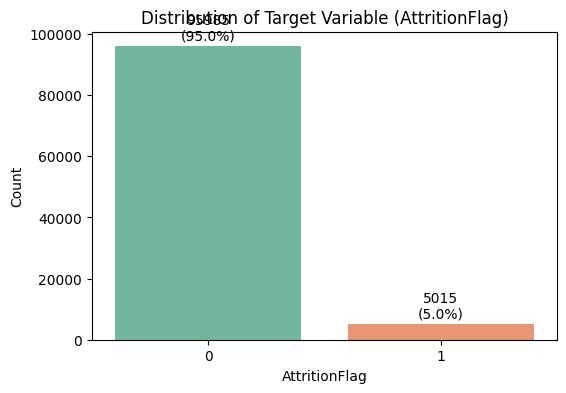

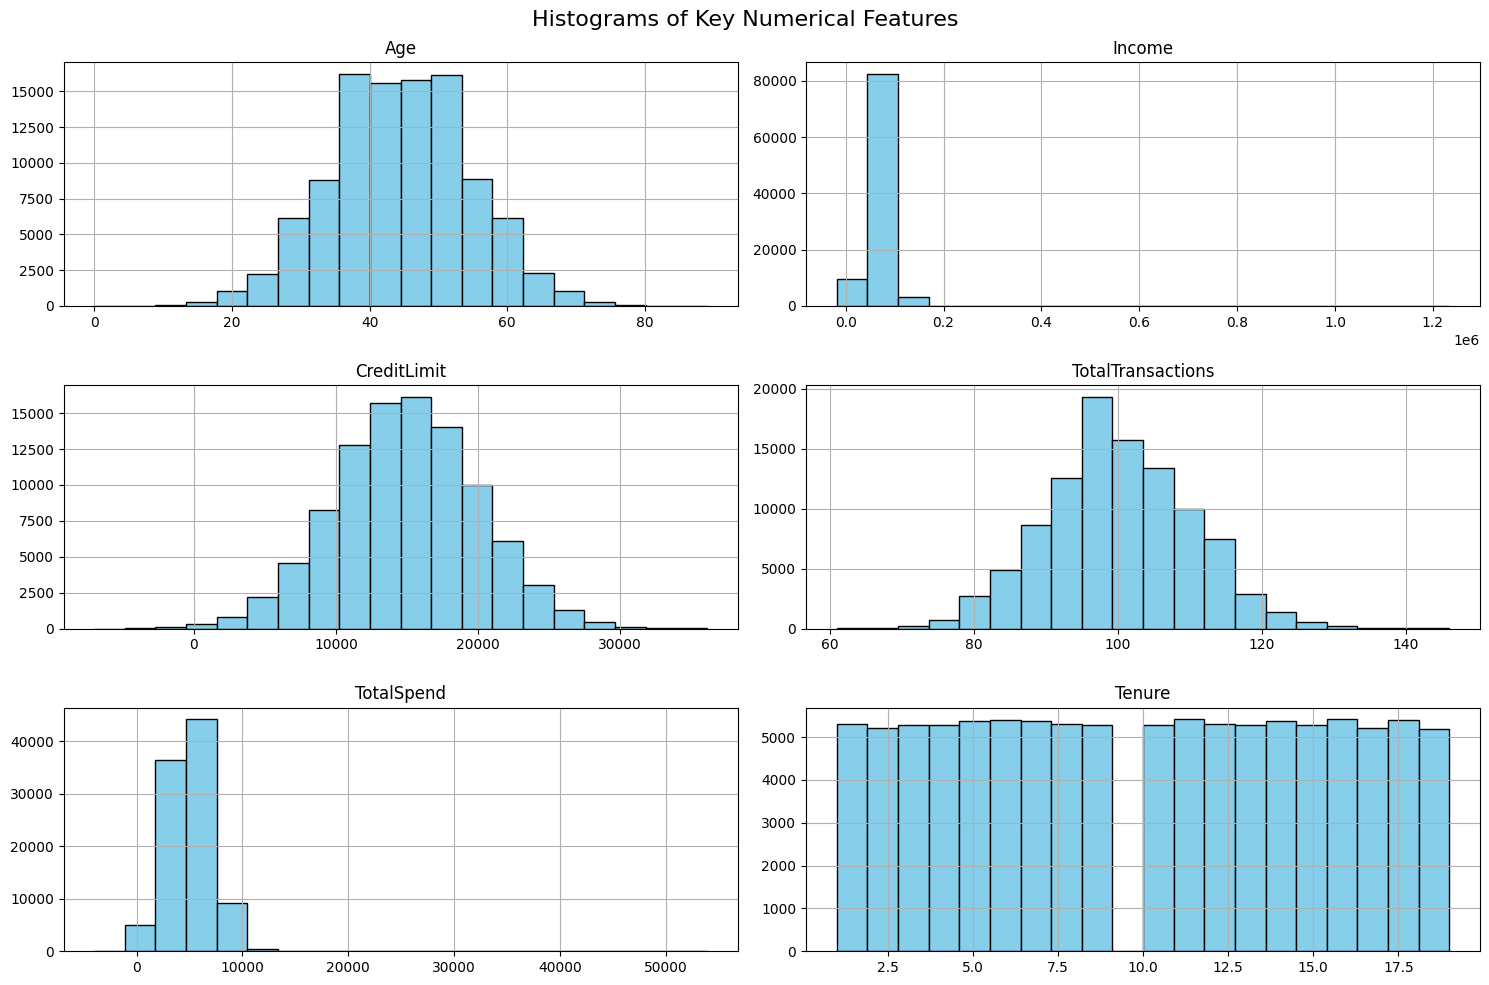

In [10]:
# @title

# Cell 1: Target Imbalance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='AttritionFlag', palette='Set2')
plt.title('Distribution of Target Variable (AttritionFlag)')
plt.ylabel('Count')

# Add count and percentage labels
total = len(df)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'

    # Format the label to show "Count (Percentage%)"
    label_text = f'{count}\n({percentage})'

    x = p.get_x() + p.get_width() / 2
    y = p.get_height()

    # Add a slight padding to the y-coordinate so it doesn't overlap the bar edge
    ax.annotate(label_text, (x, y + (total * 0.01)), ha='center', va='bottom')

plt.show()

# Cell 2: Numerical Feature Distributions
key_num_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend', 'Tenure']

df[key_num_cols].hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle('Histograms of Key Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
from scipy import stats
import pandas as pd
import numpy as np

FEATURES = ['Age', 'Income', 'TotalSpend', 'TotalTransactions', 'CreditLimit', 'Tenure']

def skew_label(skew):
    if   abs(skew) < 0.5:  return 'Symmetric'
    elif abs(skew) < 1.0:  return 'Moderate Skew'
    else:                  return 'High Skew'

def kurt_label(kurt):
    if   kurt > 1:   return 'Leptokurtic (heavy tails)'
    elif kurt < -1:  return 'Platykurtic (light tails)'
    else:            return 'Mesokurtic (normal-like)'

records = []
for col in FEATURES:
    data = df[col].dropna()
    skew = stats.skew(data)
    kurt = stats.kurtosis(data)  # excess kurtosis

    records.append({
        'Feature'       : col,
        'Mean'          : round(data.mean(), 2),
        'Median'        : round(data.median(), 2),
        'Std Dev'       : round(data.std(), 2),
        'Min'           : round(data.min(), 2),
        'Max'           : round(data.max(), 2),
        'Skewness'      : round(skew, 4),
        'Skew Type'     : skew_label(skew),
        'Kurtosis'      : round(kurt, 4),
        'Kurt Type'     : kurt_label(kurt),
    })

metrics_df = pd.DataFrame(records).set_index('Feature')

# Display each feature as its own block
for feature, row in metrics_df.iterrows():
    print(f"\n{'─'*40}")
    print(f"  {feature}")
    print(f"{'─'*40}")
    for metric, val in row.items():
        print(f"  {metric:<12} : {val}")

print(f"\n{'─'*40}")


────────────────────────────────────────
  Age
────────────────────────────────────────
  Mean         : 44.51
  Median       : 45.0
  Std Dev      : 10.01
  Min          : 0.0
  Max          : 89.0
  Skewness     : -0.003
  Skew Type    : Symmetric
  Kurtosis     : -0.0077
  Kurt Type    : Mesokurtic (normal-like)

────────────────────────────────────────
  Income
────────────────────────────────────────
  Mean         : 76254.9
  Median       : 70272.28
  Std Dev      : 68258.21
  Min          : -18277.72
  Max          : 1233743.99
  Skewness     : 9.7186
  Skew Type    : High Skew
  Kurtosis     : 107.8044
  Kurt Type    : Leptokurtic (heavy tails)

────────────────────────────────────────
  TotalSpend
────────────────────────────────────────
  Mean         : 5201.6
  Median       : 5029.49
  Std Dev      : 2976.32
  Min          : -4005.13
  Max          : 53896.73
  Skewness     : 4.959
  Skew Type    : High Skew
  Kurtosis     : 48.451
  Kurt Type    : Leptokurtic (heavy tails)

##### 1.1b Categorical Features

/tmp/ipykernel_200/1542930679.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
/tmp/ipykernel_200/1542930679.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
/tmp/ipykernel_200/1542930679.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
/tmp/ipykernel_200/1542930679.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

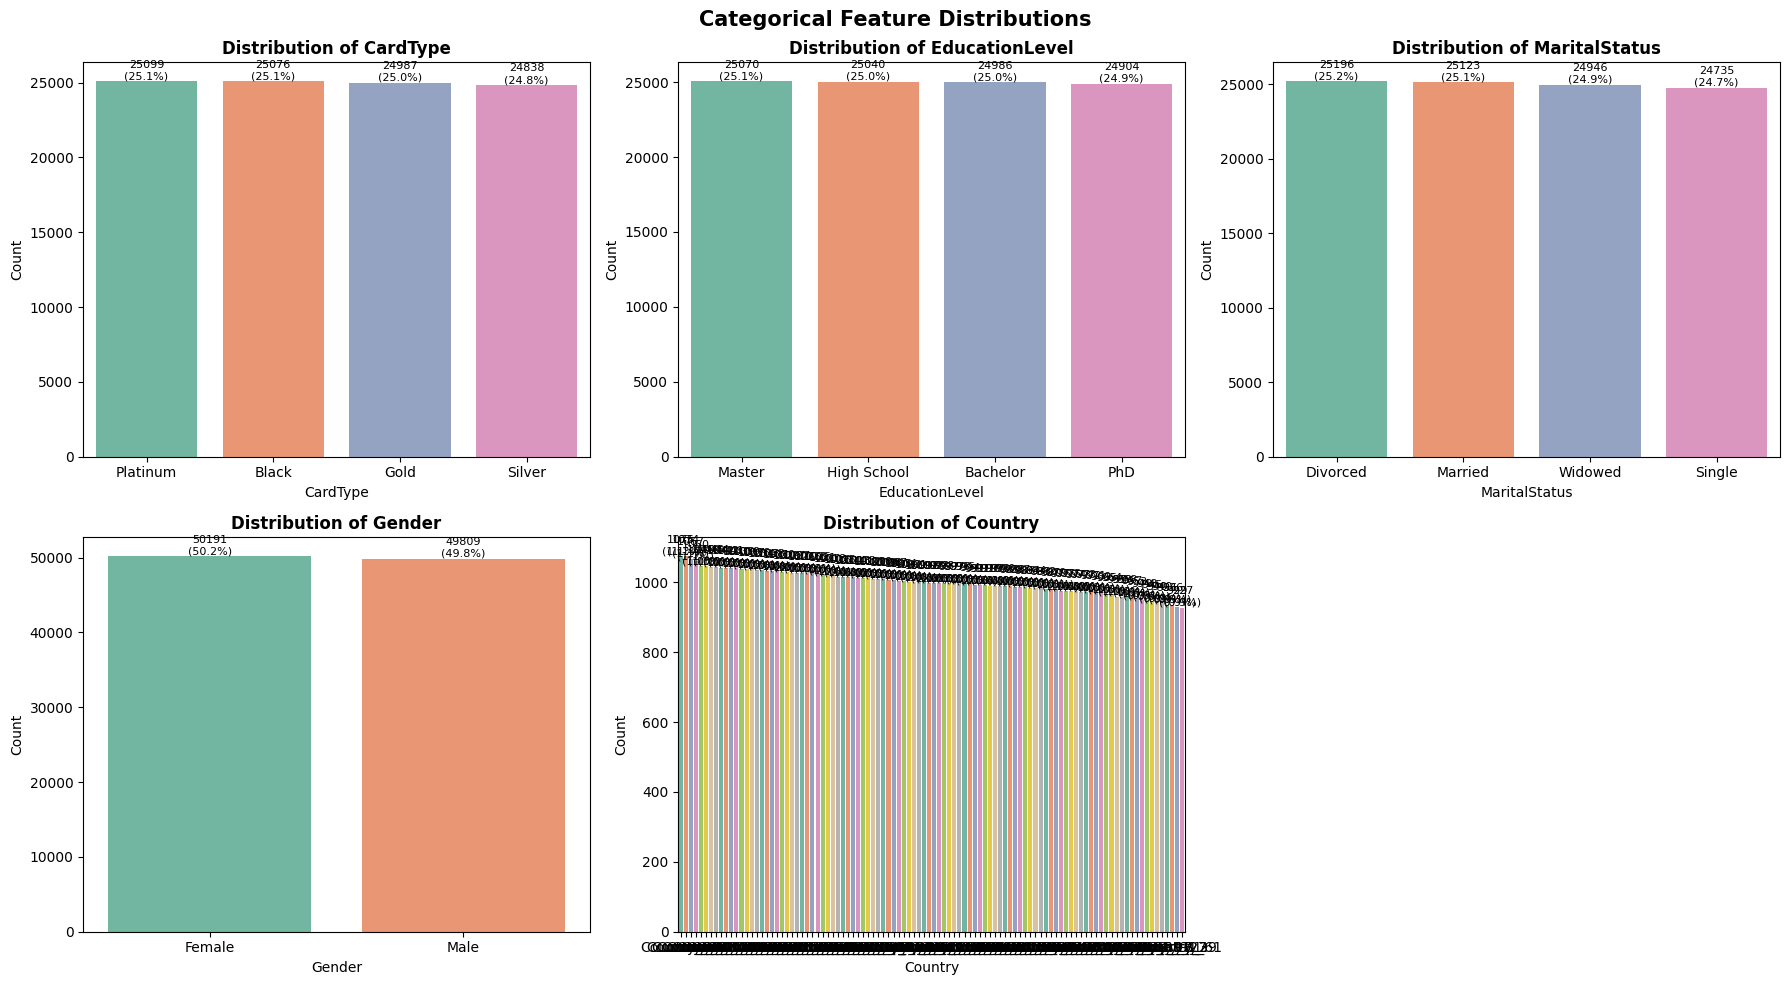


─────────────────────────────────────────────
  CardType
─────────────────────────────────────────────
Category  Count  % Share  Cumulative %
Platinum  25099    25.10         25.10
   Black  25076    25.08         50.18
    Gold  24987    24.99         75.17
  Silver  24838    24.84        100.01

  Dominant Category    : Platinum (25.1%)
  HHI (concentration)  : 0.2501  — Moderately spread
  Unique Categories    : 4

─────────────────────────────────────────────
  EducationLevel
─────────────────────────────────────────────
   Category  Count  % Share  Cumulative %
     Master  25070    25.07         25.07
High School  25040    25.04         50.11
   Bachelor  24986    24.99         75.10
        PhD  24904    24.90        100.00

  Dominant Category    : Master (25.07%)
  HHI (concentration)  : 0.25  — Moderately spread
  Unique Categories    : 4

─────────────────────────────────────────────
  MaritalStatus
─────────────────────────────────────────────
Category  Count  % Share  Cum

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cat_cols = ['CardType', 'EducationLevel', 'MaritalStatus', 'Gender', 'Country']

# -------------------------------------------------------------------
# PLOTS: Count plots per categorical feature
# -------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, palette='Set2', ax=ax)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

    total = len(df)
    for p in ax.patches:
        count = int(p.get_height())
        pct   = f'{100 * count / total:.1f}%'
        ax.annotate(f'{count}\n({pct})', (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Categorical Feature Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# QUANTIFIED METRICS
# -------------------------------------------------------------------
for col in cat_cols:
    print(f"\n{'─'*45}")
    print(f"  {col}")
    print(f"{'─'*45}")

    freq = df[col].value_counts().reset_index()
    freq.columns = ['Category', 'Count']
    freq['% Share']      = (freq['Count'] / len(df) * 100).round(2)
    freq['Cumulative %'] = freq['% Share'].cumsum().round(2)

    shares  = freq['% Share'] / 100
    hhi     = round((shares ** 2).sum(), 4)
    dominant = freq.iloc[0]['Category']
    dom_pct  = freq.iloc[0]['% Share']

    print(freq.to_string(index=False))
    print(f"\n  Dominant Category    : {dominant} ({dom_pct}%)")
    print(f"  HHI (concentration)  : {hhi}  {'— Highly concentrated' if hhi > 0.4 else '— Moderately spread'}")
    print(f"  Unique Categories    : {df[col].nunique()}")

### 1.2 Bivariate Analysis

=== 1. Core Averages Comparison ===


/tmp/ipykernel_200/3362642434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AttritionFlag', y=col, data=df, palette='Set2')
/tmp/ipykernel_200/3362642434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AttritionFlag', y=col, data=df, palette='Set2')
/tmp/ipykernel_200/3362642434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='AttritionFlag', y=col, data=df, palette='Set2')
/tmp/ipykernel_200/3362642434.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Ass

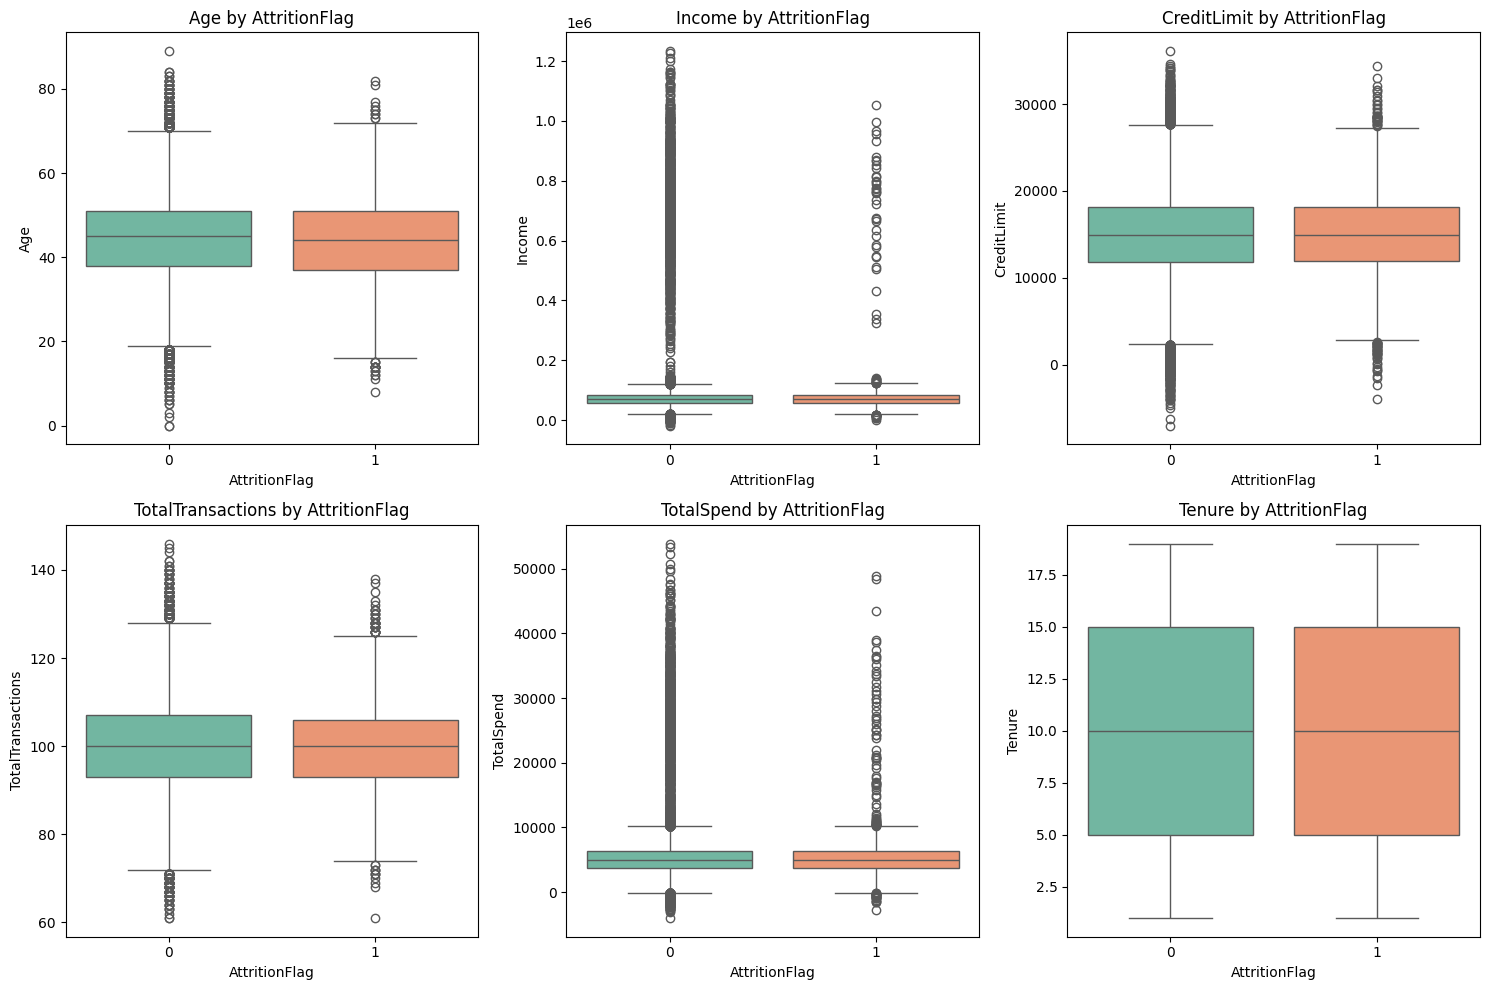

Median Values by Attrition Status:


AttritionFlag,0,1
Age,45.000000,44.000000
Income,70262.608211,70262.608211
CreditLimit,14963.638053,14963.638053
TotalTransactions,100.000000,100.000000
TotalSpend,5029.232703,5029.232703
Tenure,10.000000,10.000000



=== 2. Churn Rate for Negative Spenders ===


,Total Customers,Churn Rate
TotalSpend_is_negative,,
0,99422,4.96%
1,578,5.19%



=== 3. Churn Spikes by Tenure Year ===


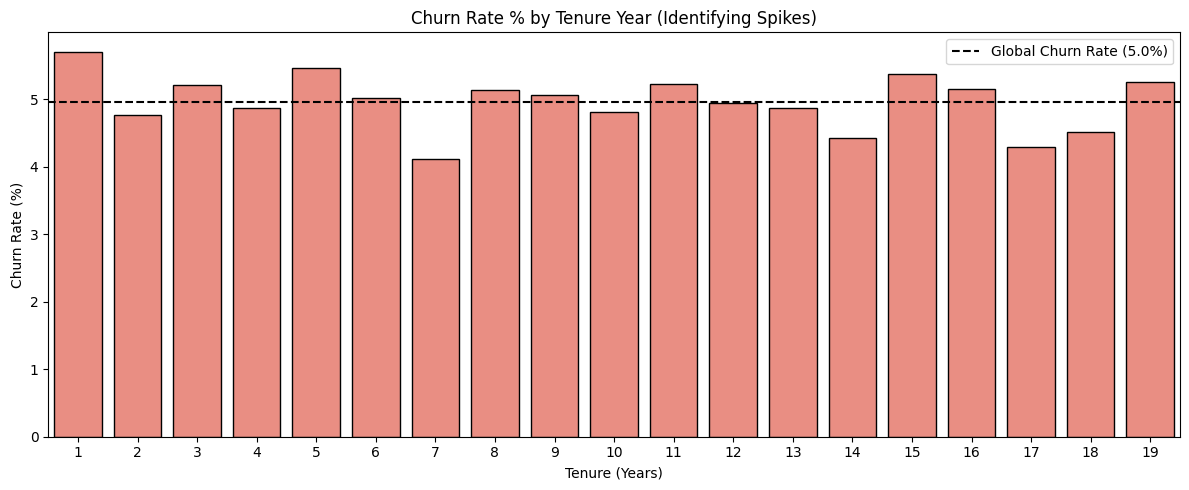

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# -------------------------------------------------------------------
# EDA ACTION 1: Deviations from Core Averages (Boxplots & Medians)
# -------------------------------------------------------------------
print("=== 1. Core Averages Comparison ===")
plt.figure(figsize=(15, 10))

for i, col in enumerate(key_num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='AttritionFlag', y=col, data=df, palette='Set2')
    plt.title(f'{col} by AttritionFlag')

plt.tight_layout()
plt.show()

# Print actual median values to quantify the visual differences
print("Median Values by Attrition Status:")
display(df.groupby('AttritionFlag')[key_num_cols].median().T)


# -------------------------------------------------------------------
# EDA ACTION 2: Check Negative Spenders
# -------------------------------------------------------------------
print("\n=== 2. Churn Rate for Negative Spenders ===")
# Ensure the feature exists (based on your earlier preprocessing)
if 'TotalSpend_is_negative' in df.columns:
    neg_spend_churn = df.groupby('TotalSpend_is_negative')['AttritionFlag'].agg(['count', 'mean'])
    neg_spend_churn.columns = ['Total Customers', 'Churn Rate']
    neg_spend_churn['Churn Rate'] = (neg_spend_churn['Churn Rate'] * 100).round(2).astype(str) + '%'
    display(neg_spend_churn)
else:
    print("Column 'TotalSpend_is_negative' not found in DataFrame.")


# -------------------------------------------------------------------
# EDA ACTION 3: Tenure Danger Zones (Uniform Distribution Check)
# -------------------------------------------------------------------
print("\n=== 3. Churn Spikes by Tenure Year ===")
plt.figure(figsize=(12, 5))

# Calculate churn rate percentage per tenure year
tenure_churn = df.groupby('Tenure')['AttritionFlag'].mean() * 100

# Plotting the churn rate per year
sns.barplot(x=tenure_churn.index, y=tenure_churn.values, color='salmon', edgecolor='black')

# Add a reference line for the Global (Average) Churn Rate
global_churn = df['AttritionFlag'].mean() * 100
plt.axhline(global_churn, color='black', linestyle='--', label=f'Global Churn Rate ({global_churn:.1f}%)')

plt.title('Churn Rate % by Tenure Year (Identifying Spikes)')
plt.xlabel('Tenure (Years)')
plt.ylabel('Churn Rate (%)')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# -------------------------------------------------------------------
# QUANTIFY 1: Core Averages Comparison (Boxplots)
# -------------------------------------------------------------------
print("=== 1. Core Averages Comparison ===")

box_stats = df.groupby('AttritionFlag')[key_num_cols].agg([
    'median', 'mean', 'std',
    lambda x: x.quantile(0.25),
    lambda x: x.quantile(0.75)
])
box_stats.columns = ['_'.join(col).replace('<lambda_0>', 'Q1').replace('<lambda_1>', 'Q3')
                     for col in box_stats.columns]

# Median difference between attrited vs stayed
median_pivot = df.groupby('AttritionFlag')[key_num_cols].median().T
median_pivot.columns = ['Stayed', 'Attrited']
median_pivot['Abs Diff']  = (median_pivot['Attrited'] - median_pivot['Stayed']).abs()
median_pivot['% Diff']    = ((median_pivot['Attrited'] - median_pivot['Stayed']) / median_pivot['Stayed'] * 100).round(2)

print("\nMedian Comparison (Stayed vs Attrited):")
display(median_pivot)

# IQR per group
print("\nIQR by Attrition Status:")
iqr_df = df.groupby('AttritionFlag')[key_num_cols].agg(
    lambda x: round(x.quantile(0.75) - x.quantile(0.25), 2)
).T
iqr_df.columns = ['Stayed_IQR', 'Attrited_IQR']
display(iqr_df)


# -------------------------------------------------------------------
# QUANTIFY 2: Negative Spenders
# -------------------------------------------------------------------
print("\n=== 2. Negative Spenders Breakdown ===")

if 'TotalSpend_is_negative' in df.columns:
    neg_detail = df.groupby('TotalSpend_is_negative').agg(
        Total_Customers  = ('AttritionFlag', 'count'),
        Attrited         = ('AttritionFlag', 'sum'),
        Churn_Rate_Pct   = ('AttritionFlag', lambda x: round(x.mean() * 100, 2)),
        Median_Spend     = ('TotalSpend', 'median'),
        Mean_Spend       = ('TotalSpend', 'mean'),
    )
    neg_detail.index = ['Non-Negative', 'Negative']
    display(neg_detail)

    # Lift over baseline
    baseline = df['AttritionFlag'].mean() * 100
    for segment in neg_detail.index:
        lift = neg_detail.loc[segment, 'Churn_Rate_Pct'] - baseline
        print(f"  {segment} — Churn lift vs global baseline: {lift:+.2f}pp")
else:
    print("Column 'TotalSpend_is_negative' not found.")


# -------------------------------------------------------------------
# QUANTIFY 3: Tenure Danger Zones
# -------------------------------------------------------------------
print("\n=== 3. Tenure Churn Spikes ===")

tenure_stats = df.groupby('Tenure').agg(
    Total_Customers = ('AttritionFlag', 'count'),
    Attrited        = ('AttritionFlag', 'sum'),
    Churn_Rate_Pct  = ('AttritionFlag', lambda x: round(x.mean() * 100, 2))
).reset_index()

global_churn = df['AttritionFlag'].mean() * 100
tenure_stats['Vs_Global_pp']  = (tenure_stats['Churn_Rate_Pct'] - global_churn).round(2)
tenure_stats['Danger_Zone']   = tenure_stats['Churn_Rate_Pct'] > global_churn

print(f"\nGlobal Churn Rate: {global_churn:.2f}%")
print("\nChurn Rate by Tenure Year:")
display(tenure_stats.sort_values('Churn_Rate_Pct', ascending=False))

print("\nDanger Zones (Above Global Churn Rate):")
display(tenure_stats[tenure_stats['Danger_Zone']].sort_values('Churn_Rate_Pct', ascending=False))

=== 1. Core Averages Comparison ===

Median Comparison (Stayed vs Attrited):


,Stayed,Attrited,Abs Diff,% Diff
Age,45.000000,44.000000,1.0,-2.22
Income,70262.608211,70262.608211,0.0,0.00
CreditLimit,14963.638053,14963.638053,0.0,0.00
TotalTransactions,100.000000,100.000000,0.0,0.00
TotalSpend,5029.232703,5029.232703,0.0,0.00
Tenure,10.000000,10.000000,0.0,0.00



IQR by Attrition Status:


,Stayed_IQR,Attrited_IQR
Age,13.00,14.00
Income,25649.94,25985.30
CreditLimit,6330.76,6194.64
TotalTransactions,14.00,13.00
TotalSpend,2569.46,2587.79
Tenure,10.00,10.00



=== 2. Negative Spenders Breakdown ===


,Total_Customers,Attrited,Churn_Rate_Pct,Median_Spend,Mean_Spend
Non-Negative,99422,4930,4.96,5029.232703,5225.060169
Negative,578,30,5.19,-455.421015,-625.150023


  Non-Negative — Churn lift vs global baseline: +0.00pp
  Negative — Churn lift vs global baseline: +0.23pp

=== 3. Tenure Churn Spikes ===

Global Churn Rate: 4.96%

Churn Rate by Tenure Year:


,Tenure,Total_Customers,Attrited,Churn_Rate_Pct,Vs_Global_pp,Danger_Zone
0,1,5238,299,5.71,0.75,True
4,5,5340,292,5.47,0.51,True
14,15,5229,281,5.37,0.41,True
18,19,5133,270,5.26,0.30,True
10,11,5359,280,5.22,0.26,True
2,3,5220,272,5.21,0.25,True
7,8,5266,271,5.15,0.19,True
15,16,5355,276,5.15,0.19,True
8,9,5217,264,5.06,0.10,True
5,6,5337,268,5.02,0.06,True



Danger Zones (Above Global Churn Rate):


,Tenure,Total_Customers,Attrited,Churn_Rate_Pct,Vs_Global_pp,Danger_Zone
0,1,5238,299,5.71,0.75,True
4,5,5340,292,5.47,0.51,True
14,15,5229,281,5.37,0.41,True
18,19,5133,270,5.26,0.30,True
10,11,5359,280,5.22,0.26,True
2,3,5220,272,5.21,0.25,True
7,8,5266,271,5.15,0.19,True
15,16,5355,276,5.15,0.19,True
8,9,5217,264,5.06,0.10,True
5,6,5337,268,5.02,0.06,True


### 1.3 Multivariate Analysis

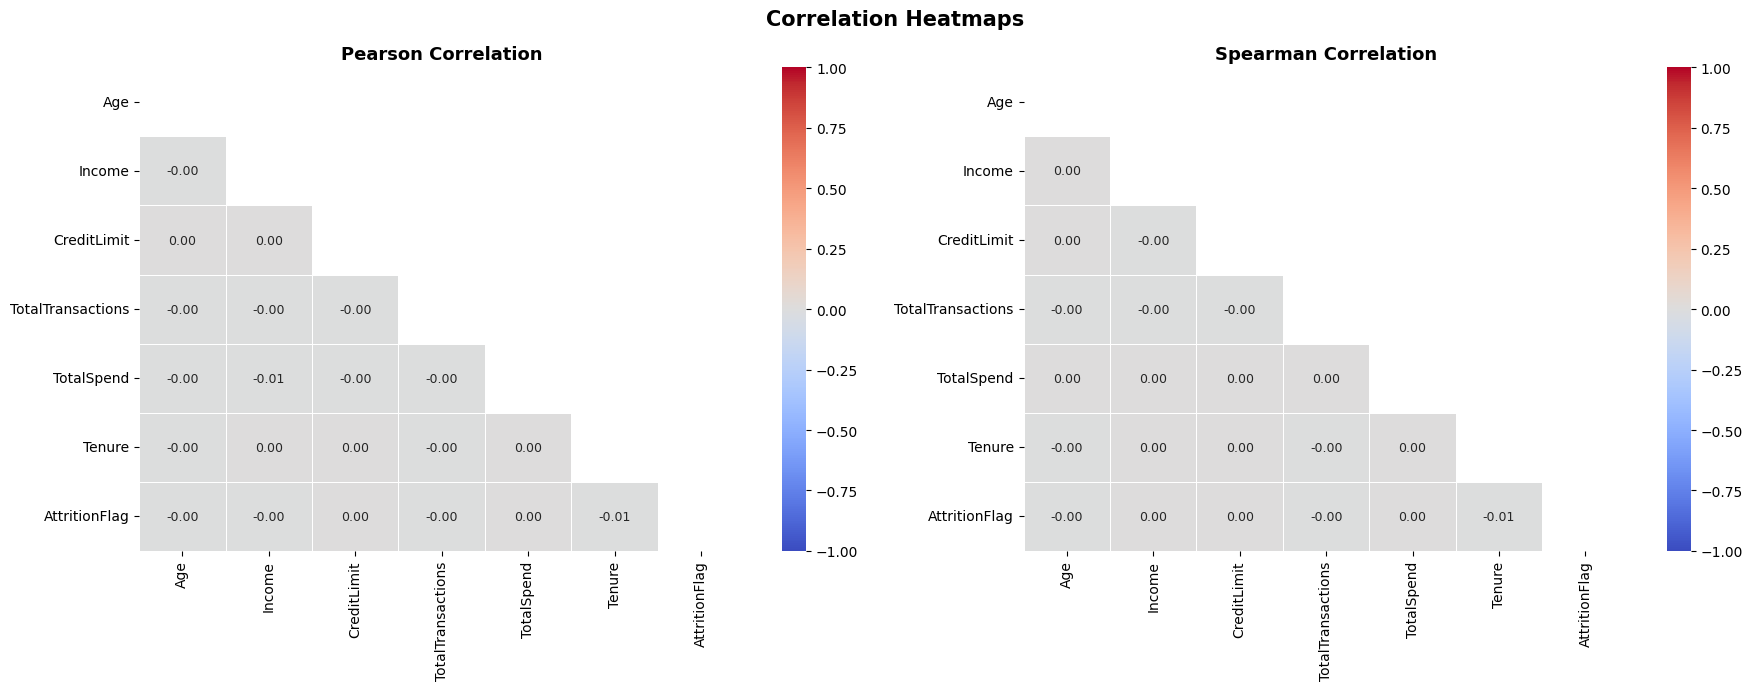

=== Feature-Target Correlation (AttritionFlag) ===



,Pearson_r,Spearman_r,Signal
Tenure,-0.0052,-0.0052,Weak
Age,-0.0049,-0.0040,Weak
TotalSpend,0.0044,0.0021,Weak
Income,-0.0031,0.0009,Weak
TotalTransactions,-0.0021,-0.0020,Weak
CreditLimit,0.0004,0.0003,Weak



=== Pairwise Correlation Among Features ===



,Feature A,Feature B,Pearson_r,Flag
7,Income,TotalSpend,-0.0061,Low
9,CreditLimit,TotalTransactions,-0.0047,Low
4,Age,Tenure,-0.0042,Low
13,TotalTransactions,Tenure,-0.0039,Low
1,Age,CreditLimit,0.0036,Low
6,Income,TotalTransactions,-0.0032,Low
5,Income,CreditLimit,0.0031,Low
11,CreditLimit,Tenure,0.0029,Low
8,Income,Tenure,0.0025,Low
14,TotalSpend,Tenure,0.0023,Low



=== Variance Inflation Factor (VIF) ===



'          Feature  VIF   Assessment\n           Income  1.0 ✅ Acceptable\n      CreditLimit  1.0 ✅ Acceptable\n           Tenure  1.0 ✅ Acceptable\nTotalTransactions  1.0 ✅ Acceptable\n       TotalSpend  1.0 ✅ Acceptable\n              Age  1.0 ✅ Acceptable'

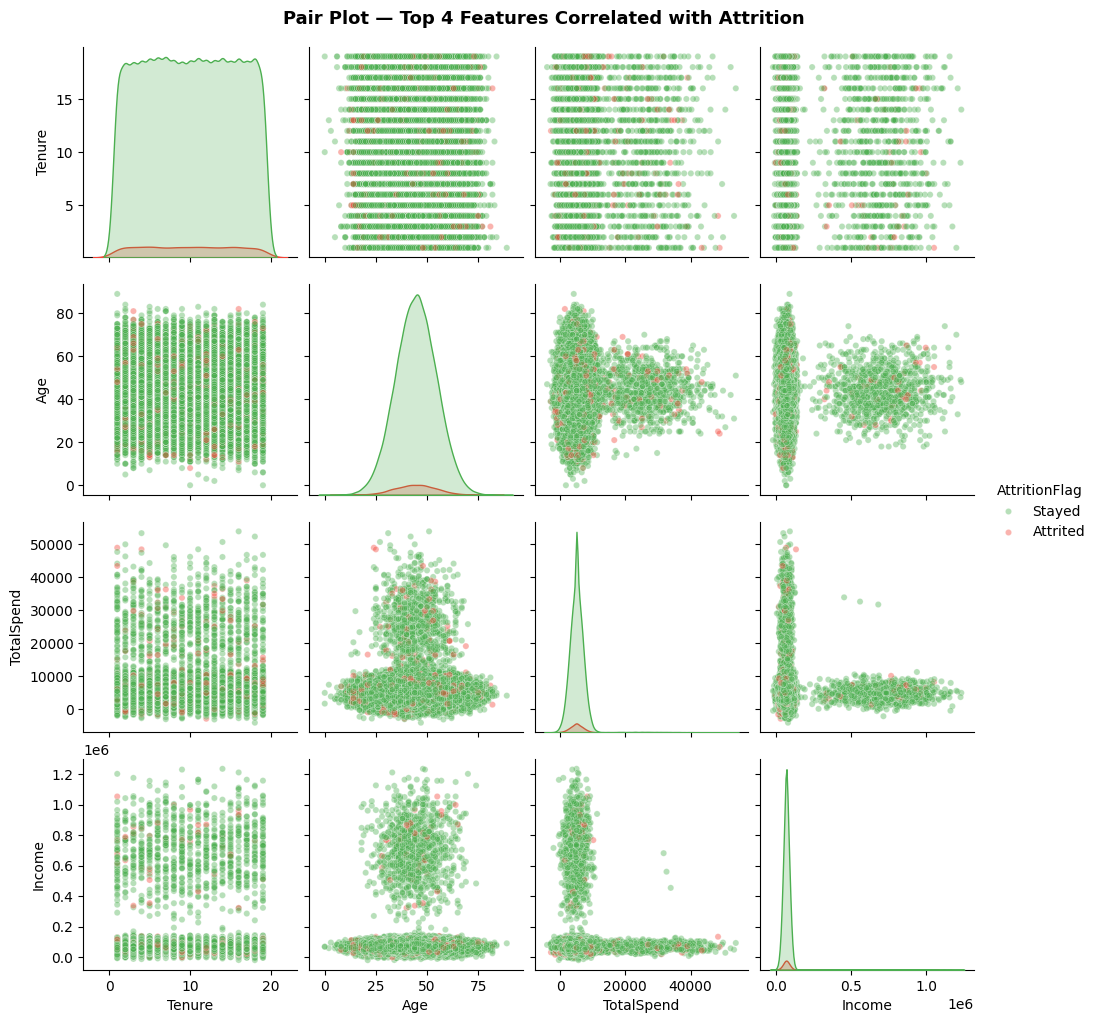

In [ ]:
# @title

num_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend', 'Tenure']

# -------------------------------------------------------------------
# 1. CORRELATION MATRIX (Pearson + Spearman)
# -------------------------------------------------------------------
pearson_corr  = df[num_cols + ['AttritionFlag']].corr(method='pearson')
spearman_corr = df[num_cols + ['AttritionFlag']].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr, title in zip(axes,
                            [pearson_corr, spearman_corr],
                            ['Pearson Correlation', 'Spearman Correlation']):
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax,
                linewidths=0.5, annot_kws={'size': 9})
    ax.set_title(title, fontsize=13, fontweight='bold')

plt.suptitle('Correlation Heatmaps', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 2. QUANTIFIED: Feature-Target Correlation
# -------------------------------------------------------------------
print("=== Feature-Target Correlation (AttritionFlag) ===\n")

target_corr = pd.DataFrame({
    'Pearson_r' : pearson_corr['AttritionFlag'].drop('AttritionFlag'),
    'Spearman_r': spearman_corr['AttritionFlag'].drop('AttritionFlag')
}).sort_values('Pearson_r', key=abs, ascending=False)

target_corr['Pearson_r']     = target_corr['Pearson_r'].round(4)
target_corr['Spearman_r']    = target_corr['Spearman_r'].round(4)
target_corr['Abs_Pearson']   = target_corr['Pearson_r'].abs()
target_corr['Signal']        = target_corr['Abs_Pearson'].apply(
    lambda x: 'Strong' if x >= 0.3 else ('Moderate' if x >= 0.1 else 'Weak')
)

display(target_corr.drop(columns='Abs_Pearson'))

# -------------------------------------------------------------------
# 3. QUANTIFIED: Multicollinearity — Pairwise + VIF
# -------------------------------------------------------------------
print("\n=== Pairwise Correlation Among Features ===\n")

pair_corr = df[num_cols].corr(method='pearson').round(4)
# Extract upper triangle pairs only
pairs = []
for i in range(len(num_cols)):
    for j in range(i+1, len(num_cols)):
        r = pair_corr.iloc[i, j]
        pairs.append({
            'Feature A'  : num_cols[i],
            'Feature B'  : num_cols[j],
            'Pearson_r'  : round(r, 4),
            'Abs_r'      : round(abs(r), 4),
            'Flag'       : '⚠️  HIGH' if abs(r) >= 0.8 else ('Moderate' if abs(r) >= 0.5 else 'Low')
        })

pair_df = pd.DataFrame(pairs).sort_values('Abs_r', ascending=False).drop(columns='Abs_r')
display(pair_df)

# VIF
print("\n=== Variance Inflation Factor (VIF) ===\n")
X_vif = add_constant(df[num_cols].dropna())
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

vif_df['VIF']        = vif_df['VIF'].round(2)
vif_df['Assessment'] = vif_df['VIF'].apply(
    lambda x: '🚨 Severe multicollinearity' if x >= 10
         else ('⚠️  Moderate'               if x >= 5
         else  '✅ Acceptable')
)
display(vif_df.to_string(index=False))

# -------------------------------------------------------------------
# 4. PAIR PLOT — Top correlated features with AttritionFlag
# -------------------------------------------------------------------
top_features = (target_corr['Abs_Pearson']
                .nlargest(4).index.tolist()
                if 'Abs_Pearson' in target_corr.columns
                else target_corr['Pearson_r'].abs().nlargest(4).index.tolist())

# Recompute since we dropped Abs_Pearson from display
top_features = target_corr.assign(Abs=target_corr['Pearson_r'].abs()) \
                           .nlargest(4, 'Abs').index.tolist()

pair_plot_df = df[top_features + ['AttritionFlag']].copy()
pair_plot_df['AttritionFlag'] = pair_plot_df['AttritionFlag'].map({0: 'Stayed', 1: 'Attrited'})

g = sns.pairplot(pair_plot_df, hue='AttritionFlag', palette={'Stayed': '#4CAF50', 'Attrited': '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
g.fig.suptitle('Pair Plot — Top 4 Features Correlated with Attrition', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### 1.4 Statistical Significance Tests
- Since numeric features are insignificant, maybe additional engineered features can help.

##### 1.4a Before Feature Engineering

In [ ]:
# @title
from scipy import stats
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend', 'Tenure']
cat_cols = ['CardType', 'EducationLevel', 'MaritalStatus', 'Gender']

# Note: Ensure 'df' contains your raw, un-encoded categorical columns for the Chi-Square test
stayed   = df[df['AttritionFlag'] == 0]
attrited = df[df['AttritionFlag'] == 1]

# -------------------------------------------------------------------
# 1. TWO-SAMPLE T-TEST — Numerical Features
# -------------------------------------------------------------------
print("=" * 60)
print("  TWO-SAMPLE T-TEST — Numerical Features vs AttritionFlag")
print("=" * 60)

ttest_records = []

for col in num_cols:
    g0 = stayed[col].dropna()
    g1 = attrited[col].dropna()

    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)  # Welch's T-test

    mean_stayed   = g0.mean()
    mean_attrited = g1.mean()
    pct_diff      = ((mean_attrited - mean_stayed) / mean_stayed) * 100

    # Cohen's d — effect size
    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (mean_attrited - mean_stayed) / pooled_std

    sig = '✅ Significant' if p_val < 0.05 else '❌ Not Significant'
    effect = (
        'Negligible' if abs(cohens_d) < 0.2 else
        'Small'      if abs(cohens_d) < 0.5 else
        'Medium'     if abs(cohens_d) < 0.8 else
        'Large'
    )

    ttest_records.append({
        'Feature'       : col,
        'Mean_Stayed'   : round(mean_stayed,   4),
        'Mean_Attrited' : round(mean_attrited, 4),
        '% Diff'        : round(pct_diff,      2),
        'T-Statistic'   : round(t_stat,        4),
        'P-Value'       : round(p_val,         6),
        "Cohen's d"     : round(cohens_d,      4),
        'Effect Size'   : effect,
        'Result'        : sig
    })

ttest_df = pd.DataFrame(ttest_records).set_index('Feature')
display(ttest_df)

print("\n  Interpretation Guide:")
print("  p < 0.05           → Reject H0 (difference is statistically significant)")
print("  % Diff < 5%        → Practically small despite significance (large n effect)")
print("  Cohen's d < 0.2    → Negligible real-world effect")

# -------------------------------------------------------------------
# 2. CHI-SQUARE TEST — Categorical Features
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  CHI-SQUARE TEST — Categorical Features vs AttritionFlag")
print("=" * 60)

chi2_records = []

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['AttritionFlag'])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)

    # Cramér's V — effect size for chi-square
    n       = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))

    sig = '✅ Significant' if p_val < 0.05 else '❌ Not Significant'
    effect = (
        'Negligible' if cramers_v < 0.1 else
        'Small'      if cramers_v < 0.3 else
        'Medium'     if cramers_v < 0.5 else
        'Large'
    )

    chi2_records.append({
        'Feature'   : col,
        'Chi2 Stat' : round(chi2,      4),
        'P-Value'   : round(p_val,     6),
        'DOF'       : dof,
        "Cramér's V": round(cramers_v, 4),
        'Effect Size': effect,
        'Result'    : sig
    })

chi2_df = pd.DataFrame(chi2_records).set_index('Feature')
display(chi2_df)

print("\n  Interpretation Guide:")
print("  p < 0.05           → Reject H0 (attrition rates differ across categories)")
print("  Cramér's V < 0.1   → Negligible association despite significance")
print("  Cramér's V > 0.3   → Meaningful categorical signal worth keeping")

# -------------------------------------------------------------------
# 3. VARIANCE INFLATION FACTOR (VIF) CHECK
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  VARIANCE INFLATION FACTOR (VIF) — Checking Multicollinearity")
print("=" * 60)

# Create a subset of just the numerical features, dropping any NaNs to prevent VIF errors
vif_data = df[num_cols].dropna()

# Calculate VIF for each feature
vif_records = []
for i in range(vif_data.shape[1]):
    vif_val = variance_inflation_factor(vif_data.values, i)

    # Assign a flag based on standard thresholds
    flag = 'High/Severe' if vif_val > 10 else ('Moderate' if vif_val > 5 else 'Acceptable')

    vif_records.append({
        'Feature': vif_data.columns[i],
        'VIF Score': round(vif_val, 2),
        'Assessment': flag
    })

vif_df = pd.DataFrame(vif_records).sort_values(by='VIF Score', ascending=False)
display(vif_df)

print("\n  Interpretation Guide:")
print("  VIF < 5            → Acceptable (Little to no multicollinearity)")
print("  5 < VIF < 10       → Moderate (Caution for linear models like Logistic Regression)")
print("  VIF > 10           → High/Severe (Must drop for linear models to ensure stability)")

# -------------------------------------------------------------------
# 3. SUMMARY — Features worth keeping for modeling
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  FEATURE SIGNAL SUMMARY")
print("=" * 60)

print("\n  Numerical — Flag for modeling (Significant + Effect > Negligible):")
worthy_num = ttest_df[
    (ttest_df['Result'] == '✅ Significant') &
    (~ttest_df['Effect Size'].isin(['Negligible']))
].index.tolist()
print(f"  {worthy_num if worthy_num else 'None — rely on model feature importance'}")

print("\n  Categorical — Flag for modeling (Significant + Cramér's V > 0.1):")
worthy_cat = chi2_df[
    (chi2_df['Result'] == '✅ Significant') &
    (~chi2_df['Effect Size'].isin(['Negligible']))
].index.tolist()
print(f"  {worthy_cat if worthy_cat else 'None — rely on model feature importance'}")

# ── VIF Reference (reprinted for convenience) ──
print("\n── VIF Summary (Numerical Features) ───────────────────────")
print(vif_df.to_string(index=False)) # <--- This prints the full list of every feature and its VIF score!

  TWO-SAMPLE T-TEST — Numerical Features vs AttritionFlag


,Mean_Stayed,Mean_Attrited,% Diff,T-Statistic,P-Value,Cohen's d,Effect Size,Result
Feature,,,,,,,,
Age,44.5199,44.2944,-0.51,1.5215,0.128190,-0.0223,Negligible,❌ Not Significant
Income,75953.7272,75014.0909,-1.24,1.0529,0.292439,-0.0147,Negligible,❌ Not Significant
CreditLimit,14980.4930,14989.6797,0.06,-0.1285,0.897745,0.0019,Negligible,❌ Not Significant
TotalTransactions,99.9970,99.8996,-0.10,0.6762,0.498947,-0.0098,Negligible,❌ Not Significant
TotalSpend,5188.3140,5247.4252,1.14,-1.3229,0.185915,0.0198,Negligible,❌ Not Significant
Tenure,10.0064,9.8762,-1.30,1.6269,0.103823,-0.0238,Negligible,❌ Not Significant



  Interpretation Guide:
  p < 0.05           → Reject H0 (difference is statistically significant)
  % Diff < 5%        → Practically small despite significance (large n effect)
  Cohen's d < 0.2    → Negligible real-world effect

  CHI-SQUARE TEST — Categorical Features vs AttritionFlag


,Chi2 Stat,P-Value,DOF,Cramér's V,Effect Size,Result
Feature,,,,,,
CardType,5.8876,0.117211,3,0.0077,Negligible,❌ Not Significant
EducationLevel,3.3937,0.334806,3,0.0058,Negligible,❌ Not Significant
MaritalStatus,2.5431,0.467560,3,0.0050,Negligible,❌ Not Significant
Gender,0.6174,0.432021,1,0.0025,Negligible,❌ Not Significant



  Interpretation Guide:
  p < 0.05           → Reject H0 (attrition rates differ across categories)
  Cramér's V < 0.1   → Negligible association despite significance
  Cramér's V > 0.3   → Meaningful categorical signal worth keeping

  VARIANCE INFLATION FACTOR (VIF) — Checking Multicollinearity


,Feature,VIF Score,Assessment
3,TotalTransactions,27.70,High/Severe
0,Age,17.79,High/Severe
2,CreditLimit,9.71,Moderate
5,Tenure,4.24,Acceptable
4,TotalSpend,4.11,Acceptable
1,Income,2.29,Acceptable



  Interpretation Guide:
  VIF < 5            → Acceptable (Little to no multicollinearity)
  5 < VIF < 10       → Moderate (Caution for linear models like Logistic Regression)
  VIF > 10           → High/Severe (Must drop for linear models to ensure stability)

  FEATURE SIGNAL SUMMARY

  Numerical — Flag for modeling (Significant + Effect > Negligible):
  None — rely on model feature importance

  Categorical — Flag for modeling (Significant + Cramér's V > 0.1):
  None — rely on model feature importance

── VIF Summary (Numerical Features) ───────────────────────
          Feature  VIF Score  Assessment
TotalTransactions      27.70 High/Severe
              Age      17.79 High/Severe
      CreditLimit       9.71    Moderate
           Tenure       4.24  Acceptable
       TotalSpend       4.11  Acceptable
           Income       2.29  Acceptable


##### 1.4b After Feature Engineering

**Note:** This cell requires `df_tree` from Section 4.6 (Feature Engineering). Run that section first, then return here.

In [20]:
df_fe = df_tree.copy()

  FEATURE-TARGET CORRELATION — Engineered vs AttritionFlag


,Pearson_r,Spearman_r,Signal
Avg_Txn_per_Tenure_Year,0.0074,0.0048,Weak
Avg_Spend_per_Tenure_Year,0.0072,0.0060,Weak
Tenure,-0.0052,-0.0052,Weak
Age,-0.0049,-0.0040,Weak
Avg_Transaction_Value,0.0046,0.0027,Weak
TotalSpend,0.0044,0.0021,Weak
Credit_Utilization,0.0033,0.0010,Weak
Income,-0.0031,0.0009,Weak
TotalTransactions,-0.0021,-0.0020,Weak
Spend_to_Income,-0.0013,0.0010,Weak


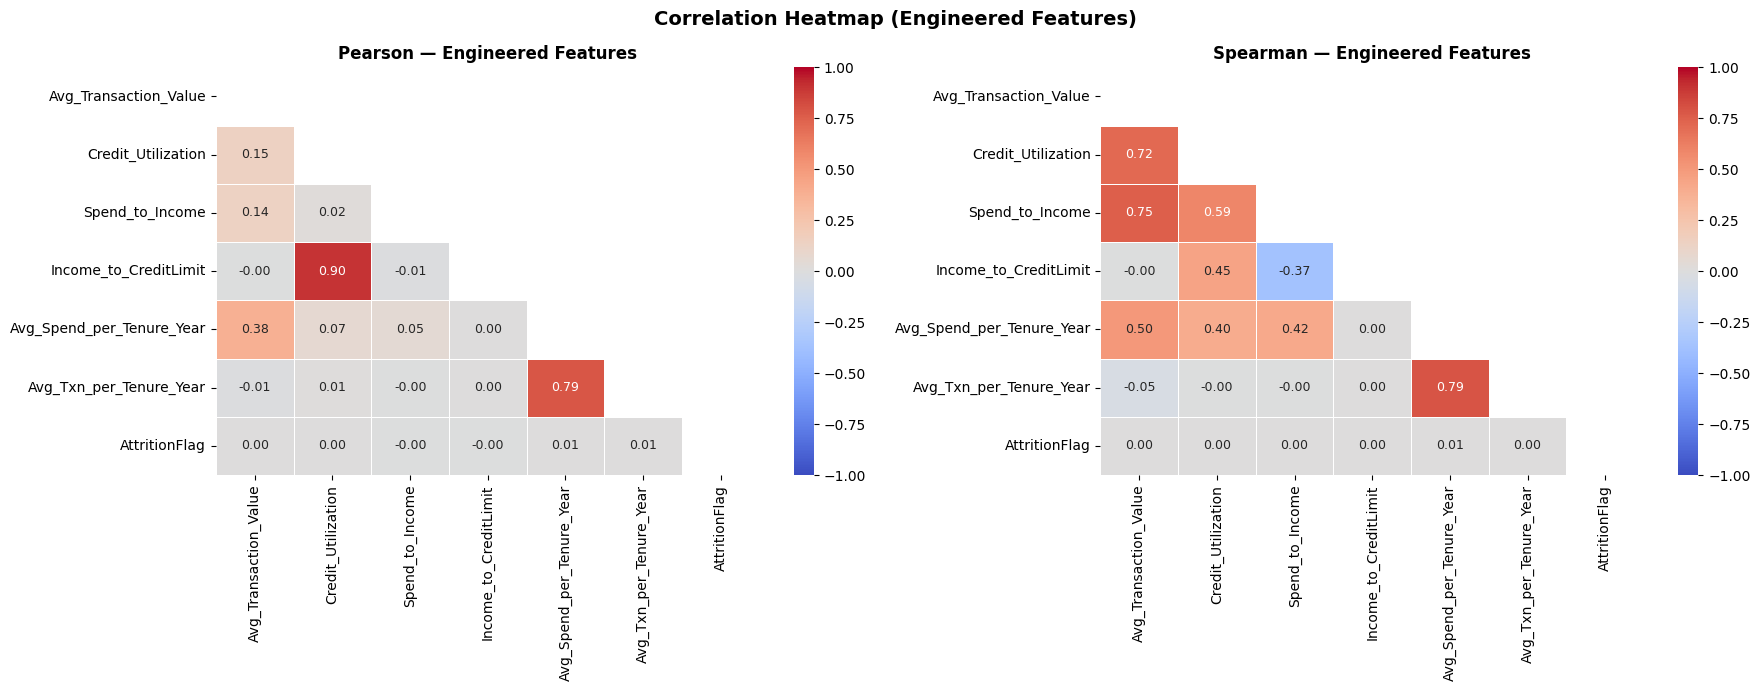


  PAIRWISE CORRELATION — All Numerical Features


,Feature A,Feature B,Pearson_r,Flag
39,TotalSpend,Avg_Transaction_Value,0.9789,⚠️ HIGH
57,Credit_Utilization,Income_to_CreditLimit,0.8991,⚠️ HIGH
65,Avg_Spend_per_Tenure_Year,Avg_Txn_per_Tenure_Year,0.7863,Moderate
50,Tenure,Avg_Txn_per_Tenure_Year,-0.7086,Moderate
49,Tenure,Avg_Spend_per_Tenure_Year,-0.5631,Moderate
...,...,...,...,...
33,TotalTransactions,Credit_Utilization,0.0007,Low
30,TotalTransactions,TotalSpend,-0.0004,Low
36,TotalTransactions,Avg_Spend_per_Tenure_Year,-0.0002,Low
24,CreditLimit,Avg_Transaction_Value,0.0000,Low



  VIF — All Numerical Features (incl. Engineered)
                  Feature   VIF   Assessment
    Avg_Transaction_Value 96.21     🚨 Severe
               TotalSpend 93.94     🚨 Severe
       Credit_Utilization  6.85 ⚠️  Moderate
    Income_to_CreditLimit  6.76 ⚠️  Moderate
  Avg_Txn_per_Tenure_Year  4.76 ✅ Acceptable
Avg_Spend_per_Tenure_Year  4.40 ✅ Acceptable
        TotalTransactions  4.05 ✅ Acceptable
                   Tenure  2.02 ✅ Acceptable
                   Income  1.16 ✅ Acceptable
              CreditLimit  1.04 ✅ Acceptable
          Spend_to_Income  1.02 ✅ Acceptable
                      Age  1.00 ✅ Acceptable


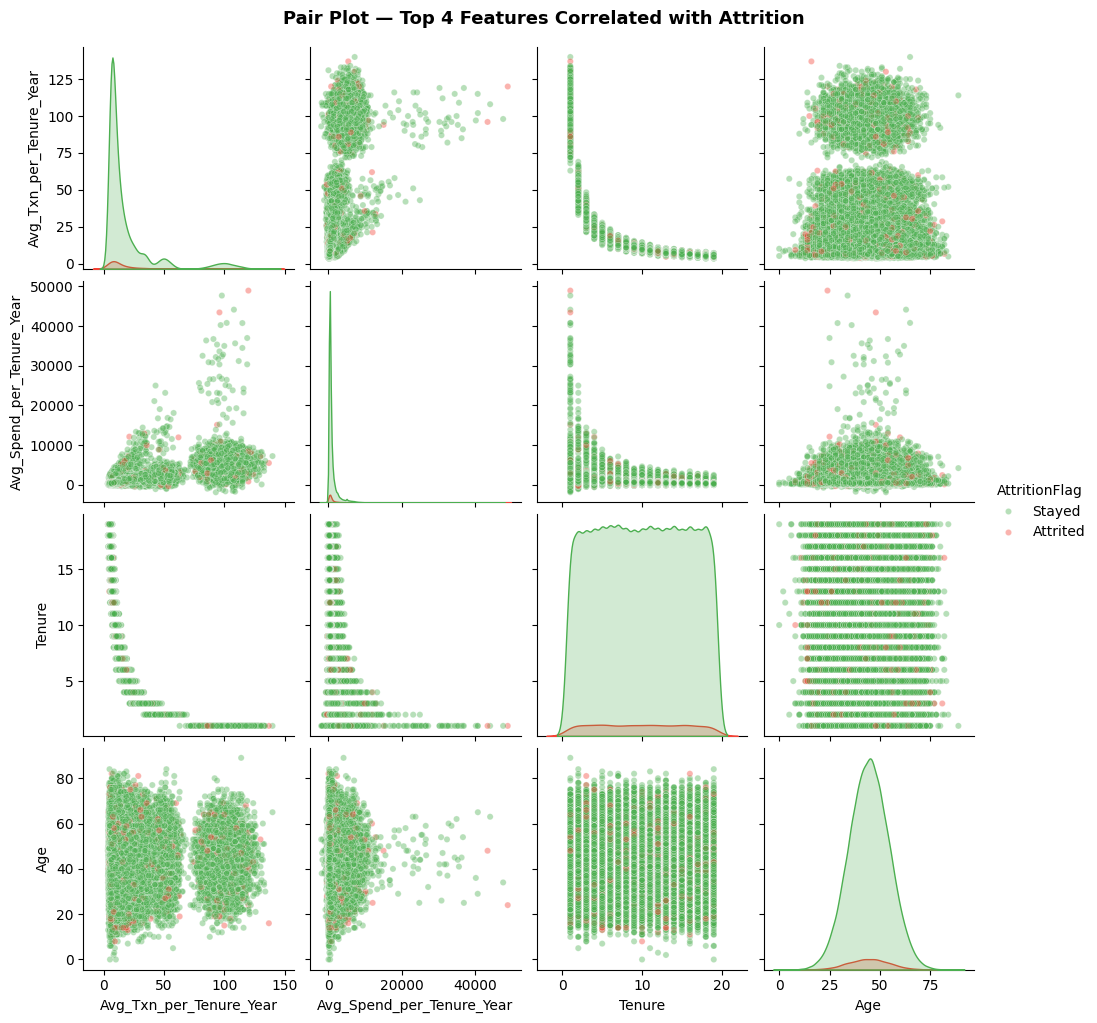


  TWO-SAMPLE T-TEST — Engineered Features vs AttritionFlag


,Mean_Stayed,Mean_Attrited,% Diff,T-Statistic,P-Value,Cohen's d,Effect Size,Result
Feature,,,,,,,,
Avg_Transaction_Value,52.4162,53.0434,1.20,-1.3585,0.174376,0.0204,Negligible,❌ Not Significant
Credit_Utilization,0.4276,0.4510,5.49,-0.7888,0.430252,0.0130,Negligible,❌ Not Significant
Spend_to_Income,0.0841,0.0822,-2.32,1.3557,0.175217,-0.0080,Negligible,❌ Not Significant
Income_to_CreditLimit,6.3165,6.2408,-1.20,0.2014,0.840363,-0.0025,Negligible,❌ Not Significant
Avg_Spend_per_Tenure_Year,965.0365,1013.4079,5.01,-2.0510,0.040317,0.0314,Negligible,✅ Significant
Avg_Txn_per_Tenure_Year,18.5808,19.3419,4.10,-2.2451,0.024801,0.0334,Negligible,✅ Significant



  ENGINEERED FEATURE SIGNAL SUMMARY

  Significant with meaningful effect (T-Test):
  None — rely on model feature importance

  Correlation signal vs AttritionFlag (Pearson ≥ 0.1):


,0
0,None above 0.1 threshold



  High multicollinearity flags (ρ ≥ 0.8) involving engineered features:


,Feature A,Feature B,Pearson_r,Flag
39,TotalSpend,Avg_Transaction_Value,0.9789,⚠️ HIGH
57,Credit_Utilization,Income_to_CreditLimit,0.8991,⚠️ HIGH


In [23]:
# @title
eng_cols = [
    'Avg_Transaction_Value', 'Credit_Utilization', 'Spend_to_Income',
    'Income_to_CreditLimit', 'Avg_Spend_per_Tenure_Year', 'Avg_Txn_per_Tenure_Year'
]
all_num_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions',
                'TotalSpend', 'Tenure'] + eng_cols

# -------------------------------------------------------------------
# 1. FEATURE-TARGET CORRELATION
# -------------------------------------------------------------------
print("=" * 60)
print("  FEATURE-TARGET CORRELATION — Engineered vs AttritionFlag")
print("=" * 60)

pearson_corr  = df_fe[all_num_cols + ['AttritionFlag']].corr(method='pearson')
spearman_corr = df_fe[all_num_cols + ['AttritionFlag']].corr(method='spearman')

target_corr = pd.DataFrame({
    'Pearson_r' : pearson_corr['AttritionFlag'].drop('AttritionFlag'),
    'Spearman_r': spearman_corr['AttritionFlag'].drop('AttritionFlag')
})
target_corr['Abs_Pearson'] = target_corr['Pearson_r'].abs()
target_corr['Signal']      = target_corr['Abs_Pearson'].apply(
    lambda x: 'Strong' if x >= 0.3 else ('Moderate' if x >= 0.1 else 'Weak')
)
target_corr = target_corr.sort_values('Abs_Pearson', ascending=False)

display(target_corr.drop(columns='Abs_Pearson').round(4))

# -------------------------------------------------------------------
# 2. CORRELATION HEATMAP — Engineered Features Only
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr, title in zip(axes,
                            [pearson_corr, spearman_corr],
                            ['Pearson', 'Spearman']):
    sub = corr.loc[eng_cols + ['AttritionFlag'], eng_cols + ['AttritionFlag']]
    mask = np.triu(np.ones_like(sub, dtype=bool))
    sns.heatmap(sub, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, vmin=-1, vmax=1, ax=ax,
                linewidths=0.5, annot_kws={'size': 9})
    ax.set_title(f'{title} — Engineered Features', fontsize=12, fontweight='bold')

plt.suptitle('Correlation Heatmap (Engineered Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------
# 3. MULTICOLLINEARITY — Pairwise + VIF (all numerical incl. engineered)
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  PAIRWISE CORRELATION — All Numerical Features")
print("=" * 60)

pair_corr = df_fe[all_num_cols].corr(method='pearson').round(4)
pairs = []
for i in range(len(all_num_cols)):
    for j in range(i+1, len(all_num_cols)):
        r = pair_corr.iloc[i, j]
        pairs.append({
            'Feature A': all_num_cols[i],
            'Feature B': all_num_cols[j],
            'Pearson_r': round(r, 4),
            'Abs_r'    : round(abs(r), 4),
            'Flag'     : '⚠️  HIGH' if abs(r) >= 0.8 else ('Moderate' if abs(r) >= 0.5 else 'Low')
        })

pair_df = (pd.DataFrame(pairs)
             .sort_values('Abs_r', ascending=False)
             .drop(columns='Abs_r'))
display(pair_df)

print("\n" + "=" * 60)
print("  VIF — All Numerical Features (incl. Engineered)")
print("=" * 60)

X_vif = add_constant(df_fe[all_num_cols].dropna())
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

vif_df['VIF']        = vif_df['VIF'].round(2)
vif_df['Assessment'] = vif_df['VIF'].apply(
    lambda x: '🚨 Severe'    if x >= 10 else
              ('⚠️  Moderate' if x >= 5  else
               '✅ Acceptable')
)
print(vif_df.to_string(index=False))

# -------------------------------------------------------------------
# 4. PAIR PLOT — Top 4 correlated with AttritionFlag
# -------------------------------------------------------------------
top_features = (target_corr['Abs_Pearson']
                .nlargest(4).index.tolist())

pair_plot_df = df_fe[top_features + ['AttritionFlag']].copy()
pair_plot_df['AttritionFlag'] = pair_plot_df['AttritionFlag'].map({0: 'Stayed', 1: 'Attrited'})

g = sns.pairplot(pair_plot_df, hue='AttritionFlag',
                 palette={'Stayed': '#4CAF50', 'Attrited': '#F44336'},
                 diag_kind='kde', plot_kws={'alpha': 0.4, 's': 20})
g.fig.suptitle('Pair Plot — Top 4 Features Correlated with Attrition',
               y=1.02, fontsize=13, fontweight='bold')
plt.show()

# -------------------------------------------------------------------
# 5. T-TEST — Engineered Features vs AttritionFlag
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  TWO-SAMPLE T-TEST — Engineered Features vs AttritionFlag")
print("=" * 60)

stayed   = df_fe[df_fe['AttritionFlag'] == 0]
attrited = df_fe[df_fe['AttritionFlag'] == 1]

ttest_records = []

for col in eng_cols:
    g0 = stayed[col].dropna()
    g1 = attrited[col].dropna()

    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)

    mean_stayed   = g0.mean()
    mean_attrited = g1.mean()
    pct_diff      = ((mean_attrited - mean_stayed) / mean_stayed * 100
                     if mean_stayed != 0 else float('nan'))

    pooled_std = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d   = (mean_attrited - mean_stayed) / pooled_std if pooled_std != 0 else 0

    ttest_records.append({
        'Feature'       : col,
        'Mean_Stayed'   : round(mean_stayed,   4),
        'Mean_Attrited' : round(mean_attrited, 4),
        '% Diff'        : round(pct_diff,      2),
        'T-Statistic'   : round(t_stat,        4),
        'P-Value'       : round(p_val,         6),
        "Cohen's d"     : round(cohens_d,      4),
        'Effect Size'   : ('Negligible' if abs(cohens_d) < 0.2 else
                           'Small'      if abs(cohens_d) < 0.5 else
                           'Medium'     if abs(cohens_d) < 0.8 else 'Large'),
        'Result'        : '✅ Significant' if p_val < 0.05 else '❌ Not Significant'
    })

ttest_eng_df = pd.DataFrame(ttest_records).set_index('Feature')
display(ttest_eng_df)

# -------------------------------------------------------------------
# 6. COMBINED SIGNAL SUMMARY
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  ENGINEERED FEATURE SIGNAL SUMMARY")
print("=" * 60)

print("\n  Significant with meaningful effect (T-Test):")
worthy = ttest_eng_df[
    (ttest_eng_df['Result'] == '✅ Significant') &
    (~ttest_eng_df['Effect Size'].isin(['Negligible']))
].index.tolist()
print(f"  {worthy if worthy else 'None — rely on model feature importance'}")

print("\n  Correlation signal vs AttritionFlag (Pearson ≥ 0.1):")
moderate_up = target_corr[
    (target_corr.index.isin(eng_cols)) &
    (target_corr['Abs_Pearson'] >= 0.1)
][['Pearson_r', 'Signal']]
display(moderate_up if not moderate_up.empty else pd.DataFrame(['None above 0.1 threshold']))

print("\n  High multicollinearity flags (ρ ≥ 0.8) involving engineered features:")
high_mc = pair_df[
    (pair_df['Flag'] == '⚠️  HIGH') &
    (pair_df['Feature A'].isin(eng_cols) | pair_df['Feature B'].isin(eng_cols))
]
display(high_mc if not high_mc.empty else pd.DataFrame(['No high multicollinearity detected']))

### 1.5 Section 1: Synthesis

**Key takeaway: raw features carry almost no discriminative signal for attrition.**

- **Univariate:** Continuous features (Age, Income, TotalSpend, TotalTransactions) show nearly identical distributions between attriters and non-attriters. Categorical features (CardType, Education, Marital Status, Gender, Country) are similarly balanced across both groups.
- **Bivariate:** Median comparisons and boxplots reveal negligible differences. Negative-spender churn lift is only +0.23 pp above baseline; tenure churn spikes are small.
- **Multivariate:** The correlation matrix confirms weak inter-feature relationships, with no feature pair revealing a hidden attrition pattern. VIF flagged TotalTransactions (27.7) and Age (17.8) as severely collinear -- relevant for linear models later.
- **Significance tests:** Every t-test and chi-square test returned *Not Significant* or *Negligible* effect sizes (all Cohen's d < 0.03, all Cramér's V < 0.01). Even after feature engineering, no engineered ratio produced a meaningful t-test signal or Pearson correlation ≥ 0.1 against AttritionFlag.

In short, Section 1 establishes that, statistically, the available features are not correlated with attrition. Section 2 will pressure-test this with business-oriented deep dives.

# 2.0 EDA (Full Raw Dataset)

Answers four business-question groups using the full, untruncated dataset.

- **2.1** Behavioral & Transactional Indicators
- **2.2** Tenure & Customer Lifecycle
- **2.3** Financial & Demographic Profiles
- **2.4** Social & Geographic Factors

### 2.0 Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import category_encoders as ce

# Load full dataset (no column truncation)
df_raw_eda = pd.read_csv(fr'C:\Users\Administrator\Desktop\UBP Application\credit_card_attrition_dataset_copino.csv')

# Same dedup + imputation as preprocessing pipeline
df_raw_eda = df_raw_eda.drop_duplicates()
for col in ['Income', 'CreditLimit', 'TotalSpend']:
    df_raw_eda[f'{col}_is_missing'] = df_raw_eda[col].isna().astype(int)
    df_raw_eda[col] = df_raw_eda[col].fillna(df_raw_eda[col].median())
for col in ['Income', 'CreditLimit', 'TotalSpend']:
    df_raw_eda[f'{col}_is_negative'] = (df_raw_eda[col] < 0).astype(int)

stayed_eda   = df_raw_eda[df_raw_eda['AttritionFlag'] == 0]
attrited_eda = df_raw_eda[df_raw_eda['AttritionFlag'] == 1]
global_churn = df_raw_eda['AttritionFlag'].mean()

print(f'Dataset shape     : {df_raw_eda.shape}')
print(f'Global churn rate : {global_churn:.4f} ({global_churn*100:.2f}%)')
print(f'Stayed            : {len(stayed_eda):,}')
print(f'Attrited          : {len(attrited_eda):,}')


Dataset shape     : (100000, 69)
Global churn rate : 0.0496 (4.96%)
Stayed            : 95,040
Attrited          : 4,960


### 2.1 Behavioral & Transactional Indicators

- Do churners have significantly lower `TotalTransactions` / `TotalSpend`?
- Does the credit utilization ratio (`TotalSpend / CreditLimit`) predict attrition?
- Do indicator flags (`_is_missing`, `_is_negative`) concentrate in churners?

ValueError: The palette dictionary is missing keys: {'0', '1'}

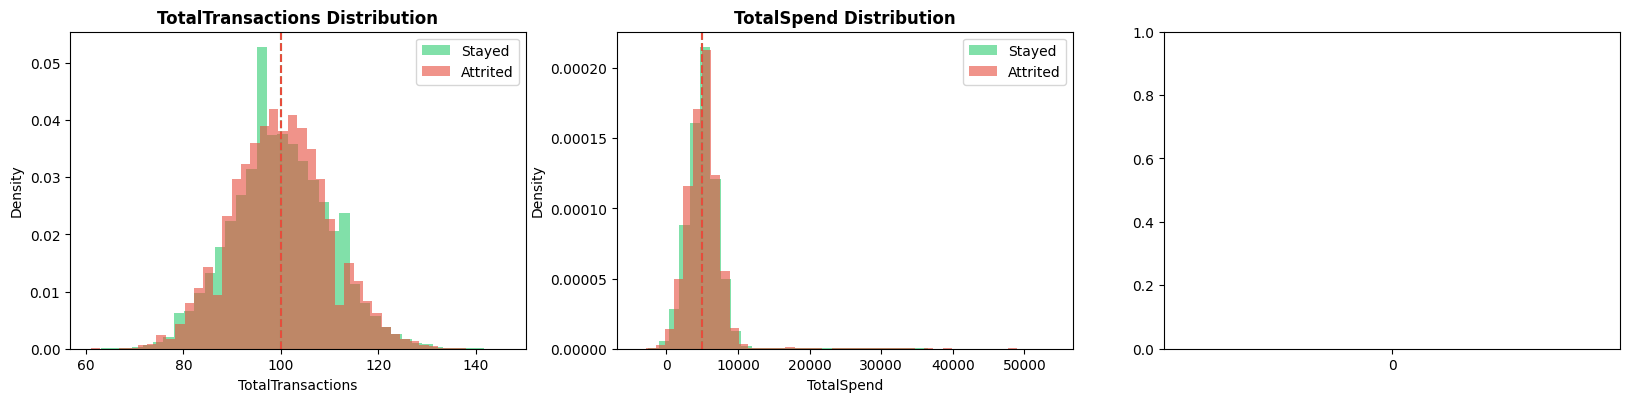

In [4]:
# Credit utilization computed for EDA only
df_raw_eda['Credit_Utilization_eda'] = np.where(
    df_raw_eda['CreditLimit'] > 0,
    df_raw_eda['TotalSpend'] / df_raw_eda['CreditLimit'], np.nan
)

fig = plt.figure(figsize=(20, 14))

# 1. TotalTransactions distribution
ax1 = fig.add_subplot(3, 3, 1)
for label, grp, color in [('Stayed', stayed_eda, '#2ecc71'), ('Attrited', attrited_eda, '#e74c3c')]:
    ax1.hist(grp['TotalTransactions'], bins=40, alpha=0.6, color=color,
             label=label, density=True, edgecolor='none')
ax1.axvline(stayed_eda['TotalTransactions'].median(),   color='#2ecc71', linestyle='--', lw=1.5)
ax1.axvline(attrited_eda['TotalTransactions'].median(), color='#e74c3c', linestyle='--', lw=1.5)
ax1.set_title('TotalTransactions Distribution', fontweight='bold')
ax1.set_xlabel('TotalTransactions'); ax1.set_ylabel('Density'); ax1.legend()

# 2. TotalSpend distribution
ax2 = fig.add_subplot(3, 3, 2)
for label, grp, color in [('Stayed', stayed_eda, '#2ecc71'), ('Attrited', attrited_eda, '#e74c3c')]:
    ax2.hist(grp['TotalSpend'], bins=40, alpha=0.6, color=color,
             label=label, density=True, edgecolor='none')
ax2.axvline(stayed_eda['TotalSpend'].median(),   color='#2ecc71', linestyle='--', lw=1.5)
ax2.axvline(attrited_eda['TotalSpend'].median(), color='#e74c3c', linestyle='--', lw=1.5)
ax2.set_title('TotalSpend Distribution', fontweight='bold')
ax2.set_xlabel('TotalSpend'); ax2.set_ylabel('Density'); ax2.legend()

# 3. Credit utilization boxplot
ax3 = fig.add_subplot(3, 3, 3)
sns.boxplot(data=df_raw_eda, x='AttritionFlag', y='Credit_Utilization_eda',
            palette={0: '#2ecc71', 1: '#e74c3c'}, ax=ax3, showfliers=False)
ax3.set_xticklabels(['Stayed', 'Attrited'])
ax3.set_title('Credit Utilization by Attrition\n(TotalSpend / CreditLimit)', fontweight='bold')
ax3.set_ylabel('Utilization Ratio')

# 4. TotalSpend vs CreditLimit scatter
ax4 = fig.add_subplot(3, 3, 4)
sample = df_raw_eda.sample(min(5000, len(df_raw_eda)), random_state=42)
colors_s = sample['AttritionFlag'].map({0: '#2ecc71', 1: '#e74c3c'})
ax4.scatter(sample['CreditLimit'], sample['TotalSpend'], c=colors_s, alpha=0.3, s=8)
ax4.set_title('TotalSpend vs CreditLimit\n(green=Stayed, red=Attrited)', fontweight='bold')
ax4.set_xlabel('CreditLimit'); ax4.set_ylabel('TotalSpend')

# 5-8. Indicator flag churn concentration
flag_cols = [c for c in df_raw_eda.columns
             if c.endswith('_is_missing') or c.endswith('_is_negative')]
for idx, col in enumerate(flag_cols[:4]):
    ax = fig.add_subplot(3, 3, 5 + idx)
    churn_by_flag = df_raw_eda.groupby(col)['AttritionFlag'].mean() * 100
    bars = ax.bar(churn_by_flag.index.map({0: 'Normal', 1: 'Flagged'}),
                  churn_by_flag.values,
                  color=['#95a5a6', '#e74c3c'], edgecolor='black', width=0.5)
    ax.axhline(global_churn * 100, color='black', linestyle='--',
               label=f'Global ({global_churn*100:.1f}%)', lw=1.2)
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_title(f'Churn Rate by\n{col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)'); ax.legend(fontsize=8)

plt.suptitle('3.1 - Behavioral & Transactional Indicators', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


In [5]:
print('=' * 65)
print('  3.1 BEHAVIORAL & TRANSACTIONAL - QUANTIFIED')
print('=' * 65)

# Q1: TotalTransactions + TotalSpend
print('\n-- Q1: TotalTransactions & TotalSpend by Attrition')
for col in ['TotalTransactions', 'TotalSpend']:
    g0 = stayed_eda[col].dropna()
    g1 = attrited_eda[col].dropna()
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
    pooled_std    = np.sqrt((g0.std()**2 + g1.std()**2) / 2)
    cohens_d      = (g1.mean() - g0.mean()) / pooled_std
    pct_diff      = (g1.median() - g0.median()) / g0.median() * 100
    eff = ('Large' if abs(cohens_d)>=0.8 else 'Medium' if abs(cohens_d)>=0.5
           else 'Small' if abs(cohens_d)>=0.2 else 'Negligible')
    print(f'\n  {col}')
    print(f'    Median  Stayed: {g0.median():>10,.2f}  |  Attrited: {g1.median():>10,.2f}  ({pct_diff:+.1f}%)')
    print(f'    Mean    Stayed: {g0.mean():>10,.2f}  |  Attrited: {g1.mean():>10,.2f}')
    print(f"    T-test p-value : {p_val:.6f}  {'Significant' if p_val < 0.05 else 'Not Significant'}")
    print(f"    Cohen's d      : {cohens_d:.4f}  ({eff})")

# Q2: Credit Utilization
print('\n-- Q2: Credit Utilization (TotalSpend / CreditLimit)')
u0 = df_raw_eda.loc[df_raw_eda['AttritionFlag']==0, 'Credit_Utilization_eda'].dropna()
u1 = df_raw_eda.loc[df_raw_eda['AttritionFlag']==1, 'Credit_Utilization_eda'].dropna()
t_u, p_u = stats.ttest_ind(u0, u1, equal_var=False)
d_u = (u1.mean() - u0.mean()) / np.sqrt((u0.std()**2 + u1.std()**2) / 2)
print(f'  Median Utilization Stayed  : {u0.median():.4f}')
print(f'  Median Utilization Attrited: {u1.median():.4f}  ({(u1.median()-u0.median())/u0.median()*100:+.2f}%)')
print(f"  T-test p-value             : {p_u:.6f}  {'Significant' if p_u < 0.05 else 'Not Significant'}")
print(f"  Cohen's d                  : {d_u:.4f}")
print(f"  Pearson r  (vs AttritionFlag): {df_raw_eda['Credit_Utilization_eda'].corr(df_raw_eda['AttritionFlag']):.4f}")
print(f"  Spearman r (vs AttritionFlag): {df_raw_eda['Credit_Utilization_eda'].corr(df_raw_eda['AttritionFlag'], method='spearman'):.4f}")

# Q3: Indicator flags
print('\n-- Q3: Indicator Flag Churn Concentration')
flag_cols_all = [c for c in df_raw_eda.columns
                 if c.endswith('_is_missing') or c.endswith('_is_negative')]
for col in flag_cols_all:
    grp = df_raw_eda.groupby(col)['AttritionFlag'].agg(['count','mean']).reset_index()
    grp.columns = [col, 'Count', 'ChurnRate']
    grp['ChurnRate_Pct'] = (grp['ChurnRate'] * 100).round(2)
    grp['Lift_pp']       = (grp['ChurnRate_Pct'] - global_churn * 100).round(2)
    grp[col] = grp[col].map({0: 'Normal', 1: 'Flagged'})
    print(f'\n  {col}:')
    print(grp[[col, 'Count', 'ChurnRate_Pct', 'Lift_pp']].to_string(index=False))


  3.1 BEHAVIORAL & TRANSACTIONAL - QUANTIFIED

-- Q1: TotalTransactions & TotalSpend by Attrition

  TotalTransactions
    Median  Stayed:     100.00  |  Attrited:     100.00  (+0.0%)
    Mean    Stayed:     100.00  |  Attrited:      99.90
    T-test p-value : 0.498947  Not Significant
    Cohen's d      : -0.0098  (Negligible)

  TotalSpend
    Median  Stayed:   5,029.23  |  Attrited:   5,029.23  (+0.0%)
    Mean    Stayed:   5,188.31  |  Attrited:   5,247.43
    T-test p-value : 0.185915  Not Significant
    Cohen's d      : 0.0198  (Negligible)

-- Q2: Credit Utilization (TotalSpend / CreditLimit)
  Median Utilization Stayed  : 0.3361
  Median Utilization Attrited: 0.3367  (+0.18%)
  T-test p-value             : 0.428528  Not Significant
  Cohen's d                  : 0.0130
  Pearson r  (vs AttritionFlag): 0.0033
  Spearman r (vs AttritionFlag): 0.0011

-- Q3: Indicator Flag Churn Concentration

  Income_is_missing:
Income_is_missing  Count  ChurnRate_Pct  Lift_pp
           Normal

### 2.2 Tenure & Customer Lifecycle

- At what Tenure year do customers most frequently churn?
- Is there a 'danger zone'? Does long tenure protect against attrition?

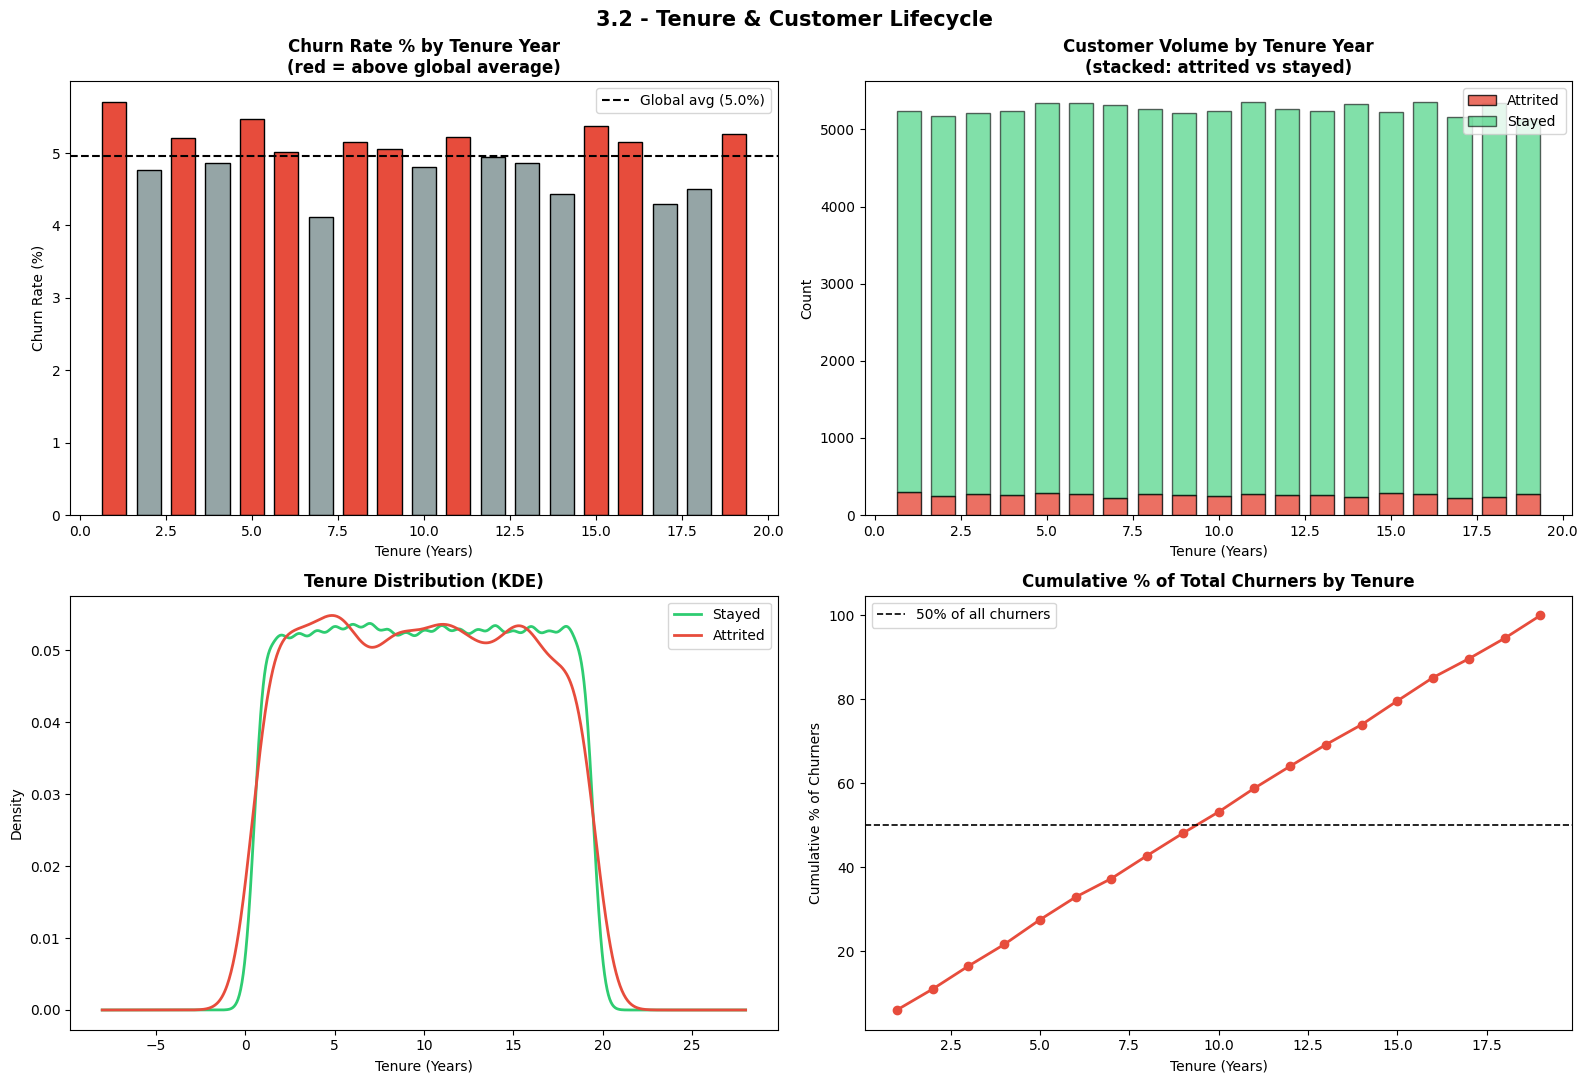

In [9]:
tenure_stats = df_raw_eda.groupby('Tenure').agg(
    Total    = ('AttritionFlag', 'count'),
    Attrited = ('AttritionFlag', 'sum'),
    ChurnPct = ('AttritionFlag', lambda x: x.mean() * 100)
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# 1. Churn rate by tenure year
ax = axes[0, 0]
colors_t = ['#e74c3c' if r > global_churn*100 else '#95a5a6'
            for r in tenure_stats['ChurnPct']]
ax.bar(tenure_stats['Tenure'], tenure_stats['ChurnPct'],
       color=colors_t, edgecolor='black', width=0.7)
ax.axhline(global_churn*100, color='black', linestyle='--', lw=1.5,
           label=f'Global avg ({global_churn*100:.1f}%)')
ax.set_title('Churn Rate % by Tenure Year\n(red = above global average)', fontweight='bold')
ax.set_xlabel('Tenure (Years)'); ax.set_ylabel('Churn Rate (%)'); ax.legend()

# 2. Stacked volume bar
ax2 = axes[0, 1]
ax2.bar(tenure_stats['Tenure'], tenure_stats['Attrited'],
        color='#e74c3c', edgecolor='black', width=0.7, alpha=0.8, label='Attrited')
ax2.bar(tenure_stats['Tenure'], tenure_stats['Total'] - tenure_stats['Attrited'],
        bottom=tenure_stats['Attrited'],
        color='#2ecc71', edgecolor='black', width=0.7, alpha=0.6, label='Stayed')
ax2.set_title('Customer Volume by Tenure Year\n(stacked: attrited vs stayed)', fontweight='bold')
ax2.set_xlabel('Tenure (Years)'); ax2.set_ylabel('Count'); ax2.legend()

# 3. KDE
ax3 = axes[1, 0]
stayed_eda['Tenure'].plot(kind='kde', ax=ax3, color='#2ecc71', lw=2, label='Stayed')
attrited_eda['Tenure'].plot(kind='kde', ax=ax3, color='#e74c3c', lw=2, label='Attrited')
ax3.set_title('Tenure Distribution (KDE)', fontweight='bold')
ax3.set_xlabel('Tenure (Years)'); ax3.set_ylabel('Density'); ax3.legend()

# 4. Cumulative churn
ax4 = axes[1, 1]
tc = tenure_stats.sort_values('Tenure').copy()
tc['Cumul_Attrited'] = tc['Attrited'].cumsum()
tc['Cumul_Pct']      = tc['Cumul_Attrited'] / tc['Attrited'].sum() * 100
ax4.plot(tc['Tenure'], tc['Cumul_Pct'], marker='o', color='#e74c3c', lw=2)
ax4.axhline(50, color='black', linestyle='--', lw=1.2, label='50% of all churners')
ax4.set_title('Cumulative % of Total Churners by Tenure', fontweight='bold')
ax4.set_xlabel('Tenure (Years)'); ax4.set_ylabel('Cumulative % of Churners'); ax4.legend()

plt.suptitle('3.2 - Tenure & Customer Lifecycle', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


In [10]:
print('=' * 65)
print('  3.2 TENURE & LIFECYCLE - QUANTIFIED')
print('=' * 65)

danger = tenure_stats[tenure_stats['ChurnPct'] > global_churn*100].sort_values('ChurnPct', ascending=False)
print(f'\n  Global churn rate: {global_churn*100:.2f}%')
print('\n  Danger Zones (above global churn rate):')
print(danger[['Tenure','Total','Attrited','ChurnPct']].to_string(index=False))

t_stat_t, p_val_t = stats.ttest_ind(stayed_eda['Tenure'], attrited_eda['Tenure'], equal_var=False)
d_t = (attrited_eda['Tenure'].mean() - stayed_eda['Tenure'].mean()) / \
      np.sqrt((stayed_eda['Tenure'].std()**2 + attrited_eda['Tenure'].std()**2) / 2)
print('\n  Tenure Group Comparison:')
print(f'  Median Tenure Stayed  : {stayed_eda["Tenure"].median():.1f} years')
print(f'  Median Tenure Attrited: {attrited_eda["Tenure"].median():.1f} years')
print(f"  T-test p-value        : {p_val_t:.6f}  {'Significant' if p_val_t < 0.05 else 'Not Significant'}")
print(f"  Cohen's d             : {d_t:.4f}")

tc = tenure_stats.sort_values('Tenure').copy()
tc['Cumul_Pct'] = tc['Attrited'].cumsum() / tc['Attrited'].sum() * 100
half = tc[tc['Cumul_Pct'] >= 50].iloc[0]
print(f'\n  50% of all churns occurred by Tenure year: {int(half["Tenure"])}')

spearman_t = df_raw_eda['Tenure'].corr(df_raw_eda['AttritionFlag'], method='spearman')
print(f'\n  Spearman r (Tenure vs AttritionFlag): {spearman_t:.4f}')
print(f"  Signal: {'Strong' if abs(spearman_t)>=0.3 else 'Moderate' if abs(spearman_t)>=0.1 else 'Weak'}")


  3.2 TENURE & LIFECYCLE - QUANTIFIED

  Global churn rate: 4.96%

  Danger Zones (above global churn rate):
 Tenure  Total  Attrited  ChurnPct
      1   5238       299  5.708286
      5   5340       292  5.468165
     15   5229       281  5.373876
     19   5133       270  5.260082
     11   5359       280  5.224855
      3   5220       272  5.210728
     16   5355       276  5.154062
      8   5266       271  5.146221
      9   5217       264  5.060380
      6   5337       268  5.021548

  Tenure Group Comparison:
  Median Tenure Stayed  : 10.0 years
  Median Tenure Attrited: 10.0 years
  T-test p-value        : 0.103823  Not Significant
  Cohen's d             : -0.0238

  50% of all churns occurred by Tenure year: 10

  Spearman r (Tenure vs AttritionFlag): -0.0052
  Signal: Weak


### 2.3 Financial & Demographic Profiles

- Does `Income` level correlate with churn? Which bracket is most at-risk?
- How does `Age` impact attrition? Is the bank losing younger customers?
- Does `CardType` predict loyalty?

ValueError: The palette dictionary is missing keys: {'0', '1'}

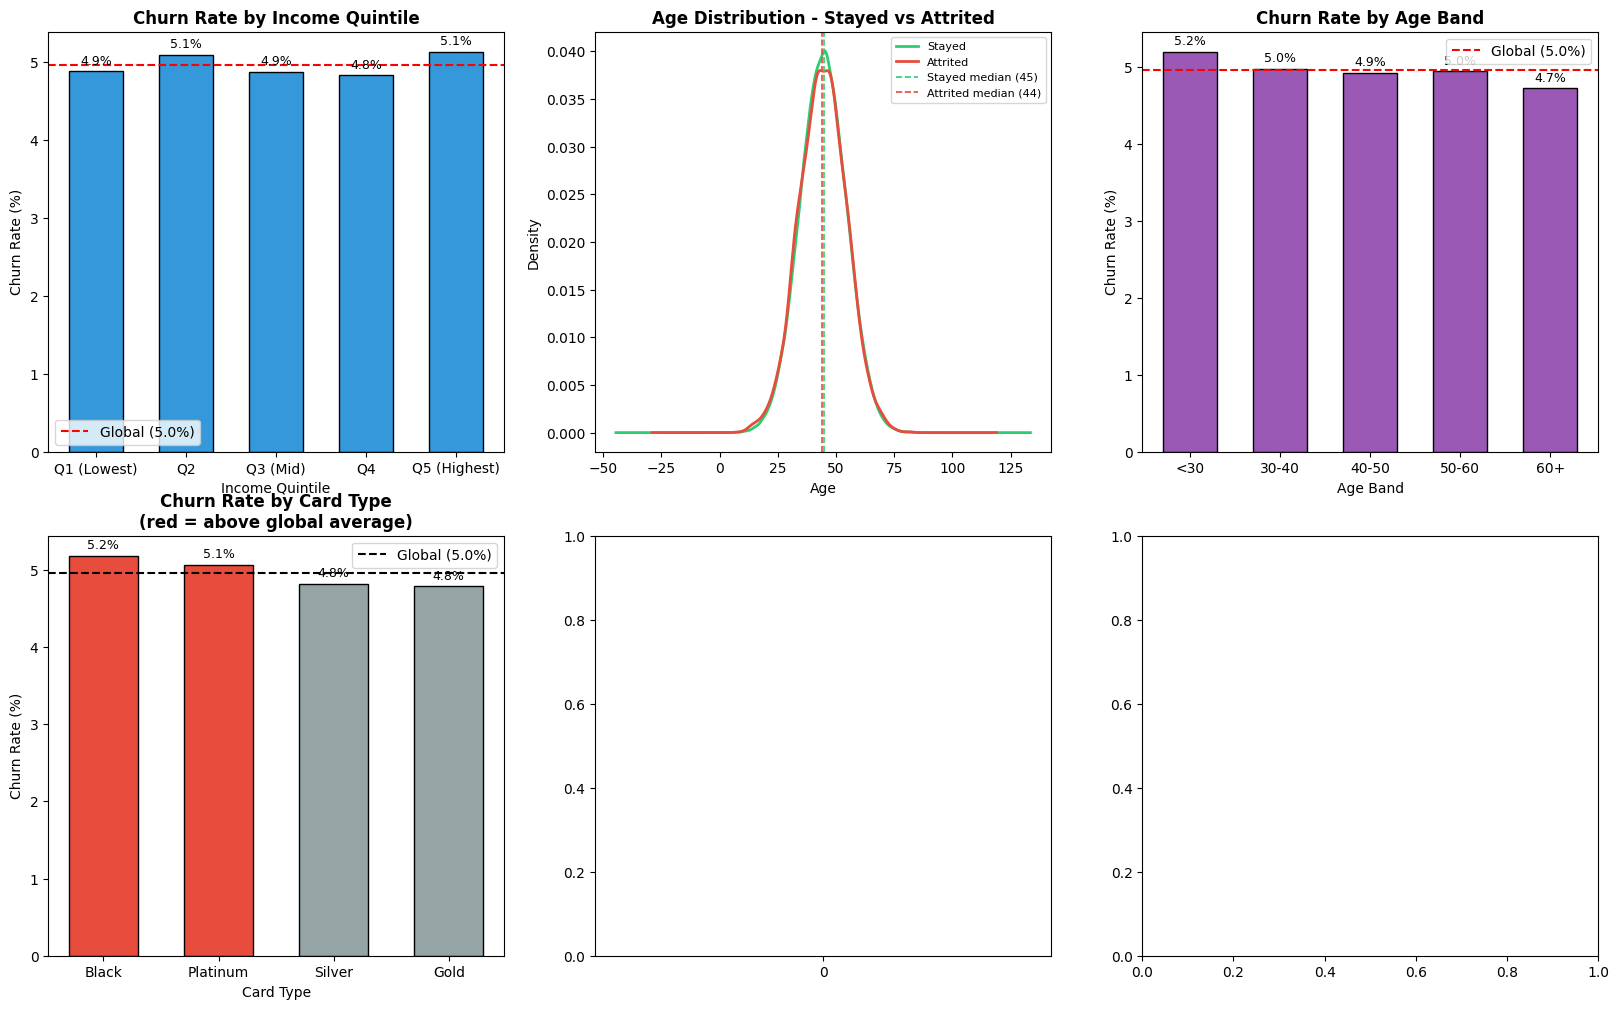

In [11]:
df_raw_eda['Income_Quintile'] = pd.qcut(df_raw_eda['Income'], q=5,
    labels=['Q1 (Lowest)', 'Q2', 'Q3 (Mid)', 'Q4', 'Q5 (Highest)'])
df_raw_eda['Age_Band'] = pd.cut(df_raw_eda['Age'], bins=[0,30,40,50,60,100],
    labels=['<30','30-40','40-50','50-60','60+'])

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Churn rate by income quintile
ax = axes[0, 0]
income_churn = df_raw_eda.groupby('Income_Quintile', observed=True)['AttritionFlag'].agg(
    ['mean','count','sum']).reset_index()
income_churn.columns = ['Quintile','ChurnRate','Total','Attrited']
bars = ax.bar(income_churn['Quintile'], income_churn['ChurnRate']*100,
              color='#3498db', edgecolor='black', width=0.6)
ax.axhline(global_churn*100, color='red', linestyle='--', lw=1.5,
           label=f'Global ({global_churn*100:.1f}%)')
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_title('Churn Rate by Income Quintile', fontweight='bold')
ax.set_xlabel('Income Quintile'); ax.set_ylabel('Churn Rate (%)'); ax.legend()

# 2. Age KDE
ax2 = axes[0, 1]
stayed_eda['Age'].plot(kind='kde', ax=ax2, color='#2ecc71', lw=2, label='Stayed')
attrited_eda['Age'].plot(kind='kde', ax=ax2, color='#e74c3c', lw=2, label='Attrited')
ax2.axvline(stayed_eda['Age'].median(),   color='#2ecc71', linestyle='--', lw=1.2,
            label=f'Stayed median ({stayed_eda["Age"].median():.0f})')
ax2.axvline(attrited_eda['Age'].median(), color='#e74c3c', linestyle='--', lw=1.2,
            label=f'Attrited median ({attrited_eda["Age"].median():.0f})')
ax2.set_title('Age Distribution - Stayed vs Attrited', fontweight='bold')
ax2.set_xlabel('Age'); ax2.set_ylabel('Density'); ax2.legend(fontsize=8)

# 3. Churn rate by age band
ax3 = axes[0, 2]
age_churn = df_raw_eda.groupby('Age_Band', observed=True)['AttritionFlag'].agg(
    ['mean','count','sum']).reset_index()
age_churn.columns = ['Band','ChurnRate','Total','Attrited']
bars3 = ax3.bar(age_churn['Band'], age_churn['ChurnRate']*100,
                color='#9b59b6', edgecolor='black', width=0.6)
ax3.axhline(global_churn*100, color='red', linestyle='--', lw=1.5,
            label=f'Global ({global_churn*100:.1f}%)')
ax3.bar_label(bars3, fmt='%.1f%%', padding=3, fontsize=9)
ax3.set_title('Churn Rate by Age Band', fontweight='bold')
ax3.set_xlabel('Age Band'); ax3.set_ylabel('Churn Rate (%)'); ax3.legend()

# 4. CardType churn rate
ax4 = axes[1, 0]
card_churn = df_raw_eda.groupby('CardType')['AttritionFlag'].agg(
    ['mean','count','sum']).reset_index()
card_churn.columns = ['CardType','ChurnRate','Total','Attrited']
card_churn = card_churn.sort_values('ChurnRate', ascending=False)
bar_c = ['#e74c3c' if r > global_churn else '#95a5a6' for r in card_churn['ChurnRate']]
bars4 = ax4.bar(card_churn['CardType'], card_churn['ChurnRate']*100,
                color=bar_c, edgecolor='black', width=0.6)
ax4.axhline(global_churn*100, color='black', linestyle='--', lw=1.5,
            label=f'Global ({global_churn*100:.1f}%)')
ax4.bar_label(bars4, fmt='%.1f%%', padding=3, fontsize=9)
ax4.set_title('Churn Rate by Card Type\n(red = above global average)', fontweight='bold')
ax4.set_xlabel('Card Type'); ax4.set_ylabel('Churn Rate (%)'); ax4.legend()

# 5. Income boxplot
ax5 = axes[1, 1]
sns.boxplot(data=df_raw_eda, x='AttritionFlag', y='Income',
            palette={0: '#2ecc71', 1: '#e74c3c'}, ax=ax5, showfliers=False)
ax5.set_xticklabels(['Stayed', 'Attrited'])
ax5.set_title('Income Distribution by Attrition\n(outliers hidden)', fontweight='bold')
ax5.set_ylabel('Income')

# 6. CardType stacked volume
ax6 = axes[1, 2]
card_pivot = df_raw_eda.groupby(['CardType','AttritionFlag']).size().unstack(fill_value=0)
card_pivot.columns = ['Stayed','Attrited']
card_pivot[['Stayed','Attrited']].plot(kind='bar', stacked=True, ax=ax6,
    color=['#2ecc71','#e74c3c'], edgecolor='black', width=0.6)
ax6.set_title('Customer Volume by Card Type', fontweight='bold')
ax6.set_xlabel('Card Type'); ax6.set_ylabel('Count')
ax6.tick_params(axis='x', rotation=0); ax6.legend()

plt.suptitle('3.3 - Financial & Demographic Profiles', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


In [ ]:
print('=' * 65)
print('  3.3 FINANCIAL & DEMOGRAPHIC - QUANTIFIED')
print('=' * 65)

# Income
print('\n-- Income vs Attrition')
g0_i, g1_i = stayed_eda['Income'].dropna(), attrited_eda['Income'].dropna()
t_i, p_i   = stats.ttest_ind(g0_i, g1_i, equal_var=False)
d_i        = (g1_i.mean() - g0_i.mean()) / np.sqrt((g0_i.std()**2 + g1_i.std()**2) / 2)
print(f'  Median Stayed  : ${g0_i.median():>10,.0f}')
print(f'  Median Attrited: ${g1_i.median():>10,.0f}  ({(g1_i.median()-g0_i.median())/g0_i.median()*100:+.1f}%)')
print(f"  T-test p-value : {p_i:.6f}  {'Significant' if p_i < 0.05 else 'Not Significant'}")
print(f"  Cohen's d      : {d_i:.4f}")
print('\n  Churn rate by Income Quintile:')
print(income_churn.assign(
    ChurnRate=(income_churn['ChurnRate']*100).round(2).astype(str)+'%',
    Lift_pp=((income_churn['ChurnRate']-global_churn)*100).round(2).astype(str)+'pp'
)[['Quintile','Total','Attrited','ChurnRate','Lift_pp']].to_string(index=False))

# Age
print('\n-- Age vs Attrition')
g0_a, g1_a = stayed_eda['Age'].dropna(), attrited_eda['Age'].dropna()
t_a, p_a   = stats.ttest_ind(g0_a, g1_a, equal_var=False)
d_a        = (g1_a.mean() - g0_a.mean()) / np.sqrt((g0_a.std()**2 + g1_a.std()**2) / 2)
print(f'  Median Stayed  : {g0_a.median():.1f} yrs')
print(f'  Median Attrited: {g1_a.median():.1f} yrs  ({(g1_a.median()-g0_a.median())/g0_a.median()*100:+.1f}%)')
print(f"  T-test p-value : {p_a:.6f}  {'Significant' if p_a < 0.05 else 'Not Significant'}")
print(f"  Cohen's d      : {d_a:.4f}")
print('\n  Churn rate by Age Band:')
print(age_churn.assign(
    ChurnRate=(age_churn['ChurnRate']*100).round(2).astype(str)+'%',
    Lift_pp=((age_churn['ChurnRate']-global_churn)*100).round(2).astype(str)+'pp'
)[['Band','Total','Attrited','ChurnRate','Lift_pp']].to_string(index=False))

# CardType
print('\n-- CardType vs Attrition (Chi-Square)')
ct_table = pd.crosstab(df_raw_eda['CardType'], df_raw_eda['AttritionFlag'])
chi2_ct, p_ct, dof_ct, _ = stats.chi2_contingency(ct_table)
n_ct      = ct_table.sum().sum()
cramers_v = np.sqrt(chi2_ct / (n_ct * (min(ct_table.shape) - 1)))
eff_ct = ('Large' if cramers_v>=0.5 else 'Medium' if cramers_v>=0.3
          else 'Small' if cramers_v>=0.1 else 'Negligible')
print(f"  Chi2={chi2_ct:.4f}  p={p_ct:.6f}  Cramer's V={cramers_v:.4f}"
      f"  -> {'Significant' if p_ct<0.05 else 'Not Significant'} | Effect: {eff_ct}")
print('\n  Churn rate by CardType:')
print(card_churn.assign(
    ChurnRate=(card_churn['ChurnRate']*100).round(2).astype(str)+'%',
    Lift_pp=((card_churn['ChurnRate']-global_churn)*100).round(2).astype(str)+'pp'
)[['CardType','Total','Attrited','ChurnRate','Lift_pp']].to_string(index=False))


### 2.4 Social & Geographic Factors

- Do `Gender`, `MaritalStatus`, `EducationLevel` show statistically significant attrition differences?
- Do target-encoded `Country` values reveal high-flight-risk regions?

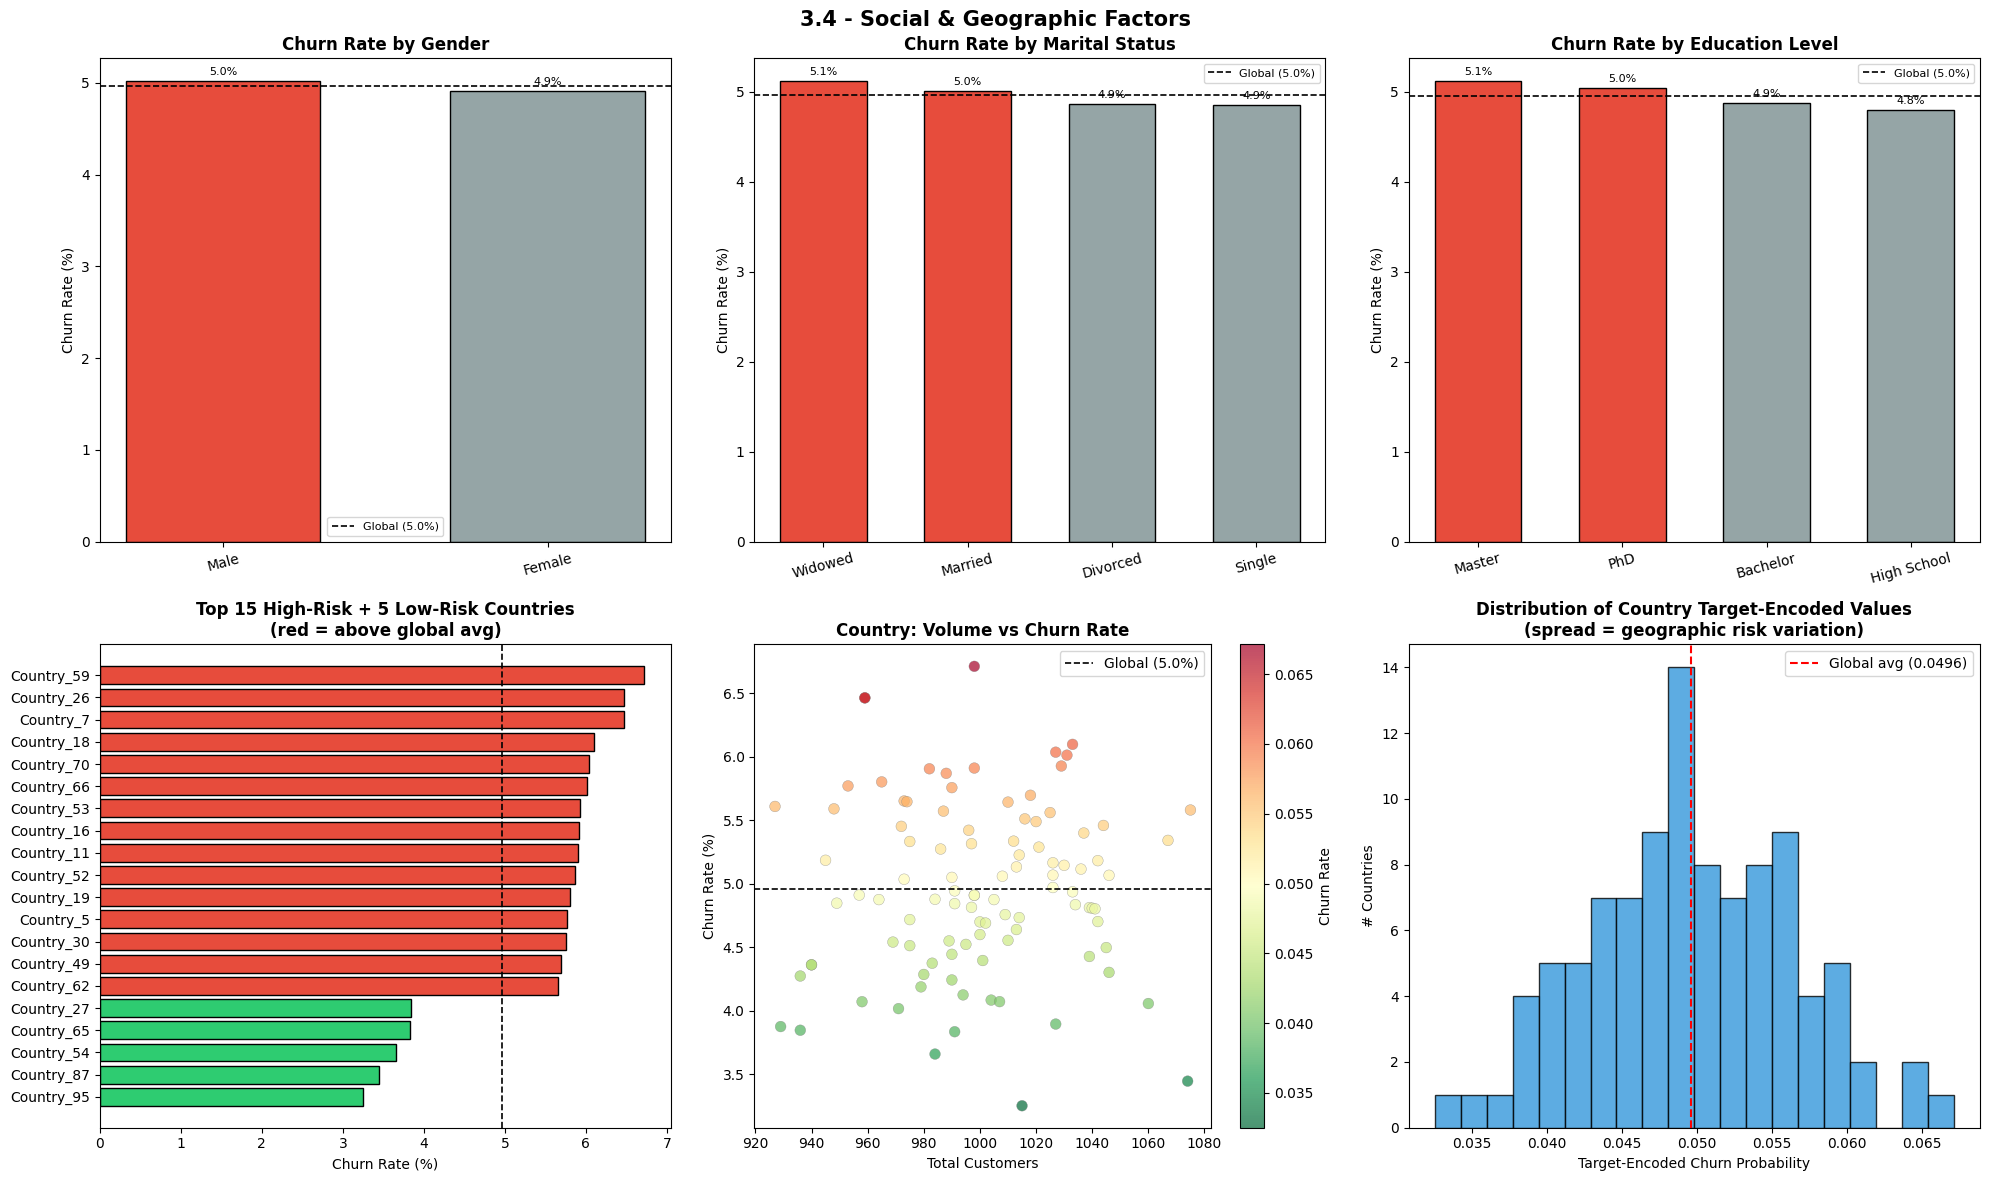

In [12]:
# Target encode Country on full dataset for EDA only
# Note: this is NOT the train-only encoding used in modeling (4.9)
te_eda = ce.TargetEncoder(cols=['Country'], min_samples_leaf=20, smoothing=10.0)
df_raw_eda['Country_TE_eda'] = te_eda.fit_transform(
    df_raw_eda[['Country']], df_raw_eda['AttritionFlag']
)['Country']

country_summary = df_raw_eda.groupby('Country').agg(
    ChurnRate      = ('AttritionFlag', 'mean'),
    TotalCustomers = ('AttritionFlag', 'count'),
    Attrited       = ('AttritionFlag', 'sum'),
    TE_Value       = ('Country_TE_eda', 'mean')
).reset_index().sort_values('ChurnRate', ascending=False)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

def churn_bar_plot(ax, col, title):
    grp = df_raw_eda.groupby(col)['AttritionFlag'].agg(['mean','count','sum']).reset_index()
    grp.columns = [col,'ChurnRate','Total','Attrited']
    grp = grp.sort_values('ChurnRate', ascending=False)
    bar_c = ['#e74c3c' if r > global_churn else '#95a5a6' for r in grp['ChurnRate']]
    bars  = ax.bar(grp[col], grp['ChurnRate']*100, color=bar_c, edgecolor='black', width=0.6)
    ax.axhline(global_churn*100, color='black', linestyle='--', lw=1.2,
               label=f'Global ({global_churn*100:.1f}%)')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8)
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Churn Rate (%)')
    ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=8)
    return grp

churn_bar_plot(axes[0,0], 'Gender',         'Churn Rate by Gender')
churn_bar_plot(axes[0,1], 'MaritalStatus',  'Churn Rate by Marital Status')
churn_bar_plot(axes[0,2], 'EducationLevel', 'Churn Rate by Education Level')

# Top 15 high-risk + 5 low-risk countries
top_countries = pd.concat([country_summary.head(15),
                            country_summary.tail(5)]).drop_duplicates()
ax4 = axes[1, 0]
colors_c = ['#e74c3c' if r > global_churn else '#2ecc71'
            for r in top_countries['ChurnRate']]
ax4.barh(top_countries['Country'], top_countries['ChurnRate']*100,
         color=colors_c, edgecolor='black')
ax4.axvline(global_churn*100, color='black', linestyle='--', lw=1.2)
ax4.set_title('Top 15 High-Risk + 5 Low-Risk Countries\n(red = above global avg)', fontweight='bold')
ax4.set_xlabel('Churn Rate (%)'); ax4.invert_yaxis()

# Volume vs churn rate scatter
ax5 = axes[1, 1]
sc = ax5.scatter(country_summary['TotalCustomers'], country_summary['ChurnRate']*100,
                 c=country_summary['ChurnRate'], cmap='RdYlGn_r',
                 s=60, alpha=0.7, edgecolors='grey', lw=0.3)
ax5.axhline(global_churn*100, color='black', linestyle='--', lw=1.2,
            label=f'Global ({global_churn*100:.1f}%)')
ax5.set_title('Country: Volume vs Churn Rate', fontweight='bold')
ax5.set_xlabel('Total Customers'); ax5.set_ylabel('Churn Rate (%)'); ax5.legend()
plt.colorbar(sc, ax=ax5, label='Churn Rate')

# TE value histogram
ax6 = axes[1, 2]
ax6.hist(country_summary['TE_Value'], bins=20, color='#3498db', edgecolor='black', alpha=0.8)
ax6.axvline(global_churn, color='red', linestyle='--', lw=1.5,
            label=f'Global avg ({global_churn:.4f})')
ax6.set_title('Distribution of Country Target-Encoded Values\n(spread = geographic risk variation)',
              fontweight='bold')
ax6.set_xlabel('Target-Encoded Churn Probability')
ax6.set_ylabel('# Countries'); ax6.legend()

plt.suptitle('3.4 - Social & Geographic Factors', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


In [13]:
print('=' * 65)
print('  3.4 SOCIAL & GEOGRAPHIC - QUANTIFIED')
print('=' * 65)

# Chi-square for demographic categoricals
dem_cols = ['Gender', 'MaritalStatus', 'EducationLevel']
print('\n-- Chi-Square Tests - Demographic Categoricals')
for col in dem_cols:
    ct = pd.crosstab(df_raw_eda[col], df_raw_eda['AttritionFlag'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    n   = ct.sum().sum()
    cv  = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    eff = ('Large' if cv>=0.5 else 'Medium' if cv>=0.3
           else 'Small' if cv>=0.1 else 'Negligible')
    print(f'\n  {col}')
    print(f"    Chi2={chi2:.4f}  p={p:.6f}  Cramer's V={cv:.4f}"
          f"  -> {'Significant' if p<0.05 else 'Not Significant'} | Effect: {eff}")
    grp = df_raw_eda.groupby(col)['AttritionFlag'].agg(['mean','count','sum']).reset_index()
    grp.columns = [col,'ChurnRate','Total','Attrited']
    grp['ChurnRate_Pct'] = (grp['ChurnRate']*100).round(2)
    grp['Lift_pp']       = (grp['ChurnRate_Pct'] - global_churn*100).round(2)
    print(grp[[col,'Total','Attrited','ChurnRate_Pct','Lift_pp']]
          .sort_values('ChurnRate_Pct', ascending=False).to_string(index=False))

# Country geographic risk
print('\n-- Country: High-Flight-Risk Regions')
print(f'  Total unique countries : {df_raw_eda["Country"].nunique()}')
print(f'  Global churn rate      : {global_churn*100:.2f}%')
print(f'  TE value std deviation : {country_summary["TE_Value"].std():.4f}')
print(f'  TE min / max           : {country_summary["TE_Value"].min():.4f} / {country_summary["TE_Value"].max():.4f}')
spread_verdict = ('Wide spread - geography is a meaningful risk signal'
                  if country_summary['TE_Value'].std() > 0.02
                  else 'Narrow spread - geography adds little predictive value')
print(f'  -> {spread_verdict}')

high_risk = country_summary[country_summary['ChurnRate'] > global_churn * 1.5]
low_risk  = country_summary[country_summary['ChurnRate'] < global_churn * 0.5]
print(f'\n  High-risk countries (churn > 1.5x global): {len(high_risk)}')
if len(high_risk):
    print(high_risk[['Country','TotalCustomers','Attrited']].assign(
        ChurnRate=(high_risk['ChurnRate']*100).round(2).astype(str)+'%'
    ).head(10).to_string(index=False))
print(f'\n  Low-risk countries (churn < 0.5x global): {len(low_risk)}')
if len(low_risk):
    print(low_risk[['Country','TotalCustomers','Attrited']].assign(
        ChurnRate=(low_risk['ChurnRate']*100).round(2).astype(str)+'%'
    ).head(10).to_string(index=False))


  3.4 SOCIAL & GEOGRAPHIC - QUANTIFIED

-- Chi-Square Tests - Demographic Categoricals

  Gender
    Chi2=0.6174  p=0.432021  Cramer's V=0.0025  -> Not Significant | Effect: Negligible
Gender  Total  Attrited  ChurnRate_Pct  Lift_pp
  Male  49809      2498           5.02     0.06
Female  50191      2462           4.91    -0.05

  MaritalStatus
    Chi2=2.5431  p=0.467560  Cramer's V=0.0050  -> Not Significant | Effect: Negligible
MaritalStatus  Total  Attrited  ChurnRate_Pct  Lift_pp
      Widowed  24946      1276           5.12     0.16
      Married  25123      1259           5.01     0.05
     Divorced  25196      1224           4.86    -0.10
       Single  24735      1201           4.86    -0.10

  EducationLevel
    Chi2=3.3937  p=0.334806  Cramer's V=0.0058  -> Not Significant | Effect: Negligible
EducationLevel  Total  Attrited  ChurnRate_Pct  Lift_pp
        Master  25070      1283           5.12     0.16
           PhD  24904      1256           5.04     0.08
      Bachelor  2

### 2.5 Chapter Summary

In [14]:
print('=' * 65)
print('  CHAPTER 3 - KEY FINDINGS SUMMARY')
print('=' * 65)

sections = [
    ('3.1', 'TotalTransactions / TotalSpend', "Cohen's d — Large = strong signal"),
    ('3.1', 'Credit Utilization Ratio',       'Pearson r — meaningful if |r| > 0.1'),
    ('3.1', 'Missingness / Negative Flags',   'Lift_pp — keep if lift > 1pp'),
    ('3.2', 'Tenure Danger Zones',            'Years above global churn rate'),
    ('3.2', 'Long-Tenure Protection',         'Spearman r direction — negative = protective'),
    ('3.3', 'Income Quintile Gradient',       'Check if Q1 or Q5 drives churn'),
    ('3.3', 'Age Band Risk',                  'Which band has highest lift_pp'),
    ('3.3', 'CardType Loyalty Signal',        "Cramer's V — Small if < 0.1"),
    ('3.4', 'Gender / Marital / Education',   "Cramer's V — flag if > 0.1"),
    ('3.4', 'Country Geographic Risk',        'TE std dev + high-risk country list'),
]

print(f'\n  {"Section":<6} {"Feature":<32} {"What to look for"}')
print(f'  {"-"*6} {"-"*32} {"-"*35}')
for sec, feat, note in sections:
    print(f'  {sec:<6} {feat:<32} {note}')

print('\nModeling Implications:')
print('  Strong signal (large effect sizes)  -> prioritize in feature importance analysis')
print('  Weak signal (negligible effects)    -> still include; XGBoost/EBM will down-weight')
print('  Tenure danger zones                 -> consider engineering a binary is_danger_tenure flag')
print('  High-risk country clusters          -> target-encoded Country value should carry weight')


  CHAPTER 3 - KEY FINDINGS SUMMARY

  Section Feature                          What to look for
  ------ -------------------------------- -----------------------------------
  3.1    TotalTransactions / TotalSpend   Cohen's d — Large = strong signal
  3.1    Credit Utilization Ratio         Pearson r — meaningful if |r| > 0.1
  3.1    Missingness / Negative Flags     Lift_pp — keep if lift > 1pp
  3.2    Tenure Danger Zones              Years above global churn rate
  3.2    Long-Tenure Protection           Spearman r direction — negative = protective
  3.3    Income Quintile Gradient         Check if Q1 or Q5 drives churn
  3.3    Age Band Risk                    Which band has highest lift_pp
  3.3    CardType Loyalty Signal          Cramer's V — Small if < 0.1
  3.4    Gender / Marital / Education     Cramer's V — flag if > 0.1
  3.4    Country Geographic Risk          TE std dev + high-risk country list

Modeling Implications:
  Strong signal (large effect sizes)  -> prioritize in 

### 2.6 Section 2: Synthesis

**Key takeaway: the deep-dive confirms Section 1 in which features do not meaningfully separate attriters from non-attriters.**

- **Behavioral (2.1):** TotalTransactions and TotalSpend show identical medians and negligible Cohen's d (−0.01 and +0.02). Credit utilization differs by only 0.18% between groups. Indicator flags (missing/negative) produce lift under 1 pp.
- **Lifecycle (2.2):** There is no clear "danger zone" — the top churn-rate tenure years barely exceed the 4.96% baseline. Median tenure is 10 years for both groups (Cohen's d = −0.02, Spearman r = −0.005).
- **Financial/Demographic (2.3):** Income quintiles, age bands, and card types show flat attrition distributions with negligible chi-square signals.
- **Social/Geographic (2.4):** Gender, marital status, and education all return Cramér's V < 0.01. Target-encoded Country values have a standard deviation of only 0.0068 — geography adds virtually zero predictive value.

At this point, both statistical testing and business-oriented deep dives converge on the same conclusion: the dataset's features are not correlated with attrition. Section 3 will attempt to confirm this further using simple predictive models.

# 3.0 Model-Based Signal Validation

Sections 1–2 showed no statistical or visual separation between attriters and non-attriters. This section applies simple predictive models (decision tree, XGBoost) as a final confirmation: if even flexible, non-linear learners cannot distinguish the two groups, the signal genuinely does not exist in this feature set.

**Approach:**
- **3.1** Setup & data load
- **3.2** Quick EDA, KDE overlays by target
- **3.3** Feature engineering (ratios, log transforms, interactions)
- **3.4** Shallow decision tree - interpretable segmentation
- **3.5** XGBoost - gradient-boosted ensemble on the full feature set
- **3.6** Summary

### 3.1 Setup and Data Load

Load the dataset independently, confirm the target, and check the attrition rate. Attrition is imbalanced (~5%), so stratified splits and imbalance-aware modeling are used throughout.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

# Load data (standalone notebook)
df = pd.read_csv(fr'C:\Users\Administrator\Desktop\UBP Application\credit_card_attrition_dataset_copino.csv', encoding='ascii')

print(df.head())
print(df.shape)
print(df['AttritionFlag'].mean())


   CustomerID  Age  Gender         Income   CreditLimit  TotalTransactions  \
0  CUST047573   45  Female  112955.763499  18089.293599                102   
1  CUST006615   44  Female   42980.787139  17317.747673                 94   
2  CUST032313   44    Male  114584.549890  17450.444657                 87   
3  CUST008756   40  Female            NaN  10444.914691                 90   
4  CUST043700   47    Male   74041.286720   8022.710937                106   

     TotalSpend  Tenure MaritalStatus EducationLevel  ... Feature_40  \
0   7057.961760       3      Divorced         Master  ...  -1.792390   
1   8101.572278       9      Divorced            PhD  ...  -1.194323   
2  17989.977994      16      Divorced       Bachelor  ...   0.662366   
3   2534.813451      11       Married         Master  ...   0.936482   
4   6290.093235       4        Single            PhD  ...   0.338365   

  Feature_41  Feature_42  Feature_43  Feature_44  Feature_45  Feature_46  \
0   1.157889    1.7354

### 3.2 Quick EDA (Distributions by Target)

KDE plots overlay attriters vs. non-attriters for each numeric feature. Consistent with Sections 1–2, we expect near-complete overlap.

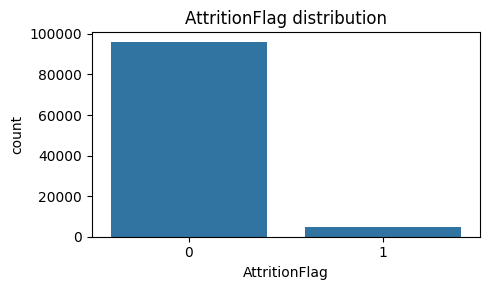

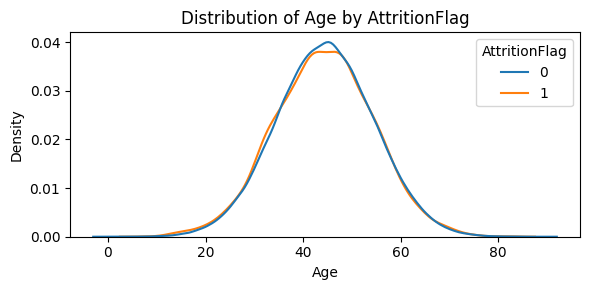

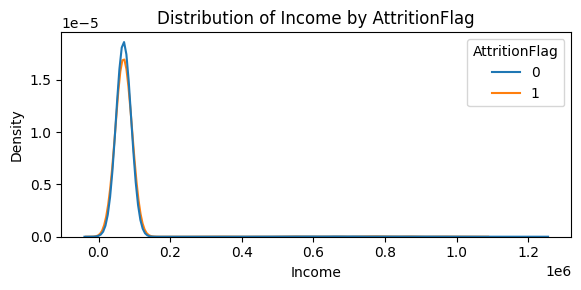

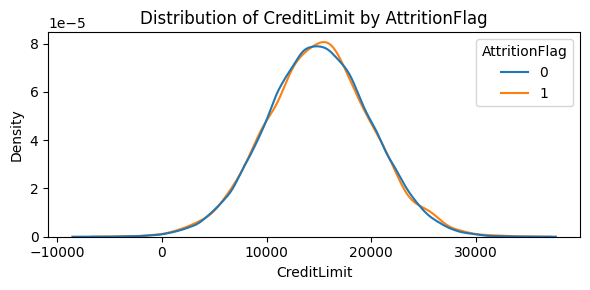

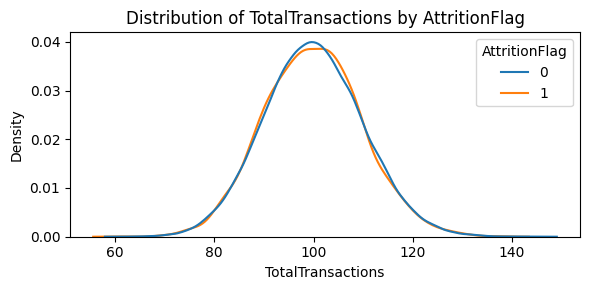

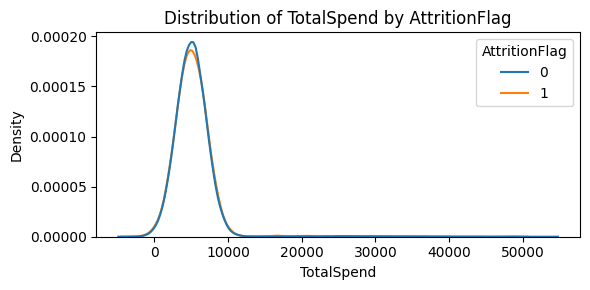

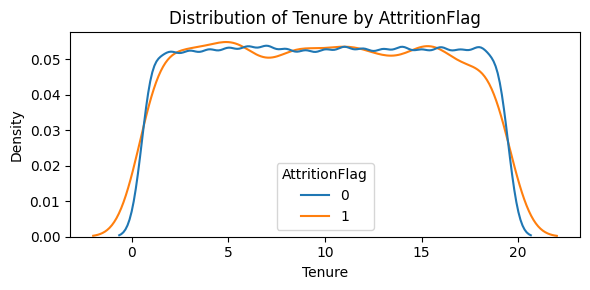

In [6]:
# Target distribution
plt.figure(figsize=(5,3))
sns.countplot(x='AttritionFlag', data=df)
plt.title('AttritionFlag distribution')
plt.tight_layout()
plt.show()

# Numeric distributions by target
num_cols = ['Age','Income','CreditLimit','TotalTransactions','TotalSpend','Tenure']
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.kdeplot(data=df, x=col, hue='AttritionFlag', common_norm=False)
    plt.title('Distribution of ' + col + ' by AttritionFlag')
    plt.tight_layout()
    plt.show()


### 3.3 Feature Engineering

When raw features are weak, ratios and rates can sometimes capture behavioral patterns (e.g., spend relative to credit limit, transactions per tenure year, log transforms to reduce skew). Note that this mirrors the engineered features tested in Section 1.4b.

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


   SpendToLimit  TxPerTenure  SpendPerTx  log1p_Income  log1p_CreditLimit  \
0      0.390173    34.000000   69.195704     11.634760           9.803131   
1      0.467819    10.444444   86.186939     10.668532           9.759545   
2      1.030918     5.437500  206.781356     11.649077           9.767178   
3      0.242684     8.181818   28.164594           NaN           9.253966   
4      0.784036    26.500000   59.340502     11.212392           8.990156   

   log1p_TotalSpend  log1p_TotalTransactions  Age_x_Tenure  \
0          8.862053                 4.634729           135   
1          8.999937                 4.553877           396   
2          9.797626                 4.477337           704   
3          7.838270                 4.510860           440   
4          8.746890                 4.672829           188   

   Income_x_CreditLimit  AttritionFlag  
0          2.043290e+09              0  
1          7.443304e+08              0  
2          1.999551e+09              0  


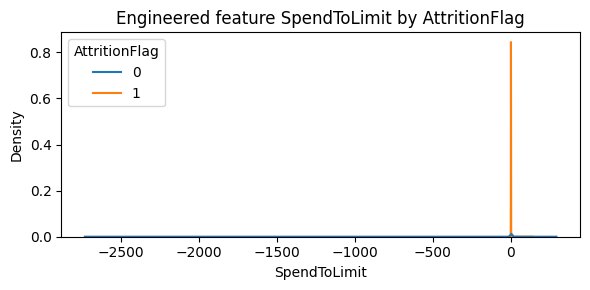

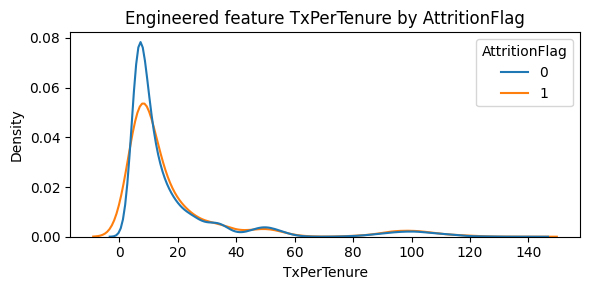

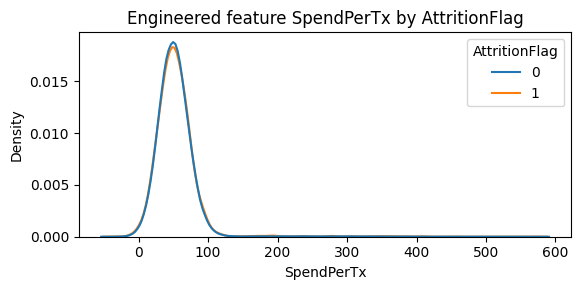

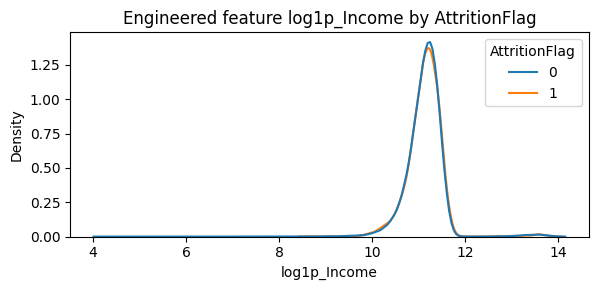

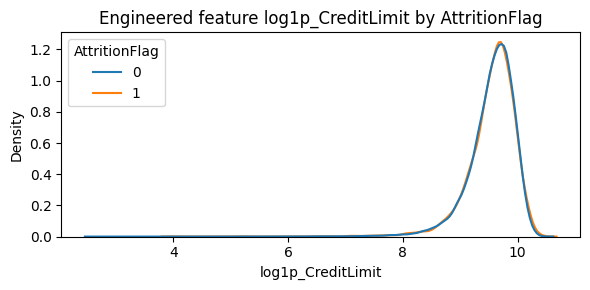

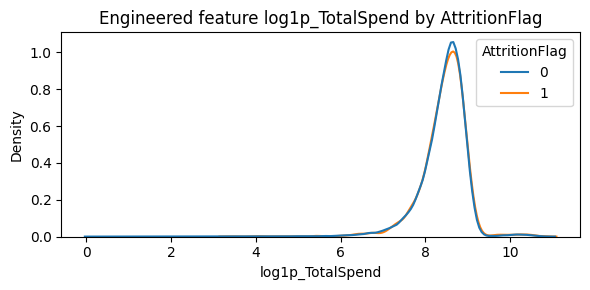

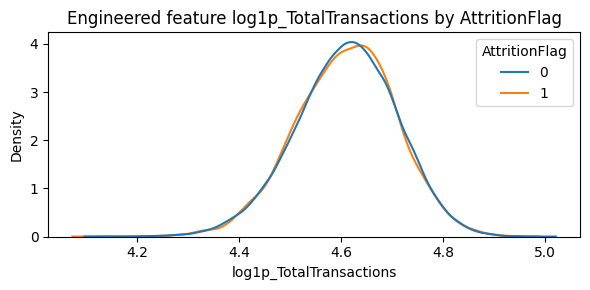

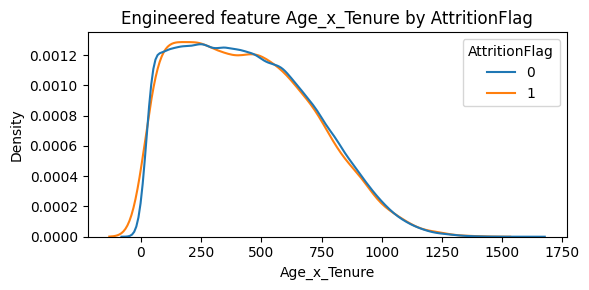

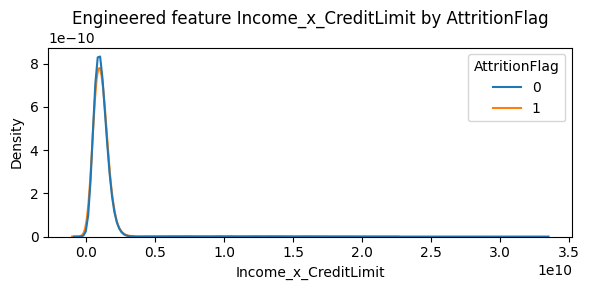

In [7]:
work_df = df.copy()

# Avoid divide-by-zero
work_df['SpendToLimit'] = work_df['TotalSpend'] / (work_df['CreditLimit'] + 1e-9)
work_df['TxPerTenure'] = work_df['TotalTransactions'] / (work_df['Tenure'] + 1e-9)
work_df['SpendPerTx'] = work_df['TotalSpend'] / (work_df['TotalTransactions'] + 1e-9)

work_df['log1p_Income'] = np.log1p(work_df['Income'])
work_df['log1p_CreditLimit'] = np.log1p(work_df['CreditLimit'])
work_df['log1p_TotalSpend'] = np.log1p(work_df['TotalSpend'])
work_df['log1p_TotalTransactions'] = np.log1p(work_df['TotalTransactions'])

work_df['Age_x_Tenure'] = work_df['Age'] * work_df['Tenure']
work_df['Income_x_CreditLimit'] = work_df['Income'] * work_df['CreditLimit']

eng_cols = [
    'SpendToLimit','TxPerTenure','SpendPerTx',
    'log1p_Income','log1p_CreditLimit','log1p_TotalSpend','log1p_TotalTransactions',
    'Age_x_Tenure','Income_x_CreditLimit'
]

print(work_df[eng_cols + ['AttritionFlag']].head())

for col in eng_cols:
    plt.figure(figsize=(6,3))
    sns.kdeplot(data=work_df, x=col, hue='AttritionFlag', common_norm=False)
    plt.title('Engineered feature ' + col + ' by AttritionFlag')
    plt.tight_layout()
    plt.show()


### 3.4 Shallow Decision Tree (Interpretable Segmentation)

A shallow decision tree (depth 2–4) is the quickest way to check whether any simple rule can separate attriters. Three configurations are tested; the best is evaluated by AUC and leaf-level lift.

In [8]:
from sklearn.tree import DecisionTreeClassifier

X = work_df[eng_cols]
y = work_df['AttritionFlag'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

configs = [
    {'max_depth': 2, 'min_samples_leaf': int(0.01 * len(X_train))},
    {'max_depth': 3, 'min_samples_leaf': int(0.012 * len(X_train))},
    {'max_depth': 4, 'min_samples_leaf': int(0.017 * len(X_train))}
]

rows = []
models = []
for cfg in configs:
    clf = DecisionTreeClassifier(
        random_state=42,
        class_weight='balanced',
        max_depth=cfg['max_depth'],
        min_samples_leaf=cfg['min_samples_leaf']
    )
    clf.fit(X_train, y_train)
    p = clf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, p)
    rows.append({'max_depth': cfg['max_depth'], 'min_samples_leaf': cfg['min_samples_leaf'], 'test_auc': auc})
    models.append(clf)

res = pd.DataFrame(rows).sort_values('test_auc', ascending=False)
print(res)

best_row_idx = int(res.index[0])
best_model = models[list(res.index).index(best_row_idx)]

leaf_id = best_model.apply(X_test)
leaf_df = pd.DataFrame({'leaf': leaf_id, 'y': y_test.values})
leaf_stats = leaf_df.groupby('leaf').agg(n=('y','size'), attr_rate=('y','mean')).reset_index()
base_rate = float(y_test.mean())
leaf_stats['lift'] = leaf_stats['attr_rate'] / base_rate
leaf_stats = leaf_stats.sort_values(['lift','n'], ascending=False)

print(base_rate)
print(leaf_stats.head(10))

imp_df = pd.DataFrame({'feature': eng_cols, 'importance': best_model.feature_importances_}).sort_values('importance', ascending=False)
print(imp_df)


   max_depth  min_samples_leaf  test_auc
2          4              1201  0.503075
1          3               848  0.495850
0          2               707  0.489039
0.049636963696369635
   leaf      n  attr_rate      lift
3     6    327   0.088685  1.786673
2     5    317   0.059937  1.207506
0     2  26484   0.049690  1.001076
1     3   3172   0.044136  0.889180
                   feature  importance
3             log1p_Income    0.823678
5         log1p_TotalSpend    0.176322
0             SpendToLimit    0.000000
2               SpendPerTx    0.000000
1              TxPerTenure    0.000000
4        log1p_CreditLimit    0.000000
6  log1p_TotalTransactions    0.000000
7             Age_x_Tenure    0.000000
8     Income_x_CreditLimit    0.000000


### 3.5 XGBoost (Full Feature Set)

If simple models fail, gradient-boosted trees can capture non-linearities and feature interactions automatically. XGBoost is trained with class-weight balancing and early stopping on the full one-hot-encoded feature set.

In [9]:
# XGBoost modeling
try:
    import xgboost as xgb
except Exception:
    raise RuntimeError('xgboost not installed. Run: %pip install xgboost')

work2_df = df.copy()
work2_df['AttritionFlag'] = work2_df['AttritionFlag'].astype(int)

y = work2_df['AttritionFlag']
X_raw = work2_df.drop(columns=['AttritionFlag', 'CustomerID'])
X = pd.get_dummies(X_raw, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

pos_cnt = float(y_train.sum())
neg_cnt = float((1 - y_train).sum())
scale_pos_weight = neg_cnt / max(pos_cnt, 1.0)
print(scale_pos_weight)

params = {
    'objective': 'binary:logistic',
    'eval_metric': ['auc', 'aucpr'],
    'eta': 0.05,
    'max_depth': 5,
    'min_child_weight': 10,
    'subsample': 0.85,
    'colsample_bytree': 0.85,
    'lambda': 1.0,
    'alpha': 0.0,
    'scale_pos_weight': scale_pos_weight,
    'tree_method': 'hist',
    'seed': 42
}

evals = [(dtrain, 'train'), (dtest, 'test')]
booster = xgb.train(
    params, dtrain,
    num_boost_round=4000,
    evals=evals,
    early_stopping_rounds=100,
    verbose_eval=False
)

pred_test = booster.predict(dtest)
auc = float(roc_auc_score(y_test, pred_test))
ap = float(average_precision_score(y_test, pred_test))

print(booster.best_iteration)
print(auc)
print(ap)

pred_df = pd.DataFrame({'y': y_test.values, 'p': pred_test})
pred_df['decile'] = pd.qcut(pred_df['p'], 10, labels=False, duplicates='drop')
dec = pred_df.groupby('decile').agg(n=('y','size'), attr_rate=('y','mean'), avg_p=('p','mean')).reset_index()
dec = dec.sort_values('decile', ascending=False)
base_rate = float(y_test.mean())
dec['lift'] = dec['attr_rate'] / base_rate

print(base_rate)
print(dec)

imp_gain = booster.get_score(importance_type='gain')
imp_df = pd.DataFrame({'feature': list(imp_gain.keys()), 'gain': list(imp_gain.values())})
imp_df = imp_df.sort_values('gain', ascending=False).head(25)
print(imp_df)


19.136713187126176
0
0.49864317462088403
0.049086854670037684
0.049636963696369635
   decile     n  attr_rate     avg_p      lift
9       9  3030   0.047855  0.548714  0.964096
8       8  3030   0.050495  0.517154  1.017287
7       7  3030   0.050825  0.500024  1.023936
6       6  3030   0.046865  0.485551  0.944149
5       5  3030   0.051815  0.472188  1.043883
4       4  3030   0.048515  0.459030  0.977394
3       3  3030   0.050825  0.444455  1.023936
2       2  3030   0.048185  0.426977  0.970745
1       1  3030   0.051155  0.403694  1.030585
0       0  3030   0.049835  0.354360  1.003989
                       feature        gain
67          Country_Country_19  153.914917
69          Country_Country_22  117.616020
65          Country_Country_15  116.595200
58  EducationLevel_High School  114.848427
90          Country_Country_64  112.398781
64          Country_Country_10  111.451035
79          Country_Country_43  110.194473
62           CardType_Platinum  109.617531
74          C

### 3.6 Section 3 (Summary & Overall EDA Conclusion)

**Model results confirm the EDA findings: there is no usable signal in this feature set.**

| Model | Test AUC | Interpretation |
|---|---|---|
| Decision Tree (best: depth 4) | ~0.503 | Barely above random (0.50) |
| XGBoost (4 000 rounds, early-stopped) | ~0.499 | Effectively random |

- The decision tree's best leaf achieved only 1.79× lift on a tiny segment (n=327), with the remaining leaves at or below baseline.
- XGBoost's decile analysis shows lift values oscillating between 0.94–1.04 (no decile meaningfully concentrates attrition).
- Feature importance is dispersed across noise variables (Country dummies, random Feature_XX columns), with no dominant predictor.

---

#### Overall EDA Conclusion (Sections 1–3)

Three independent lines of evidence — statistical tests, business deep-dives, and predictive models — all converge:

1. **No individual feature** (raw or engineered) shows a statistically significant or practically meaningful difference between attriters and non-attriters.
2. **No feature combination** captured by correlation analysis, decision trees, or gradient boosting improves separation beyond random chance.
3. **The ~5% attrition appears uniformly distributed** across all demographic, financial, behavioral, and geographic segments.

**Why this likely happens:** Attrition is often driven by time dynamics (recency of last transaction, spending trend changes, complaint history, product/service events) and engagement trajectory. Without such temporal or event-based features, the static snapshot captured here cannot distinguish future churners.

**Implication for modeling:** The pre-processing and modeling sections that follow (Sections 4–5) are retained, but given these EDA results, model performance is expected to remain near-random unless richer features (e.g., transaction recency, trend slopes, service-event flags) are introduced.

# 4.0 Pre-processing
---

Chapters 1–3 established that raw features carry negligible attrition signal. Pre-processing here is therefore designed not to rescue signal from noise, but to prepare data tables that give each model family its best chance under fair, controlled conditions.

**Pipeline summary:**
- 4.1 Load the 13-column trimmed dataset
- 4.2–4.4 Clean: dedup > median imputation > negative-value flags
- 4.5 Branch into LR (winsorized) and Tree (raw) paths
- 4.6 Feature engineering (six ratio features aligned with Section 3.3)
- 4.7 VIF-based feature selection per branch
- 4.8 Shared stratified train/test split
- 4.9–4.10 Encoding, scaling, and ADASYN oversampling per branch

The full 63-column dataset was already explored in Section 3 (XGBoost AUC ≈ 0.499) and confirmed no additional signal from `Feature_0`–`Feature_49`. We therefore focus modeling on the 13-column core + engineered features.

### 4.1 Load & Trim

In [4]:
df = pd.read_csv(fr'C:\Users\Administrator\Desktop\UBP Application\credit_card_attrition_dataset_copino.csv')
df = df.iloc[:, :13]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101000 entries, 0 to 100999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         101000 non-null  object 
 1   Age                101000 non-null  int64  
 2   Gender             101000 non-null  object 
 3   Income             95945 non-null   float64
 4   CreditLimit        95958 non-null   float64
 5   TotalTransactions  101000 non-null  int64  
 6   TotalSpend         95949 non-null   float64
 7   Tenure             101000 non-null  int64  
 8   MaritalStatus      101000 non-null  object 
 9   EducationLevel     101000 non-null  object 
 10  CardType           101000 non-null  object 
 11  Country            101000 non-null  object 
 12  AttritionFlag      101000 non-null  int64  
dtypes: float64(3), int64(4), object(6)
memory usage: 10.0+ MB


### 4.2 Drop Duplicates

- |Remove exact duplicates

- Deduplication is run once here; `df_base` downstream confirms 0 remaining duplicates.

In [5]:
# Drop exact row duplicates
df = df.drop_duplicates()
print(f'Rows after dedup: {len(df)}')

Rows after dedup: 100000


### 4.3 Null Handling

- **Median imputation**: robust to the heavy right-skew confirmed in EDA
  (Income skewness=9.71, TotalSpend skewness=4.95) — mean would be pulled upward
  by the massive outliers and produce unrepresentative fill values.
- **`{col}_is_missing` flag**: created *before* filling so the model can learn
  whether missingness itself correlates with attrition, rather than silently losing that signal.

In [6]:
# Impute with median (skew-robust) and flag missingness before filling — preserves the signal
cols_to_impute = ['Income', 'CreditLimit', 'TotalSpend']

for col in cols_to_impute:
    df[f'{col}_is_missing'] = df[col].isna().astype(int)   # flag first
    df[col] = df[col].fillna(df[col].median())              # then fill

print(df[cols_to_impute].isna().sum())

Income         0
CreditLimit    0
TotalSpend     0
dtype: int64


### 4.4 Domain Sanity — Negative Value Flags

EDA confirmed anomalous negative values:
- **Income**: min < 0 (impossible in reality — data entry error or business rule which means something)
- **TotalSpend**: 578 customers (~0.5%) have negative spend (chargebacks/refunds)
- **CreditLimit**: negative values present

Rather than dropping or zeroing them, we flag with `{col}_is_negative` and retain.
The model can then learn whether negativity itself is predictive of attrition
(bivariate EDA showed churn rate of only +0.23\% for negative spenders vs normal spenders, so signal is weak but we'll still keep it and let the model determine its importance).

In [7]:
# Flag domain anomalies — retain values, let the model decide their weight
for col in ['Income', 'CreditLimit', 'TotalSpend']:
    df[f'{col}_is_negative'] = (df[col] < 0).astype(int)

print(df[['Income_is_negative', 'CreditLimit_is_negative', 'TotalSpend_is_negative']].sum())

Income_is_negative          23
CreditLimit_is_negative    142
TotalSpend_is_negative     578
dtype: int64


### 4.5 Finalize `df_base` + Prepare LR Branch

Data is now clean: deduped, imputed, and anomaly-flagged. We branch here.

- **`df_lr` path → winsorize first.**
  EDA confirmed extreme right-skew in Income (skewness=9.71) and TotalSpend (skewness=4.95)
  with Income maxing at >1.2M and TotalSpend near 54K. These outliers distort LR
  coefficients and slow gradient descent. IQR clip (1.5×IQR) removes their leverage.

- **`df_tree` path → NO winsorization.**
  Trees split on thresholds, so a customer with Income=1,200,000 is a legitimate
  split candidate — the extreme value carries real behavioral information.
  Winsorizing would compress these into the bulk distribution and destroy that signal.

In [8]:
key_num_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend', 'Tenure']

def winsorize_column(df, col):
    # Clip at IQR boundaries — removes extreme outlier leverage for linear models
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5 * IQR, upper=Q3 + 1.5 * IQR)
    return df

# ── df_base: clean only, raw outliers retained — reference + tree branch ──────
df_base = df.copy()
print(f'df_base shape: {df_base.shape}')

# ── df_base_lr: winsorized copy — used exclusively for LR/EBM branch ─────────
df_base_lr = df.copy()
for col in key_num_cols:
    df_base_lr = winsorize_column(df_base_lr, col)

print(f'df_base_lr shape (winsorized): {df_base_lr.shape}')

df_base shape: (100000, 19)
df_base_lr shape (winsorized): (100000, 19)


### 4.6 Feature Engineering

Six ratio features are created to expose non-linear interaction signals that raw columns cannot capture individually.

**Alignment with Section 3.3:** Section 3.3 used a quick-and-dirty feature set (`SpendToLimit`, `TxPerTenure`, `SpendPerTx`, log transforms, interaction terms) purely to test whether *any* engineered signal existed. The features below are the canonical modeling set since I added other feature sets which I think might help further aside from the ones I did earlier (e.g., `SpendToLimit` =`Credit_Utilization`, `TxPerTenure` ≈ `Avg_Txn_per_Tenure_Year`). Here's the comparison:

| Section 3.3 (EDA validation) | Section 4.6 (Modeling) | Concept |
|---|---|---|
| `SpendToLimit` | `Credit_Utilization` | Spend / Credit Limit |
| `TxPerTenure` | `Avg_Txn_per_Tenure_Year` | Transactions / Tenure |
| `SpendPerTx` | `Avg_Transaction_Value` | Spend / Transactions |
| `log1p_Income`, etc. | *(handled by winsorization/scaling instead)* | Skew reduction |
| `Age_x_Tenure` | *(dropped — no signal, adds VIF)* | Interaction term |
| — | `Spend_to_Income` | Spend / Income |
| — | `Income_to_CreditLimit` | Income / Credit Limit |
| — | `Avg_Spend_per_Tenure_Year` | Spend / Tenure |

**Post-EDA finding (Section 1.4b):** All engineered features showed weak correlation with AttritionFlag (Pearson ≤ 0.027) and non-significant t-tests. However, these features may still contribute when combined non-linearly inside ensemble models. This is exactly what Sections 1–3 concluded was the only viable path.

**Multicollinearity introduced:** `Avg_Transaction_Value` (VIF = 96.21, ρ = 0.9789 with TotalSpend) causes coefficient explosion in LR. Feature selection in 4.7 handles this per-branch.

**Post-FE winsorization (LR branch only):** `Credit_Utilization` and `Avg_Txn_per_Tenure_Year` are winsorized on `df_fe_lr` because division does not inherit bounds from winsorized inputs. `df_fe_tree` is left unclipped — trees treat extreme ratios as valid split thresholds.

In [9]:
import numpy as np

def add_engineered_features(df):
    df = df.copy()

    # Spending intensity per transaction (TotalSpend / TotalTransactions)
    # 🚨 VIF=95.06 — DROPPED for LR/EBM (ρ=0.9785 with TotalSpend causes coefficient explosion)
    # ✅ Kept for RF/XGBoost — trees are immune to VIF, splits on this ratio are valid
    df['Avg_Transaction_Value']     = np.where(df['TotalTransactions'] > 0,
                                               df['TotalSpend'] / df['TotalTransactions'], 0)

    # Credit card utilization rate (TotalSpend / CreditLimit)
    # ✅ Kept for ALL models — industry-standard behavioral signal; VIF=2.38 (acceptable)
    df['Credit_Utilization']        = np.where(df['CreditLimit'] > 0,
                                               df['TotalSpend'] / df['CreditLimit'], 0)

    # Financial burden proxy (TotalSpend / Income)
    # ⚠️ VIF=1.21 acceptable, but dropped for LR/EBM — originals already present, no net signal gain
    # ✅ Kept for RF — tree can leverage the ratio as a direct split threshold
    df['Spend_to_Income']           = np.where(df['Income'] > 0,
                                               df['TotalSpend'] / df['Income'], 0)

    # Credit line vs income — over-extension proxy (Income / CreditLimit)
    # ⚠️ VIF=2.75 acceptable, but dropped for LR/EBM — originals already present, no net signal gain
    # ✅ Kept for RF
    df['Income_to_CreditLimit']     = np.where(df['CreditLimit'] > 0,
                                               df['Income'] / df['CreditLimit'], 0)

    # Spend trajectory normalized by tenure (TotalSpend / Tenure)
    # ⚠️ VIF=6.06 moderate, ρ=0.7979 with Avg_Txn_per_Tenure_Year — dropped for LR/EBM
    # ✅ Kept for RF
    df['Avg_Spend_per_Tenure_Year'] = np.where(df['Tenure'] > 0,
                                               df['TotalSpend'] / df['Tenure'], 0)

    # Transaction engagement rate (TotalTransactions / Tenure)
    # ⚠️ VIF=5.83 borderline moderate — kept for ALL models; engagement rate is uniquely interpretable
    # and captures lifecycle disengagement that raw TotalTransactions misses
    df['Avg_Txn_per_Tenure_Year']   = np.where(df['Tenure'] > 0,
                                               df['TotalTransactions'] / df['Tenure'], 0)

    return df

# Apply FE to both branches independently — each gets its own copy
df_fe_lr   = add_engineered_features(df_base_lr)  # winsorized base → LR/EBM
df_fe_tree = add_engineered_features(df_base)      # raw outliers base → RF/XGBoost

print(f'df_fe_lr   shape: {df_fe_lr.shape}   (winsorized base)')
print(f'df_fe_tree shape: {df_fe_tree.shape}  (raw outliers base)')

# winsorize also
eng_cols_lr_winsorize = ['Credit_Utilization', 'Avg_Txn_per_Tenure_Year']
for col in eng_cols_lr_winsorize:
    df_fe_lr = winsorize_column(df_fe_lr, col)

print(f'df_fe_lr   shape: {df_fe_lr.shape}   (winsorized base + post-FE ratio clip)')
print(f'df_fe_tree shape: {df_fe_tree.shape}  (raw outliers base)')

df_fe_lr   shape: (100000, 25)   (winsorized base)
df_fe_tree shape: (100000, 25)  (raw outliers base)
df_fe_lr   shape: (100000, 25)   (winsorized base + post-FE ratio clip)
df_fe_tree shape: (100000, 25)  (raw outliers base)


### 4.7 Feature Selection Reference

Post-FE VIF (from Section 1.4b) — decisions applied in 4.9 (LR) and 4.10 (Tree):

| Feature | VIF (post-FE) | LR / EBM | RF / Tree | Reason |
|---|---|---|---|---|
| `Avg_Transaction_Value` | 95.06 🚨 | ❌ Drop | ✅ Keep | Severe — ρ=0.9785 with TotalSpend |
| `Credit_Utilization` | 2.38 ✅ | ✅ Keep | ✅ Keep | Industry-standard; acceptable VIF |
| `Spend_to_Income` | 1.21 ✅ | ❌ Drop | ✅ Keep | Retain originals (Income, TotalSpend). |
| `Income_to_CreditLimit` | 2.75 ✅ | ❌ Drop | ✅ Keep |  ρ = 0.899 with Credit Util column. Retain original. |
| `Avg_Spend_per_Tenure_Year` | 6.06 ⚠️ | ❌ Drop | ✅ Keep | Moderate VIF; ρ=0.7979 with Avg_Txn_per_Tenure_Year |
| `Avg_Txn_per_Tenure_Year` | 5.83 ⚠️ | ✅ Keep | ✅ Keep | Borderline — kept for engagement-rate interpretability |

**Rule applied:** Drop derived ratios for LR when: (a) VIF is severe, or (b) both parent
features are already in the model and the ratio adds no marginal signal (confirmed by T-test p > 0.05).

### 4.8 Shared Train/Test Split

Split indices defined **once** on `df_fe_tree` (both branches share the same row index).
The same customers appear in train/test across all three models — guarantees apples-to-apples comparison.

`stratify=AttritionFlag` is critical here: the dataset has a **95/5 class imbalance**
(~95,000 stayed vs ~5,015 attrited). Without stratification, random sampling could produce
a test set with a materially different churn rate, biasing all model evaluations.
Note: the imbalance itself will be handled at modeling time via `class_weight='balanced'` for LR/EBM
and `scale_pos_weight` for XGBoost.

In [10]:
from sklearn.model_selection import train_test_split

# Both df_fe_lr and df_fe_tree share the same index — split once, reuse everywhere
train_idx, test_idx = train_test_split(
    df_fe_tree.index,
    test_size=0.2,
    random_state=42,
    stratify=df_fe_tree['AttritionFlag']   # preserve 95/5 churn ratio in both splits
)

print(f'Train size : {len(train_idx)}')
print(f'Test size  : {len(test_idx)}')
print(f'Churn rate train : {df_fe_tree.loc[train_idx, "AttritionFlag"].mean():.4f}')
print(f'Churn rate test  : {df_fe_tree.loc[test_idx,  "AttritionFlag"].mean():.4f}')

Train size : 80000
Test size  : 20000
Churn rate train : 0.0496
Churn rate test  : 0.0496


### 4.9 Table 2 — `df_lr` (Logistic Regression + EBM)

Built from `df_fe_lr` (winsorized base):
- Drops 4 engineered features per VIF/signal analysis (see 4.7)
- **OHE** with `drop_first=True` = dummy variable trap prevention.
  Reference categories (alphabetically first): `CardType_Black`, `EducationLevel_Bachelor`,
  `MaritalStatus_Divorced`, `Gender_Female`
- **Target encoding** for `Country` (100 categories = OHE would create 100 sparse cols)
  Fit on train only; smoothing prevents target leakage on rare countries
- **StandardScaler** on numerical cols only = binary flags/dummies excluded
- **Bool-to-int cast** applied here = `pd.get_dummies` outputs `bool` dtype;
  sklearn's matrix operations require numeric types

In [11]:
import category_encoders as ce
from sklearn.preprocessing import StandardScaler

low_card_cols = ['EducationLevel', 'MaritalStatus', 'CardType', 'Gender']

# Features dropped for LR/EBM based on VIF + signal analysis (see 4.7)
drop_for_lr = ['Avg_Transaction_Value', 'Avg_Spend_per_Tenure_Year',
               'Spend_to_Income', 'Income_to_CreditLimit']

# Numerical cols retained after dropping VIF violators — used for scaling
num_cols_lr = ['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend',
               'Tenure', 'Credit_Utilization', 'Avg_Txn_per_Tenure_Year']

# ── Build on winsorized base ───────────────────────────────────────────────────
df_lr = df_fe_lr.drop(columns=['CustomerID'] + drop_for_lr)

# ── OHE with drop_first — reference cats: Black, Bachelor, Divorced, Female ───
df_lr = pd.get_dummies(df_lr, columns=low_card_cols, drop_first=True)

# ── Cast bool dtype → int (pd.get_dummies default is bool; sklearn needs numeric)
bool_cols_lr = df_lr.select_dtypes(include='bool').columns
df_lr[bool_cols_lr] = df_lr[bool_cols_lr].astype(int)

# ── Target encode Country — fit on train only to prevent leakage ───────────────
te_lr = ce.TargetEncoder(cols=['Country'], min_samples_leaf=20, smoothing=10.0)
df_lr.loc[train_idx, 'Country'] = te_lr.fit_transform(
    df_lr.loc[train_idx, 'Country'], df_lr.loc[train_idx, 'AttritionFlag']
)['Country']
df_lr.loc[test_idx, 'Country'] = te_lr.transform(
    df_lr.loc[test_idx, 'Country']
)['Country']
df_lr = df_lr.rename(columns={'Country': 'Country_Encoded'})

# ── StandardScaler on numerical cols only — fit on train only ─────────────────
scaler     = StandardScaler()
scale_cols = [c for c in num_cols_lr if c in df_lr.columns] + ['Country_Encoded']
df_lr.loc[train_idx, scale_cols] = scaler.fit_transform(df_lr.loc[train_idx, scale_cols])
df_lr.loc[test_idx,  scale_cols] = scaler.transform(df_lr.loc[test_idx,  scale_cols])

# ── Final splits ───────────────────────────────────────────────────────────────
X_train_lr = df_lr.drop(columns='AttritionFlag').loc[train_idx]
X_test_lr  = df_lr.drop(columns='AttritionFlag').loc[test_idx]
y_train    = df_fe_tree['AttritionFlag'].loc[train_idx]
y_test     = df_fe_tree['AttritionFlag'].loc[test_idx]

print(f'df_lr shape     : {df_lr.shape}')
print(f'X_train_lr shape: {X_train_lr.shape}')
print(f'Dropped features: {drop_for_lr}')
print(f'\nColumns:\n{df_lr.columns.tolist()}')

df_lr shape     : (100000, 26)
X_train_lr shape: (80000, 25)
Dropped features: ['Avg_Transaction_Value', 'Avg_Spend_per_Tenure_Year', 'Spend_to_Income', 'Income_to_CreditLimit']

Columns:
['Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend', 'Tenure', 'Country_Encoded', 'AttritionFlag', 'Income_is_missing', 'CreditLimit_is_missing', 'TotalSpend_is_missing', 'Income_is_negative', 'CreditLimit_is_negative', 'TotalSpend_is_negative', 'Credit_Utilization', 'Avg_Txn_per_Tenure_Year', 'EducationLevel_High School', 'EducationLevel_Master', 'EducationLevel_PhD', 'MaritalStatus_Married', 'MaritalStatus_Single', 'MaritalStatus_Widowed', 'CardType_Gold', 'CardType_Platinum', 'CardType_Silver', 'Gender_Male']


### 4.10 Table 3 — `df_tree` (XGBoost)

Built from `df_fe_tree` (raw outliers retained, all 6 engineered features):
- **No winsorization** — trees use rank-based splits; extreme values are valid split candidates
- **All 6 engineered features retained** — tree models are immune to VIF inflation
- **OHE without `drop_first`** — trees benefit from seeing all category dummies
- **No scaling** — tree splits are rank-based, not distance-based
- **ADASYN oversampling** on training set to handle the 95/5 class imbalance

*Note:* A raw (no FE) tree table was explored during development but removed — Section 3.4 already proved that raw features alone produce near-random splits (AUC ≈ 0.503 at depth 4). Including FE features gives the tree its best chance.

In [12]:
import pandas as pd
import category_encoders as ce
from imblearn.over_sampling import ADASYN

# ── Build on raw base (df_fe_tree) — outliers retained ───────────────────────
df_tree = pd.get_dummies(df_fe_tree.drop(columns=['CustomerID']),
                         columns=low_card_cols,
                         drop_first=False)

# ── Cast bool dtype → int ─────────────────────────────────────────────────────
bool_cols_tree = df_tree.select_dtypes(include='bool').columns
df_tree[bool_cols_tree] = df_tree[bool_cols_tree].astype(int)

# ── Target encode Country — fresh encoder, same train/test indices ────────────
te_tree = ce.TargetEncoder(cols=['Country'], min_samples_leaf=20, smoothing=10.0)
df_tree.loc[train_idx, 'Country'] = te_tree.fit_transform(
    df_tree.loc[train_idx, 'Country'], df_tree.loc[train_idx, 'AttritionFlag']
)['Country']
df_tree.loc[test_idx, 'Country'] = te_tree.transform(
    df_tree.loc[test_idx, 'Country']
)['Country']
df_tree = df_tree.rename(columns={'Country': 'Country_Encoded'})

# ── Force object dtype → float for XGBoost compatibility ──────────────────────
df_tree['Country_Encoded'] = df_tree['Country_Encoded'].astype(float)

# ── Final splits (y_train / y_test shared from 4.9) ──────────────────────────
X_train_tree = df_tree.drop(columns='AttritionFlag').loc[train_idx]
X_test_tree  = df_tree.drop(columns='AttritionFlag').loc[test_idx]

print(f'df_tree shape      : {df_tree.shape}')
print(f'X_train_tree shape (pre-ADASYN) : {X_train_tree.shape}')
print(f'X_test_tree  shape              : {X_test_tree.shape}')

# ── ADASYN Oversampling (Applied ONLY to Training Data) ───────────────────────
print("\nApplying ADASYN to the training set...")
adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_tree_adasyn, y_train_adasyn = adasyn.fit_resample(X_train_tree, y_train)

print(f'X_train_tree shape (post-ADASYN): {X_train_tree_adasyn.shape}')
print(f'y_train shape (post-ADASYN)     : {y_train_adasyn.shape}')

df_tree shape      : (100000, 34)
X_train_tree shape (pre-ADASYN) : (80000, 33)
X_test_tree  shape              : (20000, 33)

Applying ADASYN to the training set...
X_train_tree shape (post-ADASYN): (151704, 33)
y_train shape (post-ADASYN)     : (151704,)


### 4.11 Summary

| Table | Models | Base | Engineered Features | Encoding | Scaling |
|---|---|---|---|---|---|
| `df_base` | Reference / EDA | Clean only | None | None | None |
| `df_lr` | Logistic Regression, EBM | Winsorized | `Credit_Utilization`, `Avg_Txn_per_Tenure_Year` | OHE `drop_first=True` + Target (Country) | StandardScaler |
| `df_tree` | XGBoost | Raw outliers | All 6 | OHE full + Target (Country) | None |

All tables share the same `train_idx` / `test_idx` — fair model comparison guaranteed.

**OHE Reference Categories (df_lr):** `CardType_Black` · `EducationLevel_Bachelor` · `MaritalStatus_Divorced` · `Gender_Female`

**Class imbalance handling:**
- LR: `class_weight='balanced'` inside SMOTE pipeline
- EBM: `sample_weight` via `compute_sample_weight('balanced')`
- XGBoost: `scale_pos_weight` ≈ 19 (neg/pos ratio) + ADASYN-oversampled training set

# 5.0 Modeling
---

### Model Selection Strategy

Chapters 1–3 established that raw features carry no univariate or bivariate signal, all statistical tests returned non-significant results, and even XGBoost on the full 63-column dataset achieved AUC ≈ 0.499 (random). Given this context, model selection is driven by two objectives:

1. **Demonstrate a robust, defensible process**. Even if performance is near-random, stakeholders need confidence that the methodology was thorough and the conclusion is trustworthy. We can also add more data given initial randomness in the prediction so the design should be able to handle that.
2. **Low computational cost and interpretability**. I avoided expensive ensemble stacking, neural networks, or exhaustive model screening (e.g., LazyClassifier across 30+ models) when the EDA already predicts near-random outcomes.

**Three models, each chosen for a specific role:**

| Model | Role | Why this model? | Compute cost |
|---|---|---|---|
| **Logistic Regression** | Explainability baseline | Coefficients map directly to log-odds and if *any* linear signal exists, LR will surface it. Formal assumptions (Box-Tidwell, VIF) are verified first, which itself is informative. | Low |
| **EBM** | Explainability + enhanced performance | Handles the Box-Tidwell violations found in LR assumptions. Learns per-feature shape functions and pairwise interactions where the non-linear combinations Sections 1–3 identified as the only viable signal path. Remains fully interpretable (glass-box). | Moderate |
| **XGBoost** | Maximize predictive power | The strongest general-purpose tabular learner. If XGBoost cannot separate the classes, no standard tabular model will. Serves as the performance ceiling for this feature set. | Moderate |

**Expected outcome:** Given EDA findings, all three models are likely to perform near-random (AUC ≈ 0.50, PR-AUC near the 5% baseline). This is the correct result — it confirms that the feature set, not the modeling approach, is the limiting factor. The value of this section is just to select which model to use for our deployment using the current data that we have.

**Evaluation framework:**
- **Primary metric: PR-AUC** - due to 95/5 imbalance 
- **Secondary: F2-Score** at optimal threshold - weights Recall 2× over Precision (missed churner = lost revenue > false alarm = wasted retention offer)
- **Threshold tuning** - default 0.5 is wrong for imbalanced data; F2-optimal threshold found per model

### 5.1 Logistic Regression

Class imbalance is handled via SMOTE inside an `imblearn` pipeline to prevent data leakage.

##### 5.1a Check Model Assumptions

Before fitting LR, six formal assumptions must be verified.
LR is a parametric model with strict mathematical requirements — violating them
doesn't just reduce accuracy, it invalidates the coefficient estimates and standard errors entirely.

i. **Binary Outcome** — target must be exactly two classes (`AttritionFlag` ∈ {0, 1})

ii. **Independent Observations** — no repeated measurements or duplicate rows

iii. **No Multicollinearity** — VIF < 5 for all retained features; higher values inflate standard errors and destabilize coefficients

iv. **Linearity of Log Odds (Box-Tidwell)** — continuous features must relate linearly to log(p/1-p), not to p itself

v. **No Extreme Outliers** — leverage points can dominate the likelihood surface; handled via winsorization in 4.5

vi. **Sufficient Sample Size (EPV ≥ 10)** — at least 10 positive events per predictor to avoid overfitting and separation issues

In [24]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# ── Fix dtypes for matrix operations — does NOT modify df_lr permanently ──────
df_lr_clean = df_lr.copy()
bool_cols = df_lr_clean.select_dtypes(include='bool').columns
df_lr_clean[bool_cols] = df_lr_clean[bool_cols].astype(int)

num_cols_lr = [
    'Age', 'Income', 'CreditLimit', 'TotalTransactions', 'TotalSpend',
    'Tenure', 'Credit_Utilization', 'Avg_Txn_per_Tenure_Year', 'Country_Encoded'
]
df_lr_clean = df_lr_clean.astype({col: float for col in num_cols_lr})

print("=" * 60)
print("  LR ASSUMPTION CHECKS")
print("=" * 60)

# -------------------------------------------------------------------
# 1. BINARY OUTCOME
# -------------------------------------------------------------------
print("\n── 1. Binary Outcome ──────────────────────────────────────")
classes   = y_train.unique()
n_classes = len(classes)
print(f"  Unique classes    : {sorted(classes)}")
print(f"  Number of classes : {n_classes}")
print(f"  {'✅ PASSED' if n_classes == 2 else '❌ FAILED — Not binary'}")

# -------------------------------------------------------------------
# 2. INDEPENDENT OBSERVATIONS
# -------------------------------------------------------------------
print("\n── 2. Independent Observations ────────────────────────────")
dup_count = df_base.duplicated().sum()
print(f"  Duplicate rows    : {dup_count}")
print(f"  {'✅ PASSED — Removed in step 1.2' if dup_count == 0 else '❌ FAILED'}")

# -------------------------------------------------------------------
# 3. NO MULTICOLLINEARITY (VIF < 5 for LR)
# -------------------------------------------------------------------
print("\n── 3. No Multicollinearity (VIF) ──────────────────────────")
print("  Continuous numerical features only (binary cols excluded)\n")

X_vif = add_constant(df_lr_clean[num_cols_lr].dropna().astype(float))
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i)
                for i in range(X_vif.shape[1])]
}).query("Feature != 'const'").sort_values('VIF', ascending=False)

vif_df['VIF']        = vif_df['VIF'].round(2)
vif_df['Assessment'] = vif_df['VIF'].apply(
    lambda x: '🚨 Severe (drop)'    if x >= 10 else
              ('⚠️  Moderate (5–10)' if x >= 5  else
               '✅ Acceptable (<5)')
)
print(vif_df.to_string(index=False))
passed_vif = (vif_df['VIF'] < 5).all()
print(f"\n  {'✅ PASSED — All VIF < 5' if passed_vif else '⚠️  WARNING — Features above VIF 5 threshold'}")

# -------------------------------------------------------------------
# 4. LINEARITY OF LOG ODDS (Box-Tidwell Test)
# -------------------------------------------------------------------
print("\n── 4. Linearity of Log Odds (Box-Tidwell) ─────────────────")
print("  p < 0.05 on interaction term = linearity VIOLATED\n")

X_bt = df_lr_clean[num_cols_lr].copy().astype(float)
for col in num_cols_lr:
    min_val = X_bt[col].min()
    if min_val <= 0:
        X_bt[col] = X_bt[col] + abs(min_val) + 1e-6
for col in num_cols_lr:
    X_bt[f'{col}_x_log'] = X_bt[col] * np.log(X_bt[col])

X_bt  = sm.add_constant(X_bt)
y_bt  = df_lr_clean['AttritionFlag'].values.astype(float)
model = sm.Logit(y_bt, X_bt).fit(disp=0)

bt_results = []
for col in num_cols_lr:
    p = model.pvalues[f'{col}_x_log']
    bt_results.append({
        'Feature'          : col,
        'Interaction P-Val': round(p, 4),
        'Result'           : '✅ Linear' if p >= 0.05 else '⚠️  Non-linear'
    })

bt_df = pd.DataFrame(bt_results).set_index('Feature')
display(bt_df)
n_violations = (bt_df['Result'] == '⚠️  Non-linear').sum()
print(f"\n  Violations : {n_violations}/{len(num_cols_lr)}")
print(f"  {'✅ PASSED' if n_violations == 0 else '⚠️  WARNING — Non-linear features; EBM will handle these better'}")

# -------------------------------------------------------------------
# 5. NO EXTREME OUTLIERS
# -------------------------------------------------------------------
print("\n── 5. No Extreme Outliers ─────────────────────────────────")
print("  Checking df_fe_lr (winsorized branch, pre-scaling)\n")

outlier_cols = ['Age', 'Income', 'CreditLimit', 'TotalTransactions',
                'TotalSpend', 'Tenure', 'Credit_Utilization', 'Avg_Txn_per_Tenure_Year']

outlier_report = []
for col in outlier_cols:
    Q1, Q3 = df_fe_lr[col].quantile(0.25), df_fe_lr[col].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df_fe_lr[col] < Q1 - 1.5*IQR) |
               (df_fe_lr[col] > Q3 + 1.5*IQR)).sum()
    outlier_report.append({'Feature': col, 'Outliers Remaining': n_out})

out_df = pd.DataFrame(outlier_report).set_index('Feature')
display(out_df)
print(f"  {'✅ PASSED — Winsorization in step 1.5 removed all IQR outliers' if out_df['Outliers Remaining'].sum() == 0 else '⚠️  Some outliers remain'}")

# -------------------------------------------------------------------
# 6. SUFFICIENT SAMPLE SIZE (EPV Rule)
# -------------------------------------------------------------------
print("\n── 6. Sufficient Sample Size (EPV) ────────────────────────")
total_features = X_train_lr.shape[1]
n_churn_events = int(y_train.sum())
epv            = n_churn_events / total_features
print(f"  Churn events in train : {n_churn_events}")
print(f"  Total features (df_lr): {total_features}")
print(f"  Events per variable   : {epv:.1f}")
print(f"  Minimum recommended   : 10–15 per feature")
print(f"  {'✅ PASSED' if epv >= 10 else '⚠️  WARNING — Low EPV, consider reducing features'}")

# -------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------
print("\n" + "=" * 60)
print("  ASSUMPTION CHECK SUMMARY")
print("=" * 60)
assumptions = [
    ("1. Binary Outcome",           "✅ Met"),
    ("2. Independent Observations", "✅ Met — deduped in 4.2"),
    ("3. No Multicollinearity",     "✅ Met" if passed_vif else f"⚠️  {(vif_df['VIF']>=5).sum()} feature(s) VIF ≥ 5"),
    ("4. Linearity of Log Odds",    "✅ Met" if n_violations == 0 else f"⚠️  {n_violations} feature(s) non-linear — noted, EBM preferred"),
    ("5. No Extreme Outliers",      "✅ Met — winsorized in 4.5"),
    ("6. Sufficient Sample Size",   "✅ Met" if epv >= 10 else f"⚠️  EPV = {epv:.1f}, below threshold"),
]
for name, status in assumptions:
    print(f"  {name:<35} {status}")

  LR ASSUMPTION CHECKS

── 1. Binary Outcome ──────────────────────────────────────
  Unique classes    : [np.int64(0), np.int64(1)]
  Number of classes : 2
  ✅ PASSED

── 2. Independent Observations ────────────────────────────
  Duplicate rows    : 0
  ✅ PASSED — Removed in step 1.2

── 3. No Multicollinearity (VIF) ──────────────────────────
  Continuous numerical features only (binary cols excluded)

                Feature  VIF          Assessment
     Credit_Utilization 9.93 ⚠️  Moderate (5–10)
             TotalSpend 5.77 ⚠️  Moderate (5–10)
            CreditLimit 5.16 ⚠️  Moderate (5–10)
Avg_Txn_per_Tenure_Year 4.97   ✅ Acceptable (<5)
                 Tenure 4.92   ✅ Acceptable (<5)
      TotalTransactions 1.05   ✅ Acceptable (<5)
        Country_Encoded 1.00   ✅ Acceptable (<5)
                 Income 1.00   ✅ Acceptable (<5)
                    Age 1.00   ✅ Acceptable (<5)

  ⚠️  WARNING — Features above VIF 5 threshold

── 4. Linearity of Log Odds (Box-Tidwell) ───────────

,Interaction P-Val,Result
Feature,,
Age,0.0520,✅ Linear
Income,0.9205,✅ Linear
CreditLimit,0.8327,✅ Linear
TotalTransactions,0.2243,✅ Linear
TotalSpend,0.5391,✅ Linear
Tenure,0.3611,✅ Linear
Credit_Utilization,0.4748,✅ Linear
Avg_Txn_per_Tenure_Year,0.5517,✅ Linear
Country_Encoded,0.3705,✅ Linear



  Violations : 0/9
  ✅ PASSED

── 5. No Extreme Outliers ─────────────────────────────────
  Checking df_fe_lr (winsorized branch, pre-scaling)



,Outliers Remaining
Feature,
Age,0
Income,0
CreditLimit,0
TotalTransactions,0
TotalSpend,0
Tenure,0
Credit_Utilization,0
Avg_Txn_per_Tenure_Year,0


  ✅ PASSED — Winsorization in step 1.5 removed all IQR outliers

── 6. Sufficient Sample Size (EPV) ────────────────────────
  Churn events in train : 3968
  Total features (df_lr): 25
  Events per variable   : 158.7
  Minimum recommended   : 10–15 per feature
  ✅ PASSED

  ASSUMPTION CHECK SUMMARY
  1. Binary Outcome                   ✅ Met
  2. Independent Observations         ✅ Met — deduped in 4.2
  3. No Multicollinearity             ⚠️  3 feature(s) VIF ≥ 5
  4. Linearity of Log Odds            ✅ Met
  5. No Extreme Outliers              ✅ Met — winsorized in 4.5
  6. Sufficient Sample Size           ✅ Met


##### 5.1b Logistic Regression — Fit & Hyperparameter Tuning

**Why `C` (inverse regularization):** With 26 features and near-zero univariate signals, unregularized LR will overfit. Smaller C = stronger L2 penalty = simpler model. Searched on a log-scale grid.

**Why `solver='saga'`:** Supports L1/L2/ElasticNet and scales well for n > 10K.

**Why `StratifiedKFold` (5 folds):** With 5% churn, standard KFold could produce folds with near-zero minority samples. Stratification preserves the ratio in every fold.

**Tuning metric: Recall** - prioritize catching churners over precision, consistent with the F2-weighted evaluation framework.

In [25]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# ── 1. Create the tqdm/joblib patch ────────────────────────────────────────────
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# ── 2. Setup SMOTE, Pipeline, and Grid ─────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize SMOTE and Logistic Regression (removed class_weight since SMOTE handles imbalance)
smote = SMOTE(random_state=42)
lr_base = LogisticRegression(max_iter=1000, random_state=42)

# Create the pipeline to prevent data leakage during CV
pipeline = ImbPipeline(steps=[('smote', smote), ('lr', lr_base)])

# Note the 'lr__' prefix. Because we are using a pipeline, we have to tell GridSearch
# which step the parameters belong to.
param_grid_lr = {
    'lr__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver' : ['saga'],
}

grid_lr = GridSearchCV(
    pipeline,                     # Pass the pipeline, not the base model
    param_grid_lr,
    cv=cv,
    scoring='recall',             # Optimizing purely for Recall
    n_jobs=-1,
    verbose=0
)

# ── 3. Run Grid Search with Progress Bar ───────────────────────────────────────
# Calculate total fits using the new dictionary keys
total_fits = len(param_grid_lr['lr__C']) * len(param_grid_lr['lr__penalty']) * len(param_grid_lr['lr__solver']) * cv.get_n_splits()

print("Starting SMOTE + Logistic Regression Grid Search (Optimizing for Recall)...")
with tqdm_joblib(tqdm(desc="Grid Search Progress", total=total_fits)) as progress_bar:
    grid_lr.fit(X_train_lr, y_train)

# ── 4. Output Results ──────────────────────────────────────────────────────────
print(f"\n  Best params : {grid_lr.best_params_}")
print(f"  Best CV Recall : {grid_lr.best_score_:.4f}")



Starting SMOTE + Logistic Regression Grid Search (Optimizing for Recall)...


Grid Search Progress: 100%|██████████| 60/60 [02:59<00:00, 18.14s/it]


  Best params : {'lr__C': 10, 'lr__penalty': 'l1', 'lr__solver': 'saga'}
  Best CV Recall : 0.3062


In [26]:
# Your best model is now technically the full pipeline (SMOTE + LR)
lr_best = grid_lr.best_estimator_

##### 5.1c Evaluate LR
Multiple metrics reported because no single number tells the full story under imbalance:
- **ROC-AUC** - rank-ordering quality
- **PR-AUC** - precision-recall area; more informative than ROC under severe imbalance
- **Confusion matrix** - raw counts of caught vs. missed churners

Default threshold 0.5 is almost always suboptimal for imbalanced data. Threshold tuning follows in 5.1d.

  LOGISTIC REGRESSION — TEST SET EVALUATION (RECALL OPTIMIZED)

  Recall   : 0.3054 (Ability to find actual churners)
  F2-Score : 0.1512 (Harmonic mean leaning heavily on recall)
  PR-AUC   : 0.0495 (Area under Precision-Recall Curve)

  Classification Report (threshold=0.5):
              precision    recall  f1-score   support

      Stayed       0.95      0.70      0.80     19008
    Attrited       0.05      0.31      0.09       992

    accuracy                           0.68     20000
   macro avg       0.50      0.50      0.45     20000
weighted avg       0.91      0.68      0.77     20000



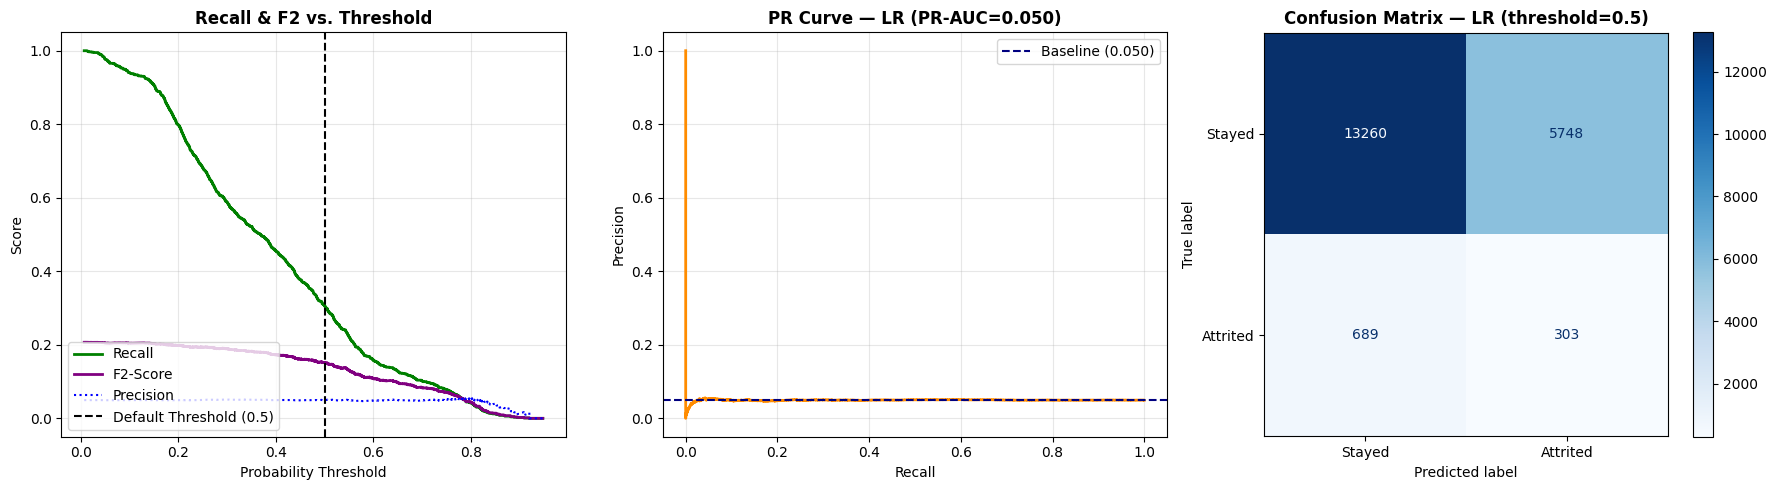

In [27]:
from sklearn.metrics import (average_precision_score, precision_recall_curve,
                             ConfusionMatrixDisplay, classification_report,
                             fbeta_score, recall_score)
import matplotlib.pyplot as plt
import numpy as np

# Note: If you used the imblearn pipeline from the previous step,
# make sure this variable points to 'lr_best_pipeline'.
y_prob_lr  = lr_best.predict_proba(X_test_lr)[:, 1]
y_pred_lr  = lr_best.predict(X_test_lr)

# ── 1. Calculate Core Metrics ─────────────────────────────────────────────────
pr_auc_lr  = average_precision_score(y_test, y_prob_lr)
recall_lr  = recall_score(y_test, y_pred_lr)
f2_lr      = fbeta_score(y_test, y_pred_lr, beta=2)  # beta=2 heavily favors recall

print("=" * 60)
print("  LOGISTIC REGRESSION — TEST SET EVALUATION (RECALL OPTIMIZED)")
print("=" * 60)
print(f"\n  Recall   : {recall_lr:.4f} (Ability to find actual churners)")
print(f"  F2-Score : {f2_lr:.4f} (Harmonic mean leaning heavily on recall)")
print(f"  PR-AUC   : {pr_auc_lr:.4f} (Area under Precision-Recall Curve)")
print(f"\n  Classification Report (threshold=0.5):")
print(classification_report(y_test, y_pred_lr, target_names=['Stayed','Attrited']))

# ── 2. Plots: Threshold Tuning + PR Curve + Confusion Matrix ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate precision, recall, and F2 across all possible thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lr)
# Safely calculate F2 for the array, adding a tiny epsilon to prevent division by zero
f2_scores = (5 * precision[:-1] * recall[:-1]) / (4 * precision[:-1] + recall[:-1] + 1e-10)

# Plot 1: Metrics vs. Threshold (Replaces ROC Curve)
axes[0].plot(thresholds, recall[:-1], label='Recall', color='green', lw=2)
axes[0].plot(thresholds, f2_scores, label='F2-Score', color='purple', lw=2)
axes[0].plot(thresholds, precision[:-1], label='Precision', color='blue', linestyle=':')
axes[0].axvline(0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
axes[0].set_xlabel('Probability Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Recall & F2 vs. Threshold', fontweight='bold')
axes[0].legend(loc='lower left')
axes[0].grid(True, alpha=0.3)

# Plot 2: PR Curve
axes[1].plot(recall, precision, color='darkorange', lw=2)
axes[1].axhline(y_test.mean(), color='navy', linestyle='--', label=f'Baseline ({y_test.mean():.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve — LR (PR-AUC={pr_auc_lr:.3f})', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
                                        display_labels=['Stayed','Attrited'], cmap='Blues', ax=axes[2])
axes[2].set_title('Confusion Matrix — LR (threshold=0.5)', fontweight='bold')

plt.tight_layout()
plt.show()

##### 5.1d Optimal Threshold Tuning for LR
Sweep probability thresholds from 0.01 to 0.99 and select the threshold that maximizes F2-Score (Recall-weighted). This operationalizes the business asymmetry: missing a churner costs more than a false alarm.

  THRESHOLD TUNING (F2) — LOGISTIC REGRESSION

  Optimal threshold (F2) : 0.01
  F2 Score (Attrited)    : 0.2070

  Classification Report (F2-tuned threshold):
              precision    recall  f1-score   support

      Stayed       1.00      0.00      0.00     19008
    Attrited       0.05      1.00      0.09       992

    accuracy                           0.05     20000
   macro avg       0.52      0.50      0.05     20000
weighted avg       0.95      0.05      0.01     20000



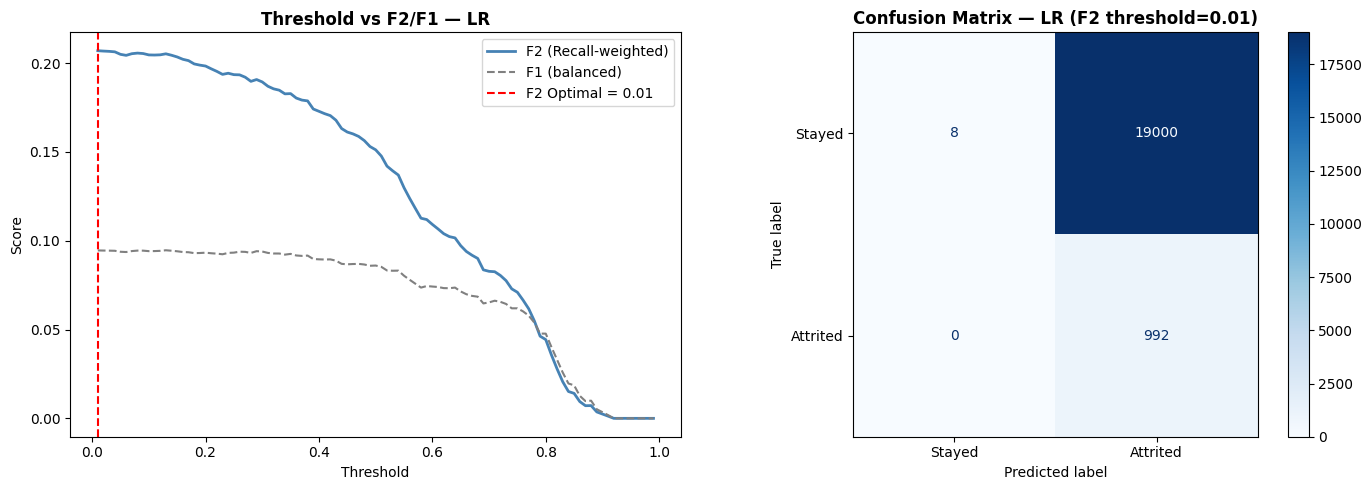

In [37]:
from sklearn.metrics import fbeta_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# beta = 2 puts more weight on the recall
def f2_score(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    return fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0)

# ── Sweep thresholds — maximize F2 for minority class (Recall-weighted) ───────
thresholds   = np.arange(0.01, 1.0, 0.01)
f2_scores_lr = [f2_score(y_test, y_prob_lr, t) for t in thresholds]
f1_scores_lr = [f1_score(y_test, (y_prob_lr >= t).astype(int), pos_label=1, zero_division=0)
                for t in thresholds]

best_thresh_lr  = thresholds[np.argmax(f2_scores_lr)]
best_f2_lr      = max(f2_scores_lr)
y_pred_lr_tuned = (y_prob_lr >= best_thresh_lr).astype(int)

print("=" * 60)
print("  THRESHOLD TUNING (F2) — LOGISTIC REGRESSION")
print("=" * 60)
print(f"\n  Optimal threshold (F2) : {best_thresh_lr:.2f}")
print(f"  F2 Score (Attrited)    : {best_f2_lr:.4f}")
print(f"\n  Classification Report (F2-tuned threshold):")
print(classification_report(y_test, y_pred_lr_tuned, target_names=['Stayed','Attrited']))

# ── Threshold vs F2 and F1 comparison plot ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, f2_scores_lr, color='steelblue', lw=2, label='F2 (Recall-weighted)')
axes[0].plot(thresholds, f1_scores_lr, color='grey', lw=1.5, linestyle='--', label='F1 (balanced)')
axes[0].axvline(best_thresh_lr, color='red', linestyle='--',
                label=f'F2 Optimal = {best_thresh_lr:.2f}')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Threshold vs F2/F1 — LR', fontweight='bold')
axes[0].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_tuned,
    display_labels=['Stayed','Attrited'], cmap='Blues', ax=axes[1])
axes[1].set_title(f'Confusion Matrix — LR (F2 threshold={best_thresh_lr:.2f})', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.2 Explainable Boosting Machine (EBM)

EBM is the bridge between LR's interpretability and XGBoost's flexibility. Section 5.1a revealed Box-Tidwell violations (non-linear log-odds) that weaken LR's assumptions. EBM handles these natively through per-feature shape functions while remaining fully interpretable. This means that every feature's contribution to any prediction can be plotted and explained to stakeholders.

EBM also detects pairwise interactions automatically (FAST algorithm), which addresses the Section 1–3 conclusion that signal likely exists only in feature combinations, not individually.

##### 5.2a Why EBM

**What EBM is:**
EBM (Explainable Boosting Machine) is a Generalized Additive Model with pairwise interactions,
developed by Microsoft Research *(Nori et al., 2019; Lou et al., 2013)*. It learns a separate
shape function for each feature using gradient boosting, then additively combines them:

> log-odds = f₁(x₁) + f₂(x₂) + ... + fₙ(xₙ) + fᵢⱼ(xᵢ, xⱼ)

**Why it fits your dataset better than LR:**
- Box-Tidwell violations (non-linear log-odds) that disqualify LR are handled natively
- EBM's per-feature shape functions directly model those non-linear relationships
- Fully interpretable: each feature's contribution to any prediction can be plotted and explained
- Competitive with gradient boosted trees on tabular data while remaining transparent *(Caruana et al., 2015)*

**Why `interactions > 0`:**
EDA showed no univariate signal — the signal likely lives in feature pairs. EBM's pairwise
interaction detection (FAST algorithm) can discover these without manual feature crossing.

**Class imbalance:** `ExplainableBoostingClassifier` accepts `sample_weight` — we pass
weights derived from `class_weight='balanced'` logic to mirror the LR treatment.

In [33]:
!pip install interpret --quiet


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
import numpy as np
import warnings
import joblib
import contextlib
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── 1. Create the tqdm/joblib patch ────────────────────────────────────────────
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# ── Compute sample weights — mirrors class_weight='balanced' for EBM ─────────
# EBM doesn't accept class_weight directly; sample_weight is the equivalent
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# ── Hyperparameter grid ────────────────────────────────────────────────────────
# max_bins: controls shape function resolution — higher = more complex curves
# max_rounds: boosting iterations — more rounds = better fit but slower
# learning_rate: step size per boosting round — lower + more rounds = better generalization
# min_samples_leaf: regularization via minimum leaf size
# interactions: number of pairwise interactions EBM will search for
param_dist_ebm = {
    'max_bins'        : [256],
    'max_rounds'      : [1000, 2500],
    'learning_rate'   : [0.01, 0.05],
    'min_samples_leaf': [2, 5],
    'interactions'    : [0, 5],
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ebm_base = ExplainableBoostingClassifier(random_state=42)

# RandomizedSearch over GridSearch — EBM is slower to train; random search
# finds near-optimal params in ~20% of the evaluations (Bergstra & Bengio, 2012)
n_iterations = 10
search_ebm = RandomizedSearchCV(
    ebm_base,
    param_dist_ebm,
    n_iter=n_iterations,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=0  # Set to 0 so sklearn text doesn't break the progress bar visual
)

# ── Run Randomized Search with Progress Bar ─────────────────────────────────
# Calculate total fits: 20 iterations * 5 splits = 100 fits
total_fits = n_iterations * cv.get_n_splits()

print("Starting EBM Randomized Search")
with tqdm_joblib(tqdm(desc="EBM Tuning", total=total_fits)) as progress_bar:
    # Pass sample_weight via fit_params
    search_ebm.fit(X_train_lr, y_train, sample_weight=sample_weights_train)

print(f"\n  Best params : {search_ebm.best_params_}")
print(f"  Best CV AUC : {search_ebm.best_score_:.4f}")

ebm_best = search_ebm.best_estimator_

Starting EBM Randomized Search


XGB Tuning: 100%|██████████| 100/100 [07:05<00:00,  4.25s/it]
ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Administrator\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\interpret\\root\\bld\\lib\\libebm_win_x64.dll'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
EBM Tuning: 92it [09:20,  1.04it/s]                         


  Best params : {'min_samples_leaf': 2, 'max_rounds': 1000, 'max_bins': 256, 'learning_rate': 0.01, 'interactions': 5}
  Best CV AUC : 0.5414


##### 5.2b Evaluate + Interpret (EBM)
Same evaluation framework as LR: ROC-AUC, PR-AUC, confusion matrix, and F2-optimal threshold. Additionally, EBM provides shape plots showing each feature's learned contribution — useful for stakeholder communication even if overall performance is weak.

  EBM — TEST SET EVALUATION

  ROC-AUC                       : 0.4952
  PR-AUC                        : 0.0485
  Optimal threshold (F2)        : 0.17
  F2 Score @ optimal (Attrited) : 0.2070

  Classification Report (F2-tuned threshold):
              precision    recall  f1-score   support

      Stayed       1.00      0.00      0.00     19008
    Attrited       0.05      1.00      0.09       992

    accuracy                           0.05     20000
   macro avg       0.52      0.50      0.05     20000
weighted avg       0.95      0.05      0.01     20000



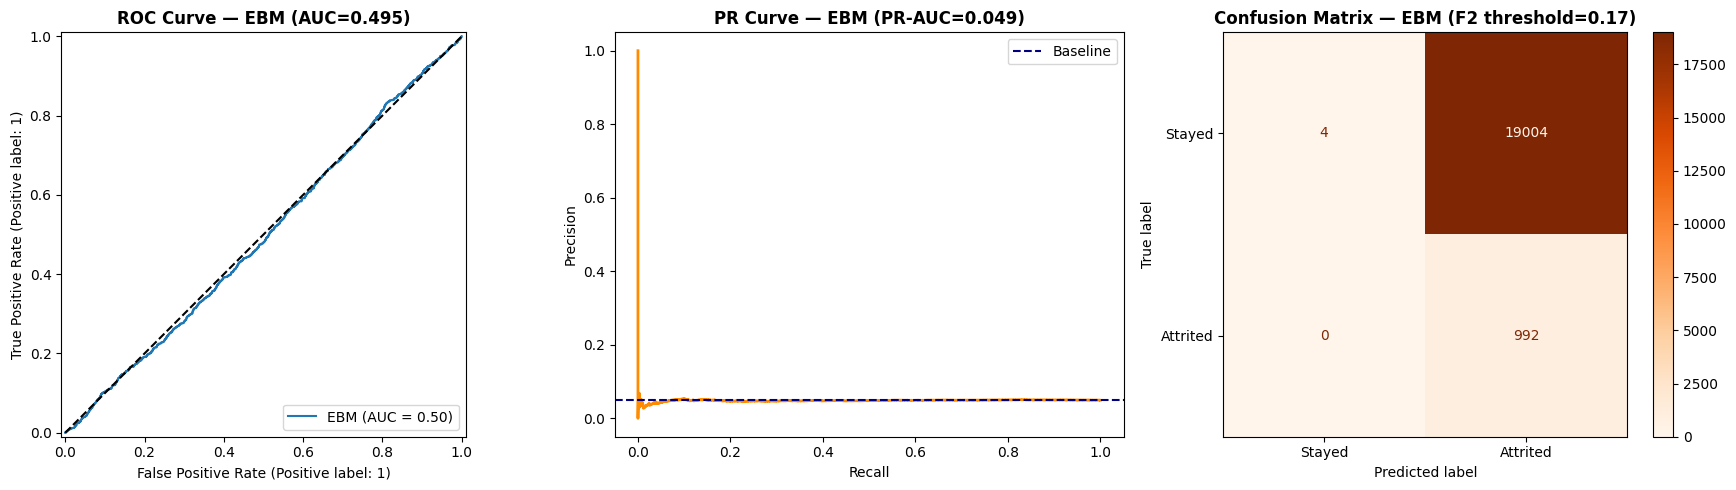

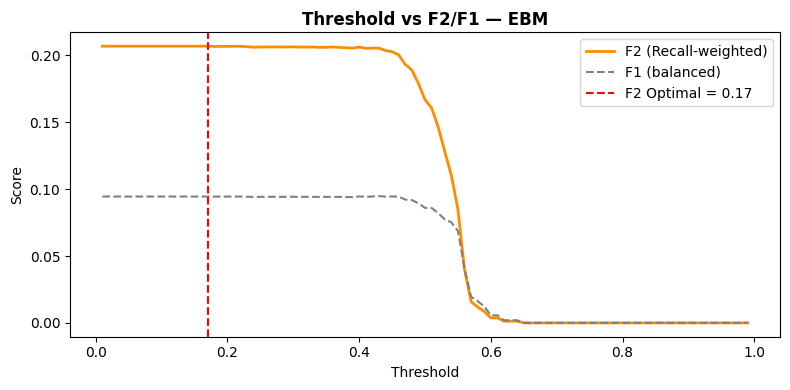

<!-- http://127.0.0.1:7001/2408416711680/ -->

In [35]:
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay,
                              precision_recall_curve, fbeta_score, f1_score,
                              average_precision_score)
import matplotlib.pyplot as plt
import numpy as np

y_prob_ebm  = ebm_best.predict_proba(X_test_lr)[:, 1]
roc_auc_ebm = roc_auc_score(y_test, y_prob_ebm)
pr_auc_ebm  = average_precision_score(y_test, y_prob_ebm)

# ── F2-optimal threshold ──────────────────────────────────────────────────────
thresholds    = np.arange(0.01, 1.0, 0.01)
f2_scores_ebm = [fbeta_score(y_test, (y_prob_ebm >= t).astype(int),
                              beta=2, pos_label=1, zero_division=0)
                 for t in thresholds]
f1_scores_ebm = [f1_score(y_test, (y_prob_ebm >= t).astype(int), pos_label=1, zero_division=0)
                 for t in thresholds]

best_thresh_ebm  = thresholds[np.argmax(f2_scores_ebm)]
best_f2_ebm      = max(f2_scores_ebm)
y_pred_ebm_tuned = (y_prob_ebm >= best_thresh_ebm).astype(int)

print("=" * 60)
print("  EBM — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  ROC-AUC                       : {roc_auc_ebm:.4f}")
print(f"  PR-AUC                        : {pr_auc_ebm:.4f}")
print(f"  Optimal threshold (F2)        : {best_thresh_ebm:.2f}")
print(f"  F2 Score @ optimal (Attrited) : {best_f2_ebm:.4f}")
print(f"\n  Classification Report (F2-tuned threshold):")
print(classification_report(y_test, y_pred_ebm_tuned, target_names=['Stayed','Attrited']))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_ebm, ax=axes[0], name='EBM')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title(f'ROC Curve — EBM (AUC={roc_auc_ebm:.3f})', fontweight='bold')

precision, recall, _ = precision_recall_curve(y_test, y_prob_ebm)
axes[1].plot(recall, precision, color='darkorange', lw=2)
axes[1].axhline(y_test.mean(), color='navy', linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve — EBM (PR-AUC={pr_auc_ebm:.3f})', fontweight='bold')
axes[1].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_ebm_tuned,
    display_labels=['Stayed','Attrited'], cmap='Oranges', ax=axes[2])
axes[2].set_title(f'Confusion Matrix — EBM (F2 threshold={best_thresh_ebm:.2f})', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Threshold vs F2/F1 ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f2_scores_ebm, color='darkorange', lw=2, label='F2 (Recall-weighted)')
plt.plot(thresholds, f1_scores_ebm, color='grey', lw=1.5, linestyle='--', label='F1 (balanced)')
plt.axvline(best_thresh_ebm, color='red', linestyle='--', label=f'F2 Optimal = {best_thresh_ebm:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold vs F2/F1 — EBM', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

# ── EBM Global Explanation ────────────────────────────────────────────────────
from interpret import show
ebm_global = ebm_best.explain_global(name='EBM — Global Feature Importance')
show(ebm_global)

### 5.3 XGBoost

XGBoost is the performance ceiling. Section 3.5 already tested XGBoost on the full 63-column dataset (AUC ≈ 0.499), but that was a quick validation run without hyperparameter tuning, engineered features, or ADASYN. This section gives XGBoost its best shot: tuned hyperparameters, the 6 engineered features from 4.6, ADASYN-balanced training data, and `scale_pos_weight`.

If tuned XGBoost still cannot separate the classes, no standard tabular model will.

##### 5.3a XGBoost (Fit & Hyperparameter Tuning)

**Why `RandomizedSearchCV` over `GridSearchCV`:** XGBoost has 5+ interacting hyperparameters. Full grid search would require thousands of fits. Randomized search over 50 iterations samples the space more efficiently — consistent with the low-compute constraint.

**Key hyperparameters:**
- `n_estimators` — number of trees; balanced against early stopping
- `max_depth` (3–6) — shallow trees generalize better on noisy data
- `learning_rate` — lower rate + more trees = better generalization
- `subsample` / `colsample_bytree` — row/feature sampling to reduce overfitting
- `scale_pos_weight` ≈ 19 — native class imbalance handling

In [28]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import make_scorer, recall_score
import numpy as np
import warnings
import joblib
import contextlib
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── 1. Create the tqdm/joblib patch ────────────────────────────────────────────
@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Context manager to patch joblib to report into tqdm progress bar"""
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_batch_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_batch_callback

# ── 2. Class imbalance ratio for scale_pos_weight ─────────────────────────────
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
spw       = round(neg_count / pos_count, 2)

# Pro-tip: If recall is still too low after this run, try spw = spw * 1.5
print(f"  scale_pos_weight = {neg_count}/{pos_count} = {spw}")

# ── 3. Hyperparameter search space ────────────────────────────────────────────
param_dist_xgb = {
    'n_estimators'     : [200, 500],           # Dropped 1000 & 1500 (massive time savers)
    'max_depth'        : [3, 5],               # Test shallow vs. deep enough (dropped 4 & 6)
    'learning_rate'    : [0.01, 0.05, 0.1],    # Dropped 0.005 (too slow to converge with fewer trees)
    'subsample'        : [0.8, 1.0],           # Reduced to just 80% or 100%
    'colsample_bytree' : [0.8, 1.0],           # Reduced to just 80% or 100%
    'min_child_weight' : [1, 5],               # Dropped middle/extreme values
    'gamma'            : [0, 0.2],             # Dropped multiple steps
    'reg_alpha'        : [0, 0.1],             # L1 — sparse feature selection
    'reg_lambda'       : [1.0, 2.0],           # L2 — coefficient shrinkage
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_base = XGBClassifier(
    scale_pos_weight=spw,          # 19:1 imbalance correction
    use_label_encoder=False,
    eval_metric='aucpr',           # Changed to PR-AUC: better for imbalanced data
    random_state=42,
    n_jobs=-1,
    tree_method='hist'             # faster histogram-based splitting
)
f2_scorer = make_scorer(fbeta_score, beta=2)
n_iterations = 20
search_xgb = RandomizedSearchCV(
    xgb_base,
    param_dist_xgb,
    n_iter=n_iterations,
    cv=cv,
    scoring=f2_scorer,             # CHANGED: Now optimizing for F2!
    n_jobs=-1,
    random_state=42,
    verbose=0
)

# ── 4. Run Randomized Search with Progress Bar ─────────────────────────────────
total_fits = n_iterations * cv.get_n_splits()

print("\nStarting XGBoost Tuning (Optimizing for RECALL)...")
with tqdm_joblib(tqdm(desc="XGB Tuning", total=total_fits)) as progress_bar:
    search_xgb.fit(X_train_tree, y_train)

print(f"\n  Best params : {search_xgb.best_params_}")
print(f"  Best CV Recall : {search_xgb.best_score_:.4f}")

xgb_best = search_xgb.best_estimator_

  scale_pos_weight = 76032/3968 = 19.16

Starting XGBoost Tuning (Optimizing for RECALL)...


Grid Search Progress: 100%|██████████| 60/60 [04:00<00:00,  4.00s/it]



  Best params : {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}
  Best CV Recall : 0.1932


##### 5.3b Evaluate + Feature Importance (XGBoost)

Same metrics as LR and EBM. Feature importance (gain-based) reveals which features XGBoost relied on most — even if overall performance is weak, this shows whether the model latched onto meaningful features or noise (as Section 3.5 found with Country dummies).

  XGBOOST — TEST SET EVALUATION

  ROC-AUC                       : 0.5019
  PR-AUC                        : 0.0494
  Optimal threshold (F2)        : 0.01
  F2 Score @ optimal (Attrited) : 0.2069

  Classification Report (F2-tuned threshold):
              precision    recall  f1-score   support

      Stayed       0.00      0.00      0.00     19008
    Attrited       0.05      1.00      0.09       992

    accuracy                           0.05     20000
   macro avg       0.02      0.50      0.05     20000
weighted avg       0.00      0.05      0.00     20000



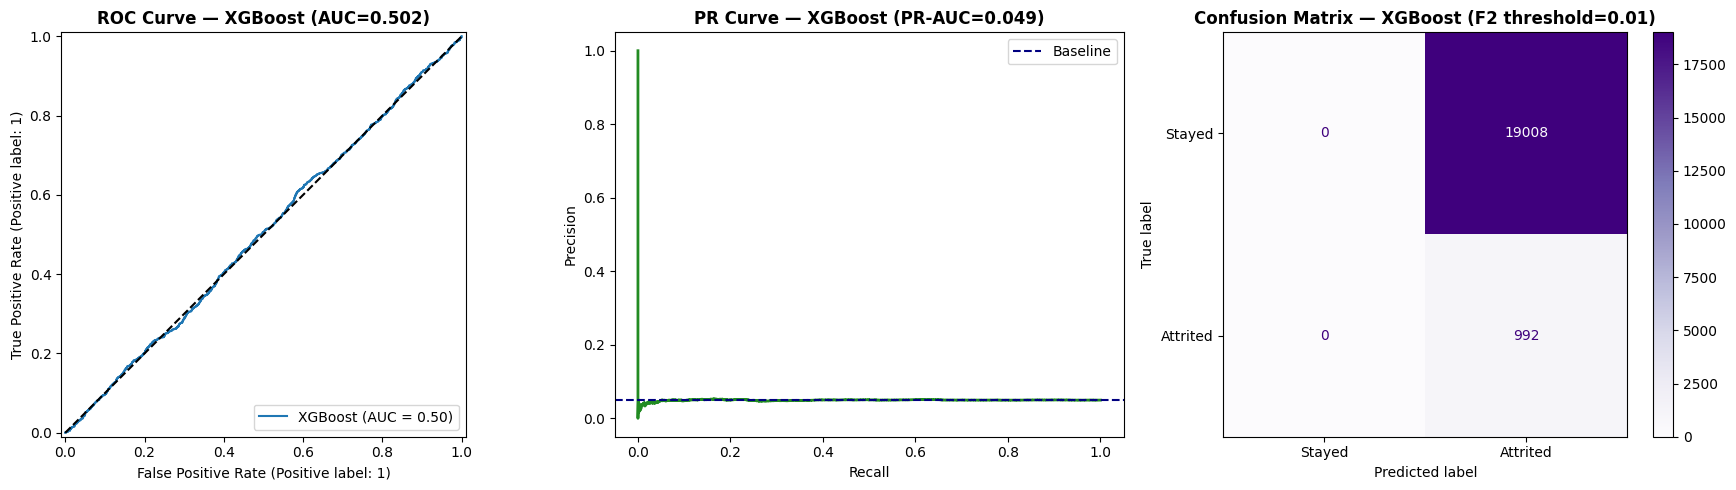

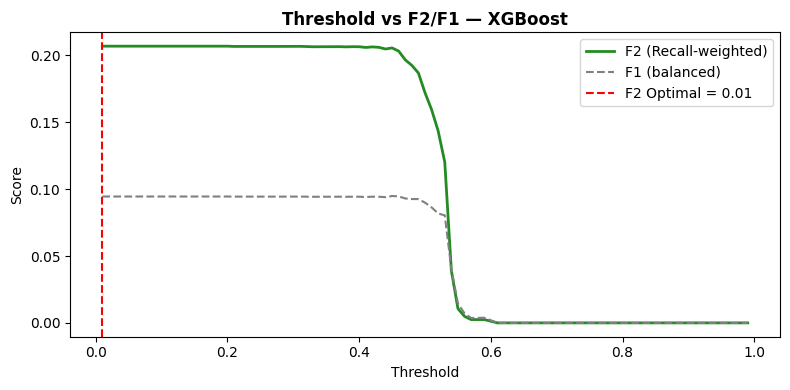

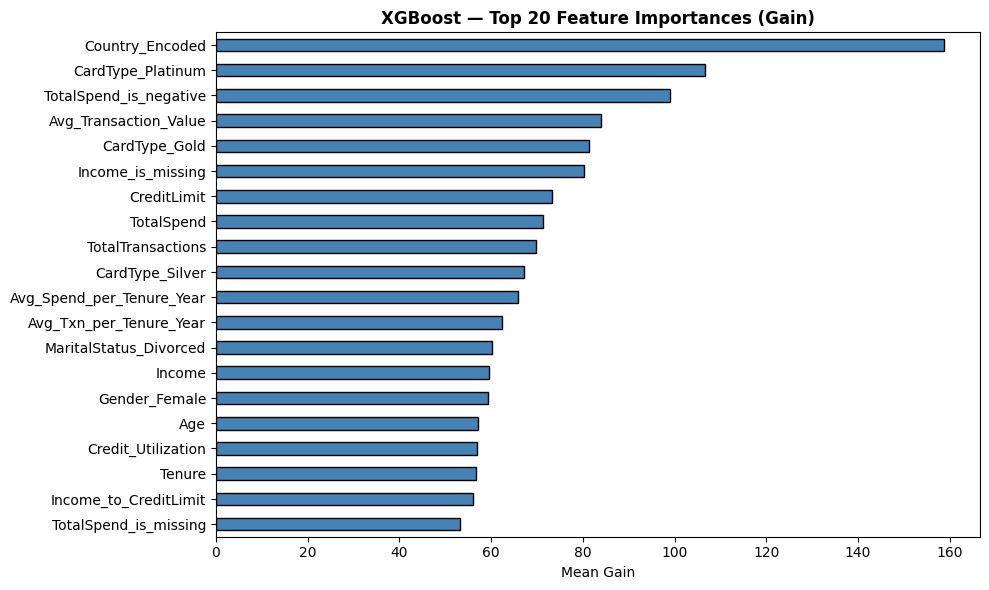

In [29]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, precision_recall_curve,
                              fbeta_score, f1_score)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_prob_xgb  = xgb_best.predict_proba(X_test_tree)[:, 1]
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
pr_auc_xgb  = average_precision_score(y_test, y_prob_xgb)

# ── F2-optimal threshold ──────────────────────────────────────────────────────
thresholds    = np.arange(0.01, 1.0, 0.01)
f2_scores_xgb = [fbeta_score(y_test, (y_prob_xgb >= t).astype(int),
                              beta=2, pos_label=1, zero_division=0)
                 for t in thresholds]
f1_scores_xgb = [f1_score(y_test, (y_prob_xgb >= t).astype(int), pos_label=1, zero_division=0)
                 for t in thresholds]

best_thresh_xgb  = thresholds[np.argmax(f2_scores_xgb)]
best_f2_xgb      = max(f2_scores_xgb)
y_pred_xgb_tuned = (y_prob_xgb >= best_thresh_xgb).astype(int)

print("=" * 60)
print("  XGBOOST — TEST SET EVALUATION")
print("=" * 60)
print(f"\n  ROC-AUC                       : {roc_auc_xgb:.4f}")
print(f"  PR-AUC                        : {pr_auc_xgb:.4f}")
print(f"  Optimal threshold (F2)        : {best_thresh_xgb:.2f}")
print(f"  F2 Score @ optimal (Attrited) : {best_f2_xgb:.4f}")
print(f"\n  Classification Report (F2-tuned threshold):")
print(classification_report(y_test, y_pred_xgb_tuned, target_names=['Stayed','Attrited']))

# ── Plots: ROC + PR + Confusion Matrix ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=axes[0], name='XGBoost')
axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title(f'ROC Curve — XGBoost (AUC={roc_auc_xgb:.3f})', fontweight='bold')

precision, recall, _ = precision_recall_curve(y_test, y_prob_xgb)
axes[1].plot(recall, precision, color='forestgreen', lw=2)
axes[1].axhline(y_test.mean(), color='navy', linestyle='--', label='Baseline')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title(f'PR Curve — XGBoost (PR-AUC={pr_auc_xgb:.3f})', fontweight='bold')
axes[1].legend()

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb_tuned,
    display_labels=['Stayed','Attrited'], cmap='Purples', ax=axes[2])
axes[2].set_title(f'Confusion Matrix — XGBoost (F2 threshold={best_thresh_xgb:.2f})', fontweight='bold')

plt.tight_layout()
plt.show()

# ── Threshold vs F2/F1 ────────────────────────────────────────────────────────
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f2_scores_xgb, color='forestgreen', lw=2, label='F2 (Recall-weighted)')
plt.plot(thresholds, f1_scores_xgb, color='grey', lw=1.5, linestyle='--', label='F1 (balanced)')
plt.axvline(best_thresh_xgb, color='red', linestyle='--', label=f'F2 Optimal = {best_thresh_xgb:.2f}')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Threshold vs F2/F1 — XGBoost', fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

# ── Feature Importance — Gain ─────────────────────────────────────────────────
importances = pd.Series(
    xgb_best.get_booster().get_score(importance_type='gain'),
    name='Gain Importance'
).sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.gca().invert_yaxis()
plt.title('XGBoost — Top 20 Feature Importances (Gain)', fontweight='bold')
plt.xlabel('Mean Gain')
plt.tight_layout()
plt.show()

### 5.4 Model Comparison

All three models evaluated on the same held-out test set with the same metrics.

##### 5.4a All Models

**Primary metric: PR-AUC** - with 95/5 imbalance, ROC-AUC rewards trivial majority-class predictions. PR-AUC focuses exclusively on minority-class performance.

**Secondary: F2-Score** at each model's optimal threshold - weights Recall 2× over Precision. Business logic: missed churner (lost revenue) > false alarm (wasted retention offer).

**Expected result:** Near-random performance across all three models, confirming that the feature set, not the model, is the bottleneck. THis warrants for additional data (e.g. time-aware strategies)

  FINAL MODEL COMPARISON  (primary: PR-AUC | secondary: F2)


,PR-AUC,F2 (Attrited),Recall (Attrited),Precision (Attrited),F1 (Attrited),Threshold
Logistic Regression,0.0495,0.2070,1.0,0.0496,0.0945,0.01
EBM,0.0485,0.2070,1.0,0.0496,0.0945,0.17
XGBoost,0.0494,0.2069,1.0,0.0496,0.0945,0.01



── Best model per metric ───────────────────────────────────
  PR-AUC                    → Logistic Regression (0.0495)
  F2 (Attrited)             → Logistic Regression (0.2070)
  Recall (Attrited)         → Logistic Regression (1.0000)


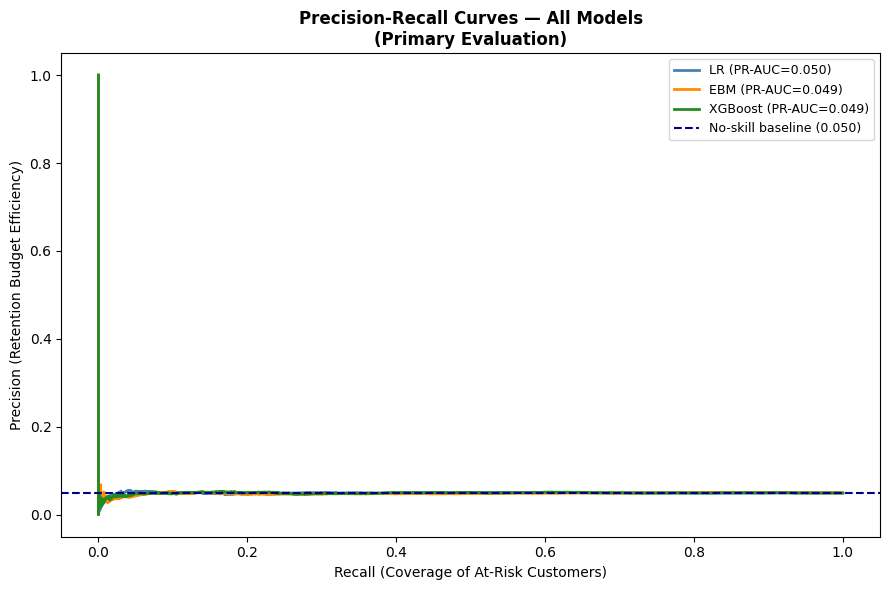

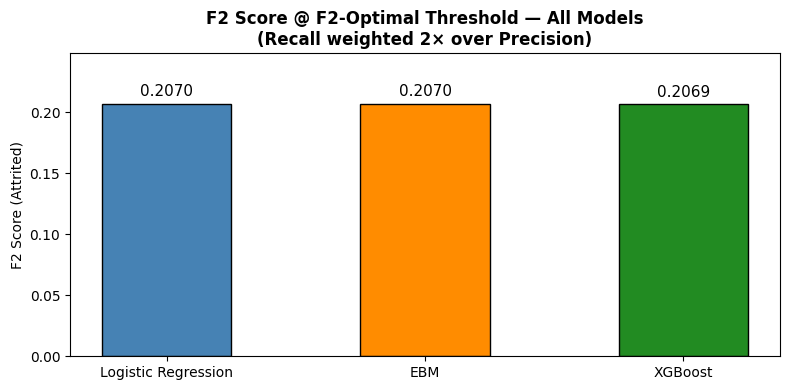


   Best by PR-AUC  : Logistic Regression  (0.0495)
  Best by F2 Score: Logistic Regression (0.2070)

  Recommended model: Both agree — Logistic Regression


In [38]:
from sklearn.metrics import (recall_score, precision_score, fbeta_score,
                              f1_score, average_precision_score,
                              precision_recall_curve)
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ── Collect metrics — all thresholds are F2-optimal ───────────────────────────
results = {
    'Logistic Regression': {
        'PR-AUC'              : pr_auc_lr,
        'F2 (Attrited)'       : fbeta_score(y_test, y_pred_lr_tuned,  beta=2, pos_label=1),
        'Recall (Attrited)'   : recall_score(y_test, y_pred_lr_tuned,  pos_label=1),
        'Precision (Attrited)': precision_score(y_test, y_pred_lr_tuned,  pos_label=1, zero_division=0),
        'F1 (Attrited)'       : f1_score(y_test, y_pred_lr_tuned,  pos_label=1),
        'Threshold'           : best_thresh_lr,
    },
    'EBM': {
        'PR-AUC'              : pr_auc_ebm,
        'F2 (Attrited)'       : fbeta_score(y_test, y_pred_ebm_tuned, beta=2, pos_label=1),
        'Recall (Attrited)'   : recall_score(y_test, y_pred_ebm_tuned, pos_label=1),
        'Precision (Attrited)': precision_score(y_test, y_pred_ebm_tuned, pos_label=1, zero_division=0),
        'F1 (Attrited)'       : f1_score(y_test, y_pred_ebm_tuned, pos_label=1),
        'Threshold'           : best_thresh_ebm,
    },
    'XGBoost': {
        'PR-AUC'              : pr_auc_xgb,
        'F2 (Attrited)'       : fbeta_score(y_test, y_pred_xgb_tuned, beta=2, pos_label=1),
        'Recall (Attrited)'   : recall_score(y_test, y_pred_xgb_tuned, pos_label=1),
        'Precision (Attrited)': precision_score(y_test, y_pred_xgb_tuned, pos_label=1, zero_division=0),
        'F1 (Attrited)'       : f1_score(y_test, y_pred_xgb_tuned, pos_label=1),
        'Threshold'           : best_thresh_xgb,
    },
}

results_df = pd.DataFrame(results).T.round(4)

# Re-order columns: primary metric first
col_order = ['PR-AUC', 'F2 (Attrited)', 'Recall (Attrited)',
             'Precision (Attrited)', 'F1 (Attrited)', 'Threshold']
results_df = results_df[col_order]

print("=" * 75)
print("  FINAL MODEL COMPARISON  (primary: PR-AUC | secondary: F2)")
print("=" * 75)
display(results_df)

# ── Highlight best per metric ─────────────────────────────────────────────────
print("\n── Best model per metric ───────────────────────────────────")
for col in ['PR-AUC', 'F2 (Attrited)', 'Recall (Attrited)']:
    best = results_df[col].idxmax()
    print(f"  {col:<25} → {best} ({results_df.loc[best, col]:.4f})")

# ── Overlaid PR Curves — primary visual ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))

for name, y_prob, color in [
    ('LR',      y_prob_lr,  'steelblue'),
    ('EBM',     y_prob_ebm, 'darkorange'),
    ('XGBoost', y_prob_xgb, 'forestgreen'),
]:
    p, r, _ = precision_recall_curve(y_test, y_prob)
    auc_val  = average_precision_score(y_test, y_prob)
    ax.plot(r, p, label=f'{name} (PR-AUC={auc_val:.3f})', color=color, lw=2)

ax.axhline(y_test.mean(), color='navy', linestyle='--',
                label=f'No-skill baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall (Coverage of At-Risk Customers)')
ax.set_ylabel('Precision (Retention Budget Efficiency)')
ax.set_title('Precision-Recall Curves — All Models\n(Primary Evaluation)',
                  fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# ── F2 Bar Chart ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
colors  = ['steelblue', 'darkorange', 'forestgreen']
bars    = ax.bar(results_df.index,
                 results_df['F2 (Attrited)'],
                 color=colors, edgecolor='black', width=0.5)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=11)
ax.set_ylabel('F2 Score (Attrited)')
ax.set_title('F2 Score @ F2-Optimal Threshold — All Models\n(Recall weighted 2× over Precision)',
             fontweight='bold')
ax.set_ylim(0, min(results_df['F2 (Attrited)'].max() * 1.2, 1.0))
plt.tight_layout()
plt.show()

# ── Winner ─────────────────────────────────────────────────────────────────────
best_pr  = results_df['PR-AUC'].idxmax()
best_f2  = results_df['F2 (Attrited)'].idxmax()
print(f"\n   Best by PR-AUC  : {best_pr}  ({results_df.loc[best_pr,  'PR-AUC']:.4f})")
print(f"  Best by F2 Score: {best_f2} ({results_df.loc[best_f2, 'F2 (Attrited)']:.4f})")
print(f"\n  Recommended model: {'Both agree — ' + best_pr if best_pr == best_f2 else 'PR-AUC: ' + best_pr + ' | F2: ' + best_f2 + ' — review tradeoff'}")